# Fachhochschule Südwestfalen

## Semesterabschließende Ausarbeitung im Modul Natural Language Processing

# Einfluss von Retrieval-Augmented Generation auf die Korrektheit deutschsprachiger Spielregelantworten am Beispiel von CATAN

**Autor:** Ozan Kiraz &nbsp;·&nbsp; **Matrikelnummer:** _eintragen_
**Betreuung:** Prof. Dr. Christian Gawron
**Abgabe:** 29. September 2026
**Repository:** [github.com/Oz1904/nlp-catan-rag-kiraz](https://github.com/Oz1904/nlp-catan-rag-kiraz)

---

### Kurzfassung

Große Sprachmodelle beantworten Fragen zu populären Gesellschaftsspielen oft flüssig, aber nicht immer regelkonform. Besonders fehleranfällig sind Konstellationen, in denen eine Erweiterung Regeln des Grundspiels nicht ergänzt, sondern ersetzt. Diese Arbeit untersucht, ob die automatische Bereitstellung passender Regelabschnitte aus den offiziellen Regelheften die Korrektheit der Antworten desselben Sprachmodells erhöht.

Datengrundlage sind die beiden offiziellen deutschsprachigen KOSMOS-Regelhefte zu *CATAN – Das Spiel* und *CATAN – Städte & Ritter*. Aus ihnen wird eine Wissensbasis aufgebaut und ein Fragenkatalog mit belegten Referenzantworten erstellt. Verglichen werden drei Bedingungen desselben Modells: ohne Regelkontext (A), mit automatisch abgerufenem Kontext (B) und mit manuell annotiertem Belegkontext (C). Die Auswertung erfolgt zweistufig: Das Retrieval wird mit Precision@k, Recall@k und F1 gegen die annotierten Belegstellen gemessen; die Antwortkorrektheit wird verblindet nach einem vorab festgelegten Schema bewertet und über einen gepaarten Cluster-Bootstrap auf Regelgruppenebene mit Unsicherheitsintervallen versehen.

Die Arbeit trennt konsequent zwischen Retrieval- und Generierungsfehlern und behandelt Bedingung C als Diagnoseinstrument, nicht als garantierte Obergrenze. Ein Vorteil von RAG gilt ausdrücklich als zu prüfende Hypothese, nicht als erwartetes Ergebnis.


## Inhaltsverzeichnis

1. [Problemstellung, Forschungsfrage und Datengrundlage](#1-problemstellung)
2. [Theoretische Grundlagen](#2-grundlagen)
3. [Stand der Technik](#3-stand)
4. [Quellen, Aufbereitung und Wissensbasis](#4-quellen)
5. [Versuchsaufbau und Methodik](#5-methodik)
6. [Fragenkatalog und Bewertungsschema](#6-katalog)
7. [Retrieval-Pipeline](#7-retrieval)
8. [Evaluation des Retrievals: Precision, Recall, F1](#8-retrieval-eval)
9. [Durchführung des A/B/C-Vergleichs](#9-durchlauf)
10. [Verblindete Bewertung der Antworten](#10-bewertung)
11. [Ergebnisse, Unsicherheit und Fehleranalyse](#11-ergebnisse)
12. [Kritische Reflexion und Fazit](#12-fazit)
13. [Literatur und Quellen](#13-literatur)


## 1. Problemstellung, Forschungsfrage und Datengrundlage <a id="1-problemstellung"></a>

### 1.1 Das Problem

Wer eine Regelfrage zu einem Gesellschaftsspiel hat, greift heute häufiger zu einem Sprachmodell als zum Regelheft. Für weit verbreitete Spiele wie CATAN liefern solche Modelle meist flüssige und plausibel klingende Antworten. Ob diese Antworten regelkonform sind, ist damit jedoch nicht gesagt: Das Modellwissen stammt aus Trainingsdaten unbekannter Zusammensetzung und unbekannten Alters, vermischt Regelstände verschiedener Editionen und kann Diskussionsbeiträge aus Foren nicht zuverlässig von offiziellen Regeln unterscheiden.

Besonders fehleranfällig ist eine Konstellation, die für Erweiterungen typisch ist: Eine Erweiterung **ersetzt** einzelne Regeln des Grundspiels, statt sie nur zu ergänzen. Bei *CATAN – Städte & Ritter* betrifft das unter anderem die Siegpunktschwelle, die Sondersiegpunkttafeln, die Gründungsphase, die Startposition des Räubers und die Entwicklungskarten. Ein Modell, das auf breites Grundspielwissen zurückgreift, kann hier unpassende Grundspielregeln übertragen; ob und wie häufig das geschieht, ist die empirische Frage dieser Arbeit.

Retrieval-Augmented Generation (RAG) verspricht für genau solche Fälle Abhilfe: Statt sich auf parametrisches Modellwissen zu verlassen, wird zur Frage passender Quelltext gesucht und dem Modell als Kontext übergeben. Ob dieser Ansatz bei deutschsprachigen Spielregeln tatsächlich zu mehr korrekten Antworten führt, ist die empirische Frage dieser Arbeit.

### 1.2 Forschungsfrage

> **Wie verändert die automatische Bereitstellung relevanter Regelabschnitte aus den offiziellen CATAN-Regelheften die Korrektheit der Antworten desselben Sprachmodells bei Fakten-, Ausnahme- und Anwendungsfragen?**

Ergänzend wird eine diagnostische Frage untersucht:

> **Welche Fehler bleiben bestehen, wenn dem Modell alle zur Beantwortung erforderlichen Belegstellen manuell bereitgestellt werden?**

Die zweite Frage trennt zwei Fehlerquellen, die in einer reinen A/B-Messung vermischt blieben: Findet das System die richtigen Stellen nicht, oder findet es sie und zieht daraus dennoch den falschen Schluss?

### 1.3 Hypothesen

Die Hypothesen werden **vor** dem Endlauf festgelegt und im Notebook fest codiert:

- **H1:** Bedingung B (mit RAG) erreicht über alle Fragetypen hinweg einen höheren Anteil vollständig korrekter Antworten als Bedingung A (ohne RAG).
- **H2:** Der Vorsprung von B gegenüber A fällt bei Ausnahme- und Anwendungsfragen größer aus als bei Faktenfragen, weil bei Faktenfragen das parametrische Modellwissen bereits weitgehend ausreicht.
- **H3:** Ein Teil der verbleibenden Fehler in B ist auf unvollständiges Retrieval zurückzuführen und verschwindet in Bedingung C.

H1 ist gerichtet, aber nicht als Erwartung formuliert: Ein Ausbleiben des Effekts wäre ein ebenso berichtenswertes Ergebnis, insbesondere angesichts der in Abschnitt 5.4 beschriebenen Vorwissensproblematik.

### 1.4 Datengrundlage statt Trainingsdaten

Die Aufgabenstellung fragt nach den verwendeten Trainingsdaten beziehungsweise der Simulationsumgebung. Diese Arbeit trainiert **kein** Modell — weder ein Sprachmodell noch ein Embedding-Modell. Verwendet werden ausschließlich vortrainierte, öffentlich verfügbare Modelle über eine API. An die Stelle von Trainingsdaten treten deshalb zwei andere Datenbestände, die die gleiche Rolle für die Nachvollziehbarkeit erfüllen:

**Wissensbasis (Retrieval-Korpus).** Die beiden offiziellen deutschsprachigen Regelhefte von KOSMOS:

| Dokument | Artikelnummer | Umfang | Impressum |
|---|---|---:|---|
| CATAN – Das Spiel (Grundspiel) | 684655 | 12 Seiten | © 1995, 2025 KOSMOS |
| CATAN – Städte & Ritter | 684754 | 16 Seiten | © 1998, 2025 KOSMOS |

**Evaluationsdaten (Fragenkatalog).** Ein für diese Arbeit erstellter Katalog deutschsprachiger Regelfragen mit Referenzantworten, zwingend erforderlichen Aussagen, Fehlerkriterien und vollständigen Belegstellen. Ein Teil der Fragen ist als KI-Entwurf entstanden; Auswahl der Regelstellen, fachliche Prüfung gegen die Hefte und Freigabe liegen beim Autor, und die Herkunft jeder einzelnen Frage ist im Katalog festgehalten (Abschnitt 6.5). Der Katalog ist die zentrale Eigenleistung der Arbeit; er existiert in dieser Form nicht als öffentlicher Datensatz.

Die Trennung ist wichtig: Der Fragenkatalog wird **nicht** in den Suchindex aufgenommen. Andernfalls würde das Retrieval die Referenzantwort statt der Regelstelle finden.

### 1.5 Abgrenzung

Untersucht werden das Grundspiel und das Grundspiel mit der Erweiterung *Städte & Ritter*, jeweils für Partien mit drei bis vier Personen. Ausgeschlossen sind die Erweiterungen *Seefahrer*, *Händler & Barbaren* und *Entdecker & Piraten*, Ergänzungen für fünf bis sechs Personen, Kombinationen mehrerer Erweiterungen, Hausregeln, Turniersonderregeln und Strategieempfehlungen. Ebenfalls ausgeschlossen sind Fragen, die sich ausschließlich durch die Interpretation einer Abbildung beantworten lassen — diese wären mit einem reinen Textkorpus nicht fair lösbar.

Jede Frage benennt die geltende Spielvariante ausdrücklich, da dieselbe Frage je nach Variante unterschiedliche korrekte Antworten hat.


## 2. Theoretische Grundlagen <a id="2-grundlagen"></a>

### 2.1 Retrieval-Augmented Generation

Retrieval-Augmented Generation verbindet ein parametrisches Sprachmodell mit einem nicht-parametrischen Speicher aus Dokumenten [1]. Statt eine Antwort allein aus den Modellgewichten zu erzeugen, wird zunächst zu einer Anfrage passender Text gesucht und dem Modell zusammen mit der Frage übergeben. Der Ansatz verfolgt drei Ziele: Aktualisierbarkeit ohne erneutes Training, Nachvollziehbarkeit durch Quellenangaben und eine Reduktion frei erfundener Inhalte.

Eine RAG-Pipeline besteht aus vier Schritten:

1. **Aufbereitung.** Quelldokumente werden in Textabschnitte (Chunks) zerlegt und mit Metadaten versehen.
2. **Indexierung.** Jeder Abschnitt wird durch ein Embedding-Modell in einen Vektor überführt und gespeichert.
3. **Retrieval.** Die Frage wird mit demselben Modell eingebettet; über ein Ähnlichkeitsmaß werden die *k* nächstgelegenen Abschnitte bestimmt.
4. **Generierung.** Die abgerufenen Abschnitte werden in den Prompt eingesetzt, das Sprachmodell formuliert die Antwort.

Jeder Schritt kann eigenständig fehlschlagen. Ein Fehler in Schritt 3 (die relevante Stelle wird nicht gefunden) hat andere Ursachen und andere Gegenmaßnahmen als ein Fehler in Schritt 4 (die Stelle liegt vor, wird aber falsch ausgewertet). Die Trennung dieser beiden Fehlerarten ist ein Kernanliegen des hier gewählten Versuchsaufbaus.

### 2.2 Embeddings und semantische Ähnlichkeit

Ein Embedding-Modell bildet Text auf einen Vektor fester Dimension ab, sodass semantisch ähnliche Texte nahe beieinander liegen. Die Ähnlichkeit zweier Vektoren wird üblicherweise über den Kosinus des eingeschlossenen Winkels gemessen:

$$\mathrm{sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\lVert \mathbf{a} \rVert \, \lVert \mathbf{b} \rVert}$$

Bei normalisierten Vektoren reduziert sich das auf das Skalarprodukt, was die Suche erheblich beschleunigt.

Dass solche dichten Vektorrepräsentationen beim Auffinden passender Textpassagen klassischen, wortbasierten Verfahren wie BM25 deutlich überlegen sein können, zeigten Karpukhin et al. für englischsprachiges Open-Domain-Question-Answering [2]. Diese Arbeit trainiert keinen eigenen Retriever, sondern verwendet ein vortrainiertes Embedding-Modell über eine API (`text-embedding-3-small`, [W1]).

Für diese Arbeit ist entscheidend, dass Fragen und Dokumentabschnitte mit **demselben** Modell und demselben Eingabeformat eingebettet werden. Eine Vermischung verschiedener Embedding-Modelle oder Präfix-Konventionen erzeugt einen systematischen Versatz im Vektorraum und damit unbrauchbare Treffer.

### 2.3 Segmentierung als Entwurfsentscheidung

Die Zerlegung der Regelhefte in Abschnitte ist keine technische Nebensache, sondern beeinflusst das Ergebnis unmittelbar. Zu kleine Abschnitte trennen eine Regel von ihrer Ausnahme — das Modell erhält dann die Hauptregel ohne die Einschränkung, die den Fall erst korrekt löst. Zu große Abschnitte verwässern das Embedding und erhöhen den Anteil irrelevanten Texts im Kontext.

Für Spielregeln ist die Gefahr der ersten Art deutlich größer, weil Ausnahmen typischerweise unmittelbar nach der Hauptregel stehen und sprachlich als Nebensatz oder eigener Absatz auftreten. Die Segmentierung orientiert sich daher an Regelabschnitten und hält Bedingungen mit der zugehörigen Regel zusammen.

### 2.4 Anwendbarkeit von Regeln

Eine Besonderheit dieses Korpus verdient eigene Aufmerksamkeit. Bei Fragen zum Grundspiel dürfen ausschließlich Grundspielregeln abgerufen werden. Bei Fragen zu *Städte & Ritter* können sowohl Grundspiel- als auch Erweiterungsregeln relevant sein — allerdings **ersetzt** die Erweiterung einzelne Grundspielregeln. Ein reiner Filter nach Dateiname löst dieses Problem nicht: Er würde bei einer Erweiterungsfrage die ersetzte Grundspielregel weiterhin als gültigen Treffer zulassen.

Die hier gewählte Lösung arbeitet mit zwei Metadatenfeldern je Abschnitt: einer Angabe, für welche Varianten der Abschnitt gilt, und einem Kennzeichen, ob der Abschnitt eine Grundspielregel ersetzt. Die Regel für die Ersetzung wird aus den Regelheften abgeleitet und **vor** dem Endlauf eingefroren; sie wird nicht anhand der Testfragen justiert.

Markiert wird nicht der einzelne Absatz, sondern die ganze **Regeleinheit** — ein Abschnitt vom Zwischentitel bis zum nächsten, etwa „Entwicklungskarten" samt Ritter-, Monopol- und Siegpunktkarte. Würde nur der Absatz markiert, der das Suchwort enthält, blieben die übrigen Absätze derselben ersetzten Regel als scheinbar gültige Treffer stehen. Umgekehrt dürfen ersetzte und gültige Einheiten nicht im selben Abschnitt landen, sonst würde das Ausblenden eine gültige Nachbarregel mitnehmen — im Grundspiel stehen etwa die weiterhin gültigen Baukosten der Stadt unmittelbar vor den Entwicklungskarten.

Nicht jede Änderung ist eine vollständige Ersetzung. Die Gründungsphase etwa läuft in *Städte & Ritter* wie im Grundspiel ab, nur wird statt der zweiten Siedlung eine Stadt gesetzt. Solche nur teilweise geänderten Grundregeln bleiben bewusst sichtbar, weil die Erweiterungsregel ausdrücklich auf sie verweist. Ob das Modell dann den Vorrang der Erweiterungsregel erkennt, ist Teil dessen, was die Ausnahmefragen messen.


## 3. Stand der Technik <a id="3-stand"></a>

### 3.1 Recherchevorgehen

Die Aufgabenstellung nennt *Papers with Code* als Ausgangspunkt. Die Plattform wurde im Juli 2025 eingestellt; ihre Adresse leitet seither auf die Übersicht *Trending Papers* von Hugging Face weiter [W2]. Recherchiert wurde deshalb dort sowie in der ACL Anthology, auf arXiv und über Semantic Scholar. Zitiert wird jeweils die begutachtete Fassung einer Arbeit — Konferenzband oder Zeitschrift —, sofern eine solche existiert, und nicht der Preprint.

Für die hier untersuchte Konstellation — deutschsprachige Spielregeln, RAG, manuell annotierter Belegkorpus — wurde kein etablierter Benchmark gefunden und damit auch keine Rangliste, gegen die sich ein Ergebnis unmittelbar einordnen ließe. Der Stand der Technik wird deshalb über die methodischen Primärquellen zu RAG und zu dessen Evaluation erschlossen, nicht über Bestwerte auf einem Leaderboard.

### 3.2 Retrieval-Augmented Generation

Lewis et al. führten RAG als Architektur ein, die ein vortrainiertes Sequenz-zu-Sequenz-Modell mit einem dichten Vektorindex über Wikipedia kombiniert [1]. Zentrale Beobachtung war, dass sich Wissen so aktualisieren lässt, ohne das Modell neu zu trainieren, und dass die erzeugten Antworten spezifischer und faktentreuer ausfallen als bei rein parametrischen Modellen.

Seither hat sich das Feld stark ausdifferenziert. Ein aktueller Überblick gliedert RAG-Systeme in Retriever, die Fusion der abgerufenen Inhalte mit dem Sprachmodell und den Generator und unterscheidet bei der Fusion vier Formen: query-basierte, logit-basierte, latente und parametrische Fusion [3]. Umgesetzt wird hier die einfachste dieser Formen, die query-basierte Fusion: Die abgerufenen Abschnitte werden der Eingabe vorangestellt; Retriever und Sprachmodell bleiben unverändert und werden nicht gemeinsam trainiert. Sie kommt ohne eigenes Training aus und isoliert damit genau die Größe, die hier untersucht wird: den Einfluss des bereitgestellten Kontexts.

### 3.3 Evaluation von RAG-Systemen

Die Bewertung von RAG-Systemen ist aufwendiger als die eines Retrievers oder eines Sprachmodells allein, weil die Leistung aus dem Zusammenspiel beider Komponenten entsteht. Yu et al. schlagen deshalb vor, die abgerufenen Dokumente und die erzeugte Antwort zunächst getrennt und dann gemeinsam zu bewerten, und ordnen die Bewertungsziele drei Bereichen zu [4]. Die rechte Spalte zeigt, wie diese Arbeit jeden Bereich abdeckt:

| Bereich | Bewertungsziele nach [4] | Umsetzung in dieser Arbeit |
|---|---|---|
| Retrieval | Relevanz und Genauigkeit der abgerufenen Dokumente | Precision@k, Recall@k, F1, Hit@k und Zitat-Recall gegen annotierte Belegstellen (Abschnitt 8) |
| Generierung | Relevanz, Belegtreue (Faithfulness) und Korrektheit der Antwort | Korrektheit, verblindet gegen vorab festgelegte Kriterien bewertet (Abschnitte 10 und 11); Belegtreue nicht gemessen |
| Zusätzliche Anforderungen | u. a. Latenz, Robustheit, Ablehnung nicht beantwortbarer Fragen | Laufzeit und Tokenverbrauch protokolliert; Enthaltungen bei der Bewertung erfasst |

Die Belegtreue wird nicht gesondert quantifiziert — sie ließe sich ohne eine zusätzliche Annotation jeder einzelnen Antwort nicht belastbar erheben und ist deshalb als Grenze der Arbeit festgehalten.

Mit RAGAS existiert ein verbreitetes Rahmenwerk, das drei Qualitätsaspekte automatisiert bewertet: Faithfulness, Answer Relevance und Context Relevance [5]. Sein erklärtes Ziel ist eine Bewertung **ohne** menschlich annotierte Referenzen; die Einschätzungen liefert ein Sprachmodell.

Für diese Arbeit wurde bewusst der umgekehrte Weg gewählt. Der Korpus ist klein genug für eine vollständige manuelle Annotation der Belegstellen, und die zu bewertenden Antworten sind fachlich eindeutig entscheidbar. Ein Sprachmodell als Bewertungsinstanz brächte eine eigene Fehlerquelle mit, die sich bei diesem Umfang nicht kalibrieren ließe und den zu messenden Effekt überdecken könnte. Die Referenzannotation ist damit zugleich die Eigenleistung und die Voraussetzung dafür, Retrieval- und Generierungsfehler überhaupt trennen zu können.

### 3.4 Einordnung der eigenen Arbeit

Die Arbeit entwickelt weder eine neue Architektur noch ein neues Retrieval-Verfahren. Ihr Beitrag liegt in drei Punkten:

1. einem manuell belegten deutschsprachigen Fragenkatalog zu einer Domäne, in der Erweiterungsregeln Grundregeln ersetzen;
2. einem kontrollierten Dreifachvergleich, der Retrieval- und Generierungsfehler voneinander trennt;
3. einer Auswertung, die die inhaltliche Abhängigkeit zwischen Fragen derselben Regelgruppe statistisch berücksichtigt.

Aussagen wie „RAG verbessert Question Answering" wären auf dieser Grundlage zu weitgehend. Belastbar ist ausschließlich eine Aussage über den gemessenen Effekt auf diesem Katalog, diesem Korpus und diesem Modell.


## 4. Quellen, Aufbereitung und Wissensbasis <a id="4-quellen"></a>

### 4.1 Quellen und urheberrechtlicher Rahmen

Beide Regelhefte stehen als PDF öffentlich zum Download bereit, sind aber urheberrechtlich geschützt (© KOSMOS). Ein öffentlicher Download begründet kein Recht zur Weiterveröffentlichung. Für das Repository folgt daraus eine klare Trennung:

**Nicht im Repository:** die PDF-Dateien selbst, die vollständig extrahierten Texte, die gefüllte Wissensdatenbank.

**Im Repository:** ein Quellenmanifest mit Download-URL, Abrufdatum und SHA-256-Prüfsumme je Datei, der vollständige Extraktions- und Segmentierungscode, das SQL-Schema sowie in der Auswertung kurze Belegzitate mit Seitenangabe im Rahmen des Zitatrechts.

Wer die Arbeit reproduzieren möchte, muss die PDFs nicht selbst beschaffen: Das Notebook lädt beide Hefte beim ersten Lauf von der offiziellen Downloadseite [Q1, Q2], prüft sie über die Prüfsumme gegen die hier verwendeten Fassungen und erzeugt die Wissensbasis neu. Jede Person bezieht die Dateien damit selbst beim Rechteinhaber; das Repository gibt sie nicht weiter. Dieser Weg ist in Abschnitt 4.4 beschrieben.

### 4.2 Eignung und Ausschlüsse

Beide Hefte sind reich illustriert und teilweise mehrspaltig gesetzt. Ein einfacher Textexport vermischt deshalb Regeltext mit Bildbeschriftungen, Zahlenreihen aus Grafiken, Seitenzahlen und Kartentexten in Miniaturschrift. Statt ganze Seiten pauschal auszuschließen, wird jeder Textblock anhand von Schriftgröße und Form klassifiziert und nur echter Regeltext übernommen (Abschnitt 4.5). Damit bleiben auch Seiten wie der Spielaufbau oder das Spielmaterial nutzbar, deren Fließtext regelrelevante Angaben enthält — etwa, dass die Sondersiegpunkttafel „Größte Rittermacht" in *Städte & Ritter* in der Schachtel bleibt.

Ausgeschlossen werden:

- **beide Titelseiten**, die keinen Regeltext enthalten;
- **Städte & Ritter, S. 16, Abschnitt „Kombination mit Seefahrer"** — liegt außerhalb der Abgrenzung; die Seite wird ab dieser Überschrift abgeschnitten;
- **Text in Abbildungen**: Kartenminiaturen, Tableau-Grafiken, Beschriftungen ohne Satzzusammenhang, Aufzählungsziffern, Seitenzahlen und das Impressum.

Die Kartenreferenz auf den Seiten 14–16 zeigt jede Karte zusätzlich als Abbildung mit Miniaturtext. Diese Miniaturen werden über die Schriftgröße entfernt; ohne diesen Schritt würde derselbe Kartentext zwei Indexplätze belegen. Die Seiten sind zweispaltig und werden spaltenweise gelesen, damit jede Karte ihrer Kategorie (Wissenschaft, Handel, Politik) zugeordnet bleibt.

Fragen, die sich nur über eine Abbildung beantworten lassen (etwa die Startaufstellung des ersten Spiels), bleiben nach Abschnitt 1.5 ausgeschlossen.

### 4.3 Segmentierung und Metadaten

Die Segmentierung orientiert sich an den Regelabschnitten der Hefte. Ein Chunk umfasst die Textblöcke eines Abschnitts auf einer Seite; ein Block wird nie geteilt, sodass Bedingungen und Ausnahmen bei ihrer Regel bleiben. Als Richtwert dienen 400 Tokens bei höchstens 500; kleinere Reste unter 60 Tokens werden mit dem Nachbarn derselben Seite zusammengelegt statt verworfen. Diese Werte sind Ausgangspunkte, keine nachgewiesenen Optima; Anpassungen erfolgen ausschließlich anhand der Entwicklungsfragen (Abschnitt 8.1).

Jedem Chunk wird sein Überschriftenpfad vorangestellt, etwa „Der Spielablauf im Einzelnen > 2. Handels- und Bauphase > Bauen". Ein Absatz wie „Jede Stadt kann nur 1 Stadtmauer erhalten" ist allein kaum einzuordnen; mit Pfad ist er für das Embedding und für das Sprachmodell eindeutig. Beginnt ein Chunk mitten in einer Regeleinheit, wird zusätzlich deren Zwischentitel mit dem Vermerk „Fortsetzung" geführt.

Jeder Chunk erhält Metadaten zu Dokument, Seite, Überschriftenpfad, Anwendbarkeit (Grundspiel, Erweiterung oder beides) und einem Kennzeichen, ob er eine Grundspielregel ersetzt. Weil die Chunks seitengenau sind, lässt sich jede Belegstelle einer Seite zuordnen — die Voraussetzung für die Retrieval-Metriken in Abschnitt 8.

### 4.4 Reproduzierbarkeit

Die Arbeit ist auf drei Nutzungsebenen ausgelegt:

1. **Gespeicherte Ergebnisse prüfen.** Das abgegebene Notebook enthält alle Ausgaben: Antworten, Suchtreffer, Bewertungen und Auswertung. Dafür sind weder API-Zugang noch Datenbank erforderlich.
2. **Wissensbasis neu aufbauen.** Mit den Original-PDFs, dem Quellenmanifest und dem beiliegenden Code lässt sich der Index vollständig rekonstruieren.
3. **Neue Fragen stellen.** Dafür werden ein eigener API-Schlüssel und entweder eine Supabase-Instanz oder der im Notebook enthaltene lokale Suchpfad benötigt.

Der Suchpfad verdient eine Erläuterung. Maßgeblich für den Versuch ist ein lokaler Index im Arbeitsspeicher: Er ist ohne Netzwerkabhängigkeit deterministisch und auch ohne Zugangsdaten nachvollziehbar. Ergänzend kann dieselbe Wissensbasis in Supabase mit der Erweiterung `pgvector` [W3] abgelegt werden; das Notebook gibt dafür das vollständige Schema samt Suchfunktion aus. Beide Pfade rechnen eine exakte Kosinus-Suche mit denselben Vektoren und demselben Anwendbarkeitsfilter; ein Näherungsindex wäre bei rund 70 Chunks weder nötig noch vorteilhaft. Liegen Zugangsdaten vor, vergleicht ein Paritätstest für jede ausgewertete Frage die geordnete Trefferfolge und die Ähnlichkeitswerte beider Pfade und meldet jede Abweichung; liegen keine vor, wird das im Lauf ausgewiesen und die Datenbank ist für die Ergebnisse ohne Belang.


### Technisches Setup und Reproduzierbarkeit

Das Notebook ist für Google Colab ausgelegt und kann von oben nach unten ausgeführt werden (*Laufzeit → Alle ausführen*). Es trainiert kein Modell und benötigt daher keine GPU; die Laufzeit wird von den API-Aufrufen bestimmt.

**Einmalige Vorbereitung**

1. Die Regelhefte müssen nicht von Hand beschafft werden: Das Notebook lädt sie beim ersten Lauf von der offiziellen Downloadseite in den Ordner `NLP_CATAN/quellen` in Google Drive und prüft die Prüfsumme. Scheitert der Download, öffnet sich ein Upload-Dialog.
2. In Colab links auf das Schlüsselsymbol (*Secrets*) klicken, `OPENAI_API_KEY` anlegen und den Notebook-Zugriff aktivieren. Optional `SUPABASE_URL` und `SUPABASE_KEY` für die Datenbank (Abschnitt 7).
3. Beim ersten Start fragt Colab nach dem Zugriff auf Google Drive; dieser wird für das Lesen der PDFs und das Speichern der Ergebnisse benötigt.

Alle Ergebnisse — Tabellen, Abbildungen, Laufprotokoll und Bewertungsbogen — liegen in `NLP_CATAN/ergebnisse` und überstehen damit einen Neustart der Laufzeit. Der Durchlauf in Abschnitt 9 speichert jede Antwort sofort und überspringt beim erneuten Start bereits erledigte Aufrufe; ein Abbruch kostet höchstens den laufenden Aufruf.

Zugangsdaten stehen weder im Notebook noch im Repository. Installiert werden nur Pakete, die Colab nicht mitbringt; die tatsächlich verwendeten Versionen werden am Ende ausgegeben.

In [1]:
# Abhaengigkeiten fuer eine frische Google-Colab-Laufzeit.
# Installiert werden nur Pakete, die Colab nicht mitbringt oder die aktuell
# sein muessen. numpy, pandas und matplotlib bleiben bewusst unangetastet:
# ein Versionswechsel dieser Pakete wuerde einen Neustart der Laufzeit
# erzwingen und "Alle ausfuehren" mitten im Lauf abbrechen.
%pip uninstall -y -q gradio gradio_client
%pip install -q --only-binary=:all: \
    "pymupdf>=1.24" "tiktoken>=0.7" "openai>=1.40" "supabase>=2.5,<3"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.2 MB/s eta 0:00:00


In [2]:
import hashlib
import json
import os
import random
import re
import shutil
import sys
import time
import unicodedata
import warnings
import zipfile
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)

# --------------------------------------------------------- Betriebsarten
# Nach dem Transfer in die Organisation fhswf auf github.com/fhswf/... aendern
REPOSITORY_URL = "https://github.com/Oz1904/nlp-catan-rag-kiraz"

# PRUEFMODUS = True ist der Weg fuer Pruefende: Das Notebook holt die
# gespeicherten Ergebnisse des Abgabelaufs aus dem oeffentlichen Repository
# und rechnet Kennzahlen, Intervalle und Abbildungen daraus neu. Es braucht
# dafuer weder Google Drive noch einen API-Schluessel noch eine Datenbank und
# erzeugt keine neuen Modellantworten. Die Regelhefte laedt es selbst herunter
# und vergleicht die daraus aufgebaute Wissensbasis mit der Pruefsumme des
# Abgabelaufs (Abschnitt 4.4).
PRUEFMODUS = False

# Wo Laufprotokoll, Bewertungsbogen und Ergebnisse liegen:
#   "github" - das Repository wird in die Colab-Sitzung geklont und ist der
#              Arbeitsordner. Am Ende jedes Laufs packt das Notebook den
#              Ergebnisordner als ZIP-Datei; die laedst du herunter und
#              committest sie ins Repository. Kein Google Drive noetig.
#   "drive"  - Arbeitsordner in Google Drive, ueberdauert jeden Neustart.
#   "colab"  - nur die temporaere Sitzung, nichts ueberdauert einen Neustart.
# Im PRUEFMODUS wird immer "github" verwendet.
ABLAGE = "github"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPOSITORY_ORDNER = REPOSITORY_URL.rstrip("/").rsplit("/", 1)[-1]


def hole_repository(ziel: Path) -> None:
    """Klont das Repository in die Sitzung, falls noch nicht vorhanden."""
    if (ziel / "ergebnisse").exists():
        return
    print(f"Hole {REPOSITORY_URL} nach {ziel} ...")
    os.system(f"git clone --depth 1 {REPOSITORY_URL}.git {ziel}")
    (ziel / "ergebnisse").mkdir(parents=True, exist_ok=True)


if PRUEFMODUS or ABLAGE == "github":
    PROJEKT_DIR = Path(os.environ.get(
        "CATAN_PROJEKT_DIR",
        f"/content/{REPOSITORY_ORDNER}" if IN_COLAB else ".")).resolve()
    if IN_COLAB or PRUEFMODUS:
        hole_repository(PROJEKT_DIR)
elif IN_COLAB and ABLAGE == "drive":
    from google.colab import drive
    drive.mount("/content/drive")
    PROJEKT_DIR = Path("/content/drive/MyDrive/NLP_CATAN")
elif IN_COLAB:
    PROJEKT_DIR = Path("/content/NLP_CATAN")
else:
    PROJEKT_DIR = Path(os.environ.get("CATAN_PROJEKT_DIR", ".")).resolve()

PDF_DIR = PROJEKT_DIR / "quellen"          # Original-PDFs (nicht ins Repository!)
ERGEBNIS_DIR = PROJEKT_DIR / "ergebnisse"  # Tabellen, Abbildungen, Protokolle
PDF_DIR.mkdir(parents=True, exist_ok=True)
ERGEBNIS_DIR.mkdir(parents=True, exist_ok=True)
LAUF_PROTOKOLL = ERGEBNIS_DIR / "laufprotokoll.jsonl"

# ----------------------------------------------------------------- Quellen
# Die PDFs liegen NICHT im Repository (Urheberrecht, Abschnitt 4.1). Das
# Notebook laedt sie beim ersten Lauf von der offiziellen Downloadseite
# (catan.de/catan-verstehen/spielregeln) und prueft die Pruefsumme.
# "abrufdatum": Datum, an dem die hier dokumentierte Fassung bezogen wurde.
QUELLEN = {
    "grundspiel": {
        "datei": "4002051684655_CAT_NE_Basis34_Manual_DE_web.pdf",
        "titel": "CATAN – Das Spiel. Spielregel",
        "artikelnummer": "684655",
        "impressum": "(c) 1995, 2025 KOSMOS",
        "seiten_gesamt": 12,
        "sha256": "a5c1ea3e00ae96aea4a1ed6ade96cdf862a4bc681446a4e8d716f8d27d9f418b",
        "url": "https://www.catan.de/sites/default/files/2025-03/4002051684655_CAT_NE_Basis34_Manual_DE_web.pdf",
        "abrufdatum": "TODO: JJJJ-MM-TT",
    },
    "staedte_ritter": {
        "datei": "400205684754_CAT_NE_SuR_Manual_DE_web.pdf",
        "titel": "CATAN – Städte & Ritter. Spielregel",
        "artikelnummer": "684754",
        "impressum": "(c) 1998, 2025 KOSMOS",
        "seiten_gesamt": 16,
        "sha256": "d069c5ec8fc8a0f47ba1d0cca695bcf5680206b29da87f34da9bb150546ae1c7",
        "url": "https://www.catan.de/sites/default/files/2025-03/400205684754_CAT_NE_SuR_Manual_DE_web.pdf",
        "abrufdatum": "TODO: JJJJ-MM-TT",
    },
}

# Seitenauswahl und Layout-Sonderfaelle (Abschnitt 4.2)
AUSGESCHLOSSENE_SEITEN = {
    "grundspiel": {1},          # Titelseite
    "staedte_ritter": {1},      # Titelseite
}
# Zweispaltige Kartenreferenz: erst linke, dann rechte Spalte lesen
SPALTENSEITEN = {
    "grundspiel": set(),
    "staedte_ritter": {14, 15, 16},
}
# Ab dieser Ueberschrift endet der auswertbare Teil einer Seite
# (Kombination mit der Erweiterung Seefahrer liegt ausserhalb des Umfangs)
SEITENENDE_AB = {
    ("staedte_ritter", 16): "Kombination mit Seefahrer",
}

# Kartenreferenz: Auf diesen Seiten steht je Karte eine eigenstaendige Regel.
# Ohne Sonderbehandlung landen drei bis vier Karten in einem Chunk, weil die
# Zielgroesse erst danach erreicht wird. Dann teilen sich inhaltlich
# unabhaengige Fragen dieselbe Belegstelle (Abschnitt 4.3).
EINZELNE_EINHEITEN = {
    "grundspiel": set(),
    "staedte_ritter": {14, 15, 16},
}

# ----------------------------------------------------------- Versuchsplan
SEED = 42
# Antwortmodell: ein Chat-Modell, das temperature=0 akzeptiert. Reasoning-
# Modelle lassen die Temperatur teils nicht zu und scheiden deshalb aus.
# Eingetragen ist eine datierte Momentaufnahme statt des Alias "gpt-4.1-mini":
# Der Alias kann serverseitig auf eine neuere Fassung zeigen, die Momentaufnahme
# nicht. Ist sie fuer den Zugang nicht freigeschaltet, hier den Alias eintragen;
# die tatsaechlich bediente Fassung wird je Antwort mitprotokolliert.
MODELL_ANTWORT = "gpt-4.1-mini-2025-04-14"
MODELL_EMBEDDING = "text-embedding-3-small"
EMBEDDING_DIM = 1536
TEMPERATUR = 0.0
MAX_ANTWORT_TOKENS = 400

CHUNK_ZIEL_TOKENS = 400        # Richtwert, Abschnitt 4.3
CHUNK_MAX_TOKENS = 500
CHUNK_MIN_TOKENS = 60          # kleinere Abschnitte werden zusammengelegt, nicht verworfen
TOP_K = 4                      # Startwert, nur an Entwicklungsfragen justiert

BOOTSTRAP_ZIEHUNGEN = 2000
BEDINGUNGEN = ("A_ohne_rag", "B_mit_rag", "C_goldkontext")

# Phase des Versuchs (Abschnitt 6.4):
#   False = Entwicklung - gestellt werden nur die Entwicklungsfragen (dev)
#   True  = Endlauf     - dev + test; erst setzen, wenn der Katalog fertig
#                         geprueft und der Versuchsplan eingefroren ist
ENDLAUF = False

# Im Pruefmodus wird immer der Abgabelauf betrachtet, also die Testfragen.
if PRUEFMODUS:
    ENDLAUF = True

random.seed(SEED)
np.random.seed(SEED)

print("Konfiguration geladen.")
print("Projektordner:   ", PROJEKT_DIR)
print("PDF-Ordner:      ", PDF_DIR)
print("Antwortmodell:   ", MODELL_ANTWORT)
print("Embedding-Modell:", MODELL_EMBEDDING)
print("Top-k:           ", TOP_K)
print("Phase:           ", "Endlauf (dev + test)" if ENDLAUF else "Entwicklung (nur dev)")
if PRUEFMODUS:
    print("\nBetriebsart:      PRUEFMODUS - gespeicherte Ergebnisse werden geladen und")
    print("                  neu ausgewertet. Keine Modellaufrufe, kein Schluessel noetig.")
print("Ablage:          ", "Repository-Klon in der Sitzung" if (PRUEFMODUS or ABLAGE == "github")
      else ("Google Drive" if ABLAGE == "drive" else "nur diese Sitzung"))
if IN_COLAB and not PRUEFMODUS and ABLAGE != "drive":
    print("\nHINWEIS: Der Arbeitsordner liegt in der Colab-Sitzung. Lade das")
    print("Ergebnispaket am Ende jedes Laufs herunter - eine beendete Sitzung")
    print("loescht Laufprotokoll und Bewertungsbogen.")
if MODELL_ANTWORT.startswith("TODO"):
    print("\nHINWEIS: Vor dem Endlauf muss eine konkrete Modell-ID eingetragen werden.")


Hole https://github.com/Oz1904/nlp-catan-rag-kiraz nach /content/nlp-catan-rag-kiraz ...
Konfiguration geladen.
Projektordner:    /content/nlp-catan-rag-kiraz
PDF-Ordner:       /content/nlp-catan-rag-kiraz/quellen
Antwortmodell:    gpt-4.1-mini-2025-04-14
Embedding-Modell: text-embedding-3-small
Top-k:            4
Phase:            Entwicklung (nur dev)
Ablage:           Repository-Klon in der Sitzung

HINWEIS: Der Arbeitsordner liegt in der Colab-Sitzung. Lade das
Ergebnispaket am Ende jedes Laufs herunter - eine beendete Sitzung
loescht Laufprotokoll und Bewertungsbogen.


In [3]:
# Bereitstellung der Regelhefte in drei Stufen:
#
# 1. Suchen: im PDF-Ordner, im Projektordner, in "Meine Ablage" und in der
#    Colab-Sitzung - ueber den exakten Dateinamen, die Artikelnummer im Namen
#    oder den Inhalt (Seitenzahl und Artikelnummer im Impressum).
# 2. Herunterladen: Fehlt ein Heft, laedt das Notebook es von der offiziellen
#    Downloadseite (QUELLEN[...]["url"]). Jede Person bezieht die Datei damit
#    selbst beim Rechteinhaber; das Repository gibt sie nicht weiter.
# 3. Hochladen: Scheitert der Download, oeffnet Colab einen Upload-Dialog.
#
# Anschliessend wird die Pruefsumme verglichen. Weicht sie ab, hat der Verlag
# die Datei geaendert - dann erscheint ein deutlicher Hinweis, weil sich
# Seitenangaben im Fragenkatalog verschoben haben koennen.
import urllib.request

import pymupdf  # PyMuPDF (frueher "import fitz")

AUTOMATISCHER_DOWNLOAD = True


def sha256_datei(pfad: Path) -> str:
    """Pruefsumme zur eindeutigen Identifikation der verwendeten PDF-Fassung."""
    hasher = hashlib.sha256()
    with open(pfad, "rb") as datei:
        for block in iter(lambda: datei.read(1 << 20), b""):
            hasher.update(block)
    return hasher.hexdigest()


def erkenne_heft(pfad: Path):
    """Ordnet eine PDF anhand von Seitenzahl und Artikelnummer einem Heft zu."""
    try:
        with pymupdf.open(pfad) as dokument:
            seitenzahl = dokument.page_count
            inhalt = " ".join(seite.get_text() for seite in dokument)
    except Exception:
        return None
    for variante, meta in QUELLEN.items():
        if seitenzahl == meta["seiten_gesamt"] and meta["artikelnummer"] in inhalt:
            return variante
    return None


def suchorte() -> list:
    # PDF-Ordner, Projektordner, "Meine Ablage" und die Colab-Sitzung
    orte = [PDF_DIR, PROJEKT_DIR, PROJEKT_DIR.parent, Path.cwd(), Path.cwd() / "quellen"]
    eindeutig = []
    for ort in orte:
        if ort.exists() and ort.resolve() not in [o.resolve() for o in eindeutig]:
            eindeutig.append(ort)
    return eindeutig


def finde_pdf(variante: str):
    """Liefert den Pfad des Regelhefts oder None."""
    meta = QUELLEN[variante]
    kandidaten = []
    for ort in suchorte():
        pdfs = sorted(ort.glob("*.pdf")) + sorted(ort.glob("*.PDF"))
        exakt = [p for p in pdfs if p.name == meta["datei"]]
        per_nummer = [p for p in pdfs if meta["artikelnummer"] in p.name]
        treffer = exakt or per_nummer or [p for p in pdfs if erkenne_heft(p) == variante]
        kandidaten.extend(treffer)
        if treffer:
            break
    if not kandidaten:
        return None
    if len(kandidaten) > 1:
        # Mehrere Kopien: identische Dateien sind unproblematisch
        pruefsummen = {sha256_datei(p) for p in kandidaten}
        if len(pruefsummen) > 1:
            raise RuntimeError(
                f"Mehrere unterschiedliche PDFs fuer '{variante}' gefunden: "
                f"{[p.name for p in kandidaten]}. Bitte nur eine Fassung im Ordner lassen."
            )
    pfad = kandidaten[0]
    if pfad.parent.resolve() != PDF_DIR.resolve():
        ziel = PDF_DIR / pfad.name
        shutil.copy2(pfad, ziel)
        print(f"Kopiert nach {ziel}")
        pfad = ziel
    return pfad


def fehlende_hefte() -> list:
    return [v for v in QUELLEN if finde_pdf(v) is None]


def lade_herunter(variante: str):
    """Laedt ein fehlendes Regelheft von der offiziellen Downloadseite."""
    meta = QUELLEN[variante]
    if not meta["url"].startswith("http"):
        return None
    anfrage = urllib.request.Request(
        meta["url"], headers={"User-Agent": "Mozilla/5.0 (NLP-Hausarbeit, Reproduktion)"})
    try:
        with urllib.request.urlopen(anfrage, timeout=60) as antwort:
            daten = antwort.read()
    except Exception as fehler:
        print(f"Download fehlgeschlagen ({variante}): {type(fehler).__name__}: {str(fehler)[:150]}")
        return None
    if not daten.startswith(b"%PDF"):
        print(f"Download fehlgeschlagen ({variante}): Die Adresse liefert keine PDF-Datei.")
        return None
    ziel = PDF_DIR / meta["datei"]
    ziel.write_bytes(daten)
    HERUNTERGELADEN[variante] = time.strftime("%Y-%m-%d")
    print(f"Heruntergeladen: {ziel.name} ({len(daten) / 1e6:.1f} MB) von {meta['url']}")
    return ziel


HERUNTERGELADEN = {}
fehlend = fehlende_hefte()
if fehlend and AUTOMATISCHER_DOWNLOAD:
    for variante in fehlend:
        lade_herunter(variante)
    fehlend = fehlende_hefte()

if fehlend and IN_COLAB:
    from google.colab import files
    print("Folgende Regelhefte fehlen im Ordner", PDF_DIR)
    for variante in fehlend:
        print(f"  - {QUELLEN[variante]['titel']} (Art.-Nr. {QUELLEN[variante]['artikelnummer']})")
    print("\nBitte die PDF-Datei(en) im folgenden Dialog auswaehlen.")
    for name, inhalt in files.upload().items():
        (PDF_DIR / Path(name).name).write_bytes(inhalt)
        Path(name).unlink(missing_ok=True)      # Kopie im Arbeitsverzeichnis entfernen
    fehlend = fehlende_hefte()

if fehlend:
    raise FileNotFoundError(
        "Regelheft(e) nicht gefunden: " + ", ".join(fehlend) + ".\n"
        f"Bitte die Original-PDFs in den Ordner '{PDF_DIR}' legen "
        "(in Google Drive: Meine Ablage/NLP_CATAN/quellen) und die Zelle erneut ausfuehren. "
        "Download-Adressen: siehe QUELLEN in der Konfiguration. "
        "Die PDFs liegen aus urheberrechtlichen Gruenden nicht im Repository."
    )

PDF_PFADE = {v: finde_pdf(v) for v in QUELLEN}
for variante, pfad in PDF_PFADE.items():
    meta = QUELLEN[variante]
    with pymupdf.open(pfad) as dokument:
        seitenzahl = dokument.page_count
    if seitenzahl != meta["seiten_gesamt"]:
        raise ValueError(
            f"{variante}: {seitenzahl} Seiten, erwartet {meta['seiten_gesamt']}. "
            "Vermutlich eine andere Ausgabe als die dokumentierte."
        )
    pruefsumme = sha256_datei(pfad)
    status = "identisch mit dokumentierter Fassung" if pruefsumme == meta["sha256"] else \
        "ABWEICHENDE FASSUNG - Seitenangaben im Katalog pruefen!"
    print(f"{variante:15} {pfad.name}\n{'':15} SHA-256 {pruefsumme[:16]}...  {status}")


Heruntergeladen: 4002051684655_CAT_NE_Basis34_Manual_DE_web.pdf (19.3 MB) von https://www.catan.de/sites/default/files/2025-03/4002051684655_CAT_NE_Basis34_Manual_DE_web.pdf
Heruntergeladen: 400205684754_CAT_NE_SuR_Manual_DE_web.pdf (16.8 MB) von https://www.catan.de/sites/default/files/2025-03/400205684754_CAT_NE_SuR_Manual_DE_web.pdf
grundspiel      4002051684655_CAT_NE_Basis34_Manual_DE_web.pdf
                SHA-256 a5c1ea3e00ae96ae...  identisch mit dokumentierter Fassung
staedte_ritter  400205684754_CAT_NE_SuR_Manual_DE_web.pdf
                SHA-256 d069c5ec8fc8a0f4...  identisch mit dokumentierter Fassung


### 4.5 Textextraktion

Die Extraktion arbeitet blockweise und seitengenau, damit jede Belegstelle später auf eine konkrete Seite verweisen kann. Grundlage ist die häufigste Schriftgröße eines Hefts (Grundschrift). Daran gemessen wird jeder Textblock einer von sechs Klassen zugeordnet: Überschrift, Regeltext, Miniaturtext aus Abbildungen, Beschriftung, Marker (Seitenzahlen, Aufzählungsziffern, Kreuzungsbuchstaben in Grafiken) oder Impressum. Nur Überschriften und Regeltext gehen weiter.

Drei Aufbereitungsschritte kommen hinzu: das Auflösen von Silbentrennungen am Zeilen- und Blockende, das spaltenweise Lesen der zweispaltigen Kartenreferenz und das Zusammenführen schräg gesetzter Zeilen, die im PDF als Einzelblöcke vorliegen.

In [4]:
# Blockbasierte Extraktion mit PyMuPDF.
#
# Die Hefte sind mehrspaltig gesetzt und enthalten Beschriftungen, Zahlen und
# Miniaturtexte in Grafiken. Ein reiner Textexport vermischt diese mit dem
# Regeltext. Deshalb wird jeder Textblock anhand seiner Schriftgroesse und
# Form klassifiziert (Grundschrift = haeufigste Schriftgroesse des Hefts):
#
#   Miniatur      < 0,6 x Grundschrift  (Text in Illustrationen)      -> verworfen
#   Marker        kein Wort mit mind. 3 Buchstaben (Seitenzahl, "X X",
#                 Kreuzungsbuchstabe "A", Zahlenreihen in Grafiken)  -> verworfen
#   Impressum     Verlags- und Markenhinweise in Kleinschrift         -> verworfen
#   Ueberschrift  <= 12 Woerter und >= 1,5 x Grundschrift, oder fett
#                 und >= 1,1 x Grundschrift                           -> Gliederung
#   Beschriftung  nur kurze Zeilen, ohne Satzzeichen und Ziffern      -> verworfen
#   Text          alles andere                                        -> Regeltext

FETT = re.compile(r"Bold|Black|Heavy|Semi", re.I)
WORT = re.compile(r"[A-Za-z\u00c4\u00d6\u00dc\u00e4\u00f6\u00fc\u00df]{3,}")
IMPRESSUM = re.compile(
    r"\u00a9|Art\.-Nr|kosmos\.de|catan\.de|Autor:|Redaktion|Illustration|"
    r"MADE IN|Verpackung|Pfizerstr|Entwicklungsteam|eingetragene Marke", re.I)
SATZENDE = tuple(".!?:")
KONJUNKTIONEN = ("und ", "oder ", "bzw", "sowie ")
HINWEISWORT = re.compile(r"^(Beispiel|Hinweis|Tipp|Wichtig|Achtung)\b")


def zeilentext(zeile: dict) -> str:
    # Steuerzeichen entfernen: Symbolglyphen (z. B. Handelswaren-Icons)
    # kommen als U+0007 aus dem PDF und stoeren Suche und Zitatabgleich.
    text = "".join(span["text"] for span in zeile["spans"])
    return re.sub(r"[\x00-\x08\x0b-\x1f\x7f]", "", text)


def ist_fett(zeile: dict) -> bool:
    spans = [s for s in zeile["spans"] if s["text"].strip()]
    return bool(spans) and all((s["flags"] & 16) or FETT.search(s["font"]) for s in spans)


def verbinde(links: str, rechts: str) -> str:
    """Fuegt zwei Zeilen zusammen und loest Silbentrennungen auf."""
    links, rechts = links.rstrip(), rechts.strip()
    if not links:
        return rechts
    if links.endswith("\u00ad"):                   # weiche Trennung: "Land-" + "schaft"
        return links[:-1] + rechts
    if links.endswith("-") and not rechts.startswith(KONJUNKTIONEN):
        if rechts[:1].islower():
            return links[:-1] + rechts            # "Abbil-" + "dung"
        return links + rechts                     # "Rohstoff-" + "Monopol"
    return links + " " + rechts                   # auch "Handels- und Bauphase"


def blocktext(zeilen: list) -> tuple:
    """Setzt einen Block aus Zeilen zusammen.

    Fettgedruckte Kopfzeilen (Unterueberschriften wie "Raeuber versetzen")
    und Aufzaehlungspunkte bekommen eine eigene Zeile, der Rest wird zu
    Fliesstext verbunden.
    """
    texte = [zeilentext(z).replace("\t", " ") for z in zeilen]
    kopf = 0
    while kopf < len(zeilen) - 1 and ist_fett(zeilen[kopf]):
        kopf += 1
    kopfzeilen = [t.strip() for t in texte[:kopf]]
    # Kartenreferenz: "Erfindung" steht vor "Erfindung (2 x)" -> Dublette entfernen
    kopfzeilen = [k for i, k in enumerate(kopfzeilen)
                  if not (i + 1 < len(kopfzeilen) and k in kopfzeilen[i + 1])]
    absaetze, aktuell = [], ""
    for roh in texte[kopf:]:
        zeile = roh.strip()
        if re.match(r"^[-\u2013\u2022\u25cf\uf0b7]\s", zeile) or roh.startswith(" "):
            if aktuell:
                absaetze.append(aktuell)
            aktuell = zeile
        else:
            aktuell = verbinde(aktuell, zeile)
    if aktuell:
        absaetze.append(aktuell)
    text = "\n".join(kopfzeilen + absaetze)
    text = re.sub(r"[^\S\n]{2,}", " ", text).strip()
    # Ein komplett fetter, kurzer Block ist eine Zwischenzeile ("Runde 1")
    if not kopfzeilen and all(ist_fett(z) for z in zeilen) and len(text.split()) <= 8:
        kopfzeilen = [text]
    kopf = " ".join(kopfzeilen)
    if HINWEISWORT.match(kopf):          # "Beispiel:" ist keine Zwischenueberschrift
        kopf = ""
    return text, kopf


def grundschrift(dokument) -> float:
    zaehler = Counter()
    for seite in dokument:
        for block in seite.get_text("dict")["blocks"]:
            for zeile in block.get("lines", []):
                for span in zeile["spans"]:
                    zaehler[round(span["size"], 1)] += len(span["text"].strip())
    return zaehler.most_common(1)[0][0]


def klassifiziere(text: str, zeilen: list, groesse: float, grund: float) -> str:
    worte = len(text.split())
    if groesse < 0.6 * grund:
        return "miniatur"
    if not WORT.search(text):
        return "marker"
    if IMPRESSUM.search(text) and groesse < 0.95 * grund:
        return "impressum"
    if worte <= 12 and (groesse >= 1.5 * grund or
                        (groesse >= 1.1 * grund and all(ist_fett(z) for z in zeilen))):
        return "ueberschrift"
    if (all(len(zeilentext(z).split()) <= 3 for z in zeilen)
            and not re.search(r"[.:!?,;]", text) and not re.search(r"\d", text)):
        return "beschriftung"
    return "text"


def lies_seite(seite, variante: str, nummer: int, grund: float) -> list:
    """Liefert die klassifizierten Bloecke einer Seite in Lesereihenfolge."""
    breite = seite.rect.width
    bloecke = []
    for block in seite.get_text("dict")["blocks"]:
        zeilen = [z for z in block.get("lines", []) if zeilentext(z).strip()]
        if not zeilen:
            continue
        groessen = Counter()
        for zeile in zeilen:
            for span in zeile["spans"]:
                groessen[round(span["size"], 1)] += len(span["text"].strip())
        groesse = groessen.most_common(1)[0][0]
        text, kopf = blocktext(zeilen)
        x0, y0, x1, y1 = block["bbox"]
        bloecke.append({
            "variante": variante, "seite": nummer,
            "typ": klassifiziere(text, zeilen, groesse, grund),
            "groesse": groesse, "text": text, "kopf": kopf,
            "x0": x0, "y0": y0, "x1": x1, "y1": y1,
            "spalte": int(nummer in SPALTENSEITEN[variante] and x0 >= breite / 2),
        })

    # Seitenende (z. B. Seefahrer-Kombination) abschneiden
    grenze = SEITENENDE_AB.get((variante, nummer))
    if grenze:
        schnitt = [b["y0"] for b in bloecke
                   if b["typ"] == "ueberschrift" and grenze in b["text"]]
        if not schnitt:
            raise ValueError(f"{variante} S.{nummer}: Ueberschrift '{grenze}' nicht gefunden.")
        for b in bloecke:
            if b["y0"] >= min(schnitt) - 1:
                b["typ"] = "ausserhalb"

    # Lesereihenfolge: Spalte, dann von oben nach unten, dann von links
    bloecke.sort(key=lambda b: (b["spalte"], round(b["y0"] / 4), b["x0"]))

    # Fortsetzungen zusammenfuehren: Bloecke, die mitten im Satz enden und
    # direkt darunter weitergehen (schraeg gesetzter Text, Trennung ueber
    # Blockgrenzen hinweg)
    verbunden = []
    for block in bloecke:
        vorher = next((b for b in reversed(verbunden) if b["typ"] == "text"), None)
        if block["typ"] == "text" and vorher is not None:
            trennung = vorher["text"].endswith("\u00ad")
            direkt_darunter = (
                -0.5 * block["groesse"] <= block["y0"] - vorher["y1"] < 0.9 * block["groesse"]
                and min(block["x1"], vorher["x1"]) > max(block["x0"], vorher["x0"])
                and not vorher["text"].endswith(SATZENDE)
                and vorher is verbunden[-1]
            )
            if trennung or direkt_darunter:
                vorher["text"] = verbinde(vorher["text"], block["text"])
                vorher["y1"] = max(vorher["y1"], block["y1"])
                vorher["x0"] = min(vorher["x0"], block["x0"])
                vorher["x1"] = max(vorher["x1"], block["x1"])
                continue
        verbunden.append(block)
    for block in verbunden:
        block["text"] = block["text"].replace("\u00ad", "")
    return verbunden


alle_bloecke = []
for variante, pfad in PDF_PFADE.items():
    with pymupdf.open(pfad) as dokument:
        grund = grundschrift(dokument)
        print(f"{variante}: Grundschrift {grund} pt")
        for nummer in range(1, dokument.page_count + 1):
            if nummer in AUSGESCHLOSSENE_SEITEN[variante]:
                continue
            alle_bloecke.extend(lies_seite(dokument[nummer - 1], variante, nummer, grund))

bloecke = pd.DataFrame(alle_bloecke)
bloecke["reihenfolge"] = range(len(bloecke))

uebersicht = (bloecke.pivot_table(index="variante", columns="typ", values="text",
                                  aggfunc="count", fill_value=0))
display(uebersicht)
print("\nNur 'text' und 'ueberschrift' gehen in die Wissensbasis ein.")


grundspiel: Grundschrift 11.4 pt
staedte_ritter: Grundschrift 8.5 pt


typ,ausserhalb,beschriftung,impressum,marker,miniatur,text,ueberschrift
variante,,,,,,,
grundspiel,0,24,8,31,115,99,17
staedte_ritter,14,19,8,38,452,258,28



Nur 'text' und 'ueberschrift' gehen in die Wissensbasis ein.


Die folgende Zelle ordnet jedem Block seinen Überschriftenpfad und seine Regeleinheit zu, entfernt wiederholte Blöcke und zeigt zwei bereinigte Seiten zur Sichtprüfung. Automatische Filter erkennen nicht jeden Fehler — eine falsche Lesereihenfolge fällt nur beim Lesen auf.

In [5]:
# Gliederung, Dubletten und Sichtpruefung (Abschnitt 4.2).
#
# 1. Jede Ueberschrift oeffnet einen Abschnitt. Die Gliederungsebene ergibt
#    sich aus der Schriftgroesse; der Ueberschriftenpfad wird ueber
#    Seitengrenzen fortgefuehrt, damit ein Abschnitt, der auf der naechsten
#    Seite weitergeht, seinen Titel behaelt.
# 2. Wiederholte Bloecke auf derselben Seite werden entfernt.
# 3. Die Sichtpruefung zeigt die bereinigten Seiten. Automatische Filter
#    erkennen nicht jeden Fehler - eine falsche Lesereihenfolge faellt nur
#    beim Lesen auf.

def ergaenze_gliederung(df: pd.DataFrame) -> pd.DataFrame:
    """Ueberschriftenpfad und Regeleinheit je Block.

    Eine Regeleinheit beginnt mit jeder Ueberschrift und mit jeder fetten
    Zwischenzeile ("Stadt", "Entwicklungskarten", "Alchemie (2 x)") und reicht
    bis zur naechsten - auch ueber Seitengrenzen hinweg. Sie ist die Einheit,
    auf der spaeter ersetzte Grundregeln markiert werden.
    """
    df = df[df["typ"].isin(["text", "ueberschrift"])].copy()
    pfade, einheiten, titel_liste = [], [], []
    stapel, letzte_variante, einheit, titel = [], None, 0, ""
    for _, block in df.iterrows():
        if block["variante"] != letzte_variante:
            stapel, letzte_variante = [], block["variante"]
            einheit, titel = einheit + 1, ""
        if block["typ"] == "ueberschrift":
            while stapel and stapel[-1][0] <= block["groesse"]:
                stapel.pop()
            stapel.append((block["groesse"], block["text"].replace("\n", " ")))
            einheit, titel = einheit + 1, ""
        elif block["kopf"]:
            einheit, titel = einheit + 1, block["kopf"]
        pfade.append(" > ".join(t for _, t in stapel))
        einheiten.append(einheit)
        titel_liste.append(titel)
    df["pfad"] = pfade
    df["einheit"] = einheiten
    df["einheit_titel"] = titel_liste
    df["einheit_beginn"] = df["kopf"] != ""
    return df


def entferne_dubletten(df: pd.DataFrame) -> pd.DataFrame:
    schluessel = df["text"].str.lower().str.replace(r"\W+", "", regex=True).str[:160]
    doppelt = (df["typ"] == "text") & \
        df.assign(s=schluessel).duplicated(subset=["variante", "seite", "s"])
    print(f"Dublettenpruefung: {int(doppelt.sum())} wiederholte Bloecke entfernt.")
    return df[~doppelt]


regeltext = entferne_dubletten(ergaenze_gliederung(bloecke))

# Seitentexte fuer Sichtpruefung und Manifest
seiten = (regeltext.assign(zeile=np.where(regeltext["typ"] == "ueberschrift",
                                          "## " + regeltext["text"], regeltext["text"]))
          .groupby(["variante", "seite"], sort=False)["zeile"]
          .apply(lambda z: "\n\n".join(z)).reset_index(name="text"))
seiten["zeichen"] = seiten["text"].str.len()


# Das Notebook wird mit Ausgaben veroeffentlicht. Deshalb zeigt die
# Sichtpruefung nur kurze Auszuege (Zitatrecht, Abschnitt 4.1); zur
# vollstaendigen Kontrolle im eigenen Lauf den Wert von "zeichen" erhoehen.
def zeige_seite(variante: str, seite: int, zeichen: int = 400) -> None:
    zeile = seiten[(seiten["variante"] == variante) & (seiten["seite"] == seite)]
    if zeile.empty:
        print(f"{variante} S.{seite} ist nicht im Korpus.")
        return
    text = zeile.iloc[0]["text"]
    print(f"===== {variante} - Seite {seite} - {len(text)} Zeichen =====")
    print(text[:zeichen] + (" ..." if len(text) > zeichen else ""))


zeige_seite("grundspiel", 7)
print()
zeige_seite("staedte_ritter", 15)
print(f"\nKorpus: {len(seiten)} Seiten, {seiten['zeichen'].sum():,} Zeichen Regeltext.")


Dublettenpruefung: 0 wiederholte Bloecke entfernt.
===== grundspiel - Seite 7 - 2103 Zeichen =====
## Du hast eine „7“ gewürfelt: Der Räuber wird aktiv

Niemand erhält Rohstofferträge. Stattdessen führt ihr folgende Schritte nacheinander aus:

Handkarten prüfen
Alle zählen ihre Handkarten. Wer mehr als 7 Karten hat, wählt die Hälfte seiner Karten aus und legt sie zurück in den Vorrat. Bei ungeraden Zahlen wird abgerundet (wer z. B. 9 Karten hat, muss 4 davon abgeben).

Räuber versetzen
Jetzt mu ...

===== staedte_ritter - Seite 15 - 3927 Zeichen =====
## Handel

Der Händler (6 x)
Stelle den Händler auf ein Landschaftsfeld neben eine deiner Siedlungen oder Städte. Du darfst Rohstoffe dieses Landschaftsfelds 2:1 tauschen, solange er dort steht.

Der Händler kommt erst dann ins Spiel, wenn eine Fortschrittskarte Händler gespielt wird. Du darfst die Rohstoffsorte des Landschaftsfelds, auf das du den Händler gestellt hast, so lange im Verhältnis 2:1 ...

Korpus: 26 Seiten, 56,859 Zeichen Re

### 4.6 Ersetzte Grundregeln

Die folgende Zelle setzt die Überlegung aus Abschnitt 2.4 um. Jeder Eintrag der Ersetzungsliste ist durch eine Stelle im Erweiterungsheft belegt; markiert wird jeweils die ganze Regeleinheit des Grundspiels. Die Ausgabe listet alle markierten Einheiten zur fachlichen Kontrolle.

In [6]:
# Ersetzte Grundregeln (Abschnitt 2.4).
#
# Ersetzt Staedte & Ritter eine Grundspielregel, darf deren Grundspielfassung
# bei Fragen zur Erweiterung nicht als gueltiger Kontext erscheinen. Jeder
# Eintrag ist durch eine Stelle im Erweiterungsheft belegt. Die Liste wurde
# aus den Regelheften abgeleitet und wird VOR dem Endlauf eingefroren - sie
# wird nicht anhand der Testfragen justiert.
#
# Markiert wird die ganze Regeleinheit, in der ein Muster vorkommt (z. B. der
# Abschnitt "Entwicklungskarten" samt Ritter-, Monopol- und Siegpunktkarte),
# nicht nur der einzelne Absatz. Die Segmentierung haelt ersetzte und gueltige
# Einheiten anschliessend in getrennten Chunks, damit das Ausblenden keine
# gueltige Nachbarregel mitnimmt (etwa die Baukosten der Stadt neben den
# Entwicklungskarten auf Seite 10).
#
# Bewusst NICHT aufgenommen: Regeln, die die Erweiterung nur ergaenzt
# (Gruendungsphase, Raeuber versetzen, Handkartenlimit). Dort bleibt die
# Grundregel gueltig und wird fuer Erweiterungsfragen gebraucht. Ebenso die
# Materialliste (S. 3): Staedte & Ritter verwendet das Material des Grundspiels
# weiter, nur ohne Entwicklungskarten und ohne die Tafel Groesste Rittermacht.

ERSETZTE_REGELN = [
    {"muster": r"\b10 (?:oder mehr )?Siegpunkt",
     "beleg": "S&R S. 2: Sieg mit 13 statt 10 Siegpunkten"},
    {"muster": r"Größte Rittermacht",
     "beleg": "S&R S. 4: Sondersiegpunkttafel Größte Rittermacht bleibt in der Schachtel"},
    {"muster": r"Entwicklungskarte", "ausser_seiten": {3},
     "beleg": "S&R S. 4/6: ohne die Entwicklungskarten des Grundspiels"},
    {"seiten": {4, 5},
     "beleg": "S&R S. 4-5: eigener Startaufbau für das erste Spiel"},
]


def markiere_ersetzte_regeln(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["ersetzt_grundregel"] = False
    df["ersetzt_durch"] = ""
    grundspiel = df["variante"] == "grundspiel"
    for regel in ERSETZTE_REGELN:
        if "muster" in regel:
            treffer = (grundspiel & df["text"].str.contains(regel["muster"], regex=True)
                       & ~df["seite"].isin(regel.get("ausser_seiten", set())))
            maske = grundspiel & df["einheit"].isin(df.loc[treffer, "einheit"])
        else:
            maske = grundspiel & df["seite"].isin(regel["seiten"])
        if not maske.any():
            print(f"HINWEIS: Regel ohne Treffer: {regel['beleg']}")
        df.loc[maske, "ersetzt_grundregel"] = True
        df.loc[maske, "ersetzt_durch"] = [
            regel["beleg"] if not bisher else f"{bisher}; {regel['beleg']}"
            for bisher in df.loc[maske, "ersetzt_durch"]
        ]
    return df


regeltext = markiere_ersetzte_regeln(regeltext)
ersetzte_einheiten = (regeltext[regeltext["ersetzt_grundregel"] & (regeltext["typ"] == "text")]
                      .groupby("einheit")
                      .agg(seiten=("seite", lambda s: ", ".join(map(str, sorted(set(s))))),
                           abschnitt=("pfad", "first"),
                           beginn=("text", lambda t: t.iloc[0][:60].replace("\n", " ")),
                           ersetzt_durch=("ersetzt_durch", "first")))
gs_bloecke = regeltext[(regeltext["variante"] == "grundspiel") & (regeltext["typ"] == "text")]
print(f"{len(ersetzte_einheiten)} Regeleinheiten des Grundspiels als 'ersetzt' markiert "
      f"({int(gs_bloecke['ersetzt_grundregel'].sum())} von {len(gs_bloecke)} Textbloecken).\n")
display(ersetzte_einheiten.reset_index(drop=True))
print("\nFachlich pruefen: Ist jede markierte Einheit tatsaechlich ersetzt?")


13 Regeleinheiten des Grundspiels als 'ersetzt' markiert (28 von 99 Textbloecken).



,seiten,abschnitt,beginn,ersetzt_durch
0,2,Ziel des Spiels,"Wer zuerst 10 Siegpunkte erreicht, gewinnt das Spiel. Siegpu",S&R S. 2: Sieg mit 13 statt 10 Siegpunkten; S&R S. 4: Sondersiegpunkttafel Größte Rittermacht bleibt in der Schachte...
1,4,Aufbau für das erste Spiel,"Spielt ihr zum ersten Mal CATAN – Das Spiel, empfehlen wir e",S&R S. 4-5: eigener Startaufbau für das erste Spiel
2,4,Aufbau für das erste Spiel,"Rahmen Setzt die Rahmenteile so zusammen, dass gleiche Zahle",S&R S. 4-5: eigener Startaufbau für das erste Spiel
3,4,Aufbau für das erste Spiel,Landschaftsfelder Legt die Landschaftsfelder wie auf der Abb,S&R S. 4-5: eigener Startaufbau für das erste Spiel
4,4,Aufbau für das erste Spiel,Zahlenchips Platziert die Zahlenchips auf den Landschaftsfel,S&R S. 4-5: eigener Startaufbau für das erste Spiel
5,4,Aufbau für das erste Spiel,Räuber Stellt den Räuber auf die Wüste.,S&R S. 4-5: eigener Startaufbau für das erste Spiel
6,"4, 5",Aufbau für das erste Spiel,"Spielfiguren Entscheidet euch jeweils für eine Farbe, mit de",S&R S. 4: Sondersiegpunkttafel Größte Rittermacht bleibt in der Schachtel; S&R S. 4/6: ohne die Entwicklungskarten d...
7,5,Aufbau für das erste Spiel,Startrohstoffe Alle erhalten nun für die auf der Abbildung m,S&R S. 4-5: eigener Startaufbau für das erste Spiel
8,5,Aufbau für das erste Spiel,Wer fängt an? Würfelt reihum mit beiden Würfeln. Wer die höc,S&R S. 4-5: eigener Startaufbau für das erste Spiel
9,6,Der Spielablauf im Überblick > 2. Handels- und Bauphase,"Du kannst mit den anderen Personen am Tisch, dem Vorrat und/",S&R S. 4/6: ohne die Entwicklungskarten des Grundspiels



Fachlich pruefen: Ist jede markierte Einheit tatsaechlich ersetzt?


### 4.7 Segmentierung

Die Segmentierung folgt Abschnitt 2.3 und 4.3: Ein Chunk wird eher zu groß als zu klein geschnitten, damit eine Regel nicht von ihrer Ausnahme getrennt wird. Ein einzelner überlanger Block wird deshalb bewusst nicht geteilt. Ersetzte und gültige Grundregeln landen nie im selben Chunk.

In [7]:
# Segmentierung (Abschnitt 2.3 und 4.3).
#
# Grundsaetze:
# - Ein Chunk umfasst Bloecke EINES Abschnitts auf EINER Seite. So bleibt jede
#   Belegstelle einer Seite zuordenbar.
# - Bloecke werden nie geteilt: Eine Regel bleibt bei ihrer Ausnahme.
# - Ab der Zielgroesse wird nur an der Grenze einer Regeleinheit geschnitten;
#   innerhalb einer Einheit wird bis zur Hoechstgroesse aufgefuellt.
# - Der Ueberschriftenpfad steht am Anfang jedes Chunks. Er traegt die
#   Einordnung ("Handels- und Bauphase > Bauen"), die dem Absatz allein fehlt.
# - Ersetzte und gueltige Grundregeln landen nie im selben Chunk.
# - Zu kleine Chunks werden mit einem Nachbarn derselben Seite zusammengelegt
#   statt verworfen - verworfene Chunks waeren fuer das Retrieval unsichtbar.
try:
    import tiktoken
    _kodierung = tiktoken.get_encoding("cl100k_base")

    def token_anzahl(text: str) -> int:
        return len(_kodierung.encode(text))
except Exception as fehler:           # z. B. ohne Internetzugang
    print(f"tiktoken nicht verfuegbar ({type(fehler).__name__}) - Tokenzahl wird geschaetzt.")

    def token_anzahl(text: str) -> int:
        return int(len(text) / 3.2) + 1


def chunk_text(teile: list) -> str:
    """teile = [(pfad, [texte]), ...] -> Chunktext mit Ueberschriftenpfad."""
    stuecke, letzter_pfad = [], None
    for pfad, texte in teile:
        kopf = [pfad] if pfad and pfad != letzter_pfad else []
        stuecke.append("\n".join(kopf + list(texte)))
        letzter_pfad = pfad
    return "\n\n".join(stuecke)


def segmentiere_seite(seite_df: pd.DataFrame) -> list:
    """Liefert die Chunks einer Seite als Liste von [ersetzt, belege, teile]."""
    text_df = seite_df[seite_df["typ"] == "text"]
    schluessel = text_df["pfad"] + "|" + text_df["ersetzt_grundregel"].astype(str)
    gruppe_id = (schluessel != schluessel.shift()).cumsum()
    ergebnis = []
    for _, abschnitt_df in text_df.groupby(gruppe_id, sort=False):
        ersetzt = bool(abschnitt_df["ersetzt_grundregel"].iloc[0])
        belege = {b for e in abschnitt_df["ersetzt_durch"] for b in e.split("; ") if b}
        puffer, kopf = [], ""
        bloecke_liste = list(abschnitt_df.to_dict("records"))
        for position, block in enumerate(bloecke_liste):
            if not puffer:
                # Beginnt der Chunk mitten in einer Regeleinheit, wird deren
                # Titel mitgefuehrt ("... > Bauen > Ritter (Fortsetzung)").
                kopf = block["pfad"]
                if block["einheit_titel"] and not block["einheit_beginn"]:
                    kopf += f" > {block['einheit_titel']} (Fortsetzung)"
            if puffer and token_anzahl(chunk_text([(kopf, puffer + [block["text"]])])) > CHUNK_MAX_TOKENS:
                ergebnis.append([ersetzt, belege, [(kopf, puffer)]])
                puffer = []
                kopf = block["pfad"]
                if block["einheit_titel"] and not block["einheit_beginn"]:
                    kopf += f" > {block['einheit_titel']} (Fortsetzung)"
            puffer.append(block["text"])
            # Ist das Ziel erreicht, wird nur an der Grenze einer Regeleinheit
            # geschnitten; innerhalb einer Einheit wird bis zum Maximum gefuellt.
            naechster = bloecke_liste[position + 1] if position + 1 < len(bloecke_liste) else None
            einheit_endet = naechster is None or naechster["einheit"] != block["einheit"]
            je_einheit = block["seite"] in EINZELNE_EINHEITEN[block["variante"]]
            if einheit_endet and (je_einheit or
                                  token_anzahl(chunk_text([(kopf, puffer)])) >= CHUNK_ZIEL_TOKENS):
                ergebnis.append([ersetzt, belege, [(kopf, puffer)]])
                puffer = []
        if puffer:
            ergebnis.append([ersetzt, belege, [(kopf, puffer)]])

    # zu kleine Chunks mit einem Nachbarn gleicher Gueltigkeit zusammenlegen -
    # nicht aber auf den Kartenseiten, dort ist die kurze Karte die Regeleinheit
    erste = seite_df.iloc[0]
    if erste["seite"] in EINZELNE_EINHEITEN[erste["variante"]]:
        return ergebnis
    geaendert = True
    while geaendert:
        geaendert = False
        for i, (ersetzt, _, teile) in enumerate(ergebnis):
            if token_anzahl(chunk_text(teile)) >= CHUNK_MIN_TOKENS:
                continue
            nachbarn = [j for j in (i - 1, i + 1)
                        if 0 <= j < len(ergebnis) and ergebnis[j][0] == ersetzt]
            if not nachbarn:
                continue
            j = min(nachbarn, key=lambda n: token_anzahl(chunk_text(ergebnis[n][2])))
            vorne, hinten = sorted([i, j])
            ergebnis[vorne] = [ersetzt, ergebnis[vorne][1] | ergebnis[hinten][1],
                               ergebnis[vorne][2] + ergebnis[hinten][2]]
            del ergebnis[hinten]
            geaendert = True
            break
    return ergebnis


def segmentiere(df: pd.DataFrame) -> pd.DataFrame:
    zeilen = []
    for (variante, seite), seite_df in df.groupby(["variante", "seite"], sort=False):
        kuerzel = "GS" if variante == "grundspiel" else "SR"
        for nummer, (ersetzt, belege, teile) in enumerate(segmentiere_seite(seite_df), start=1):
            zeilen.append({
                "chunk_id": f"{kuerzel}-{seite:02d}-{nummer:02d}",
                "variante": variante,
                "seite": seite,
                "abschnitt": " | ".join(dict.fromkeys(p for p, _ in teile if p)),
                "text": chunk_text(teile),
                "ersetzt_grundregel": ersetzt,
                "ersetzt_durch": "; ".join(sorted(belege)),
            })
    frame = pd.DataFrame(zeilen)
    frame["tokens"] = frame["text"].map(token_anzahl)
    # Anwendbarkeit (Abschnitt 2.4): Grundspielregeln gelten in beiden Varianten,
    # sofern nicht ersetzt; Erweiterungsregeln nur mit Staedte & Ritter.
    frame["anwendbar_auf"] = frame["variante"].map({
        "grundspiel": "beide",
        "staedte_ritter": "staedte_ritter",
    })
    return frame


chunks = segmentiere(regeltext)
assert chunks["chunk_id"].is_unique

display(chunks[["chunk_id", "abschnitt", "tokens", "ersetzt_grundregel"]].head(12))
print(f"\n{len(chunks)} Chunks, Median {chunks['tokens'].median():.0f} Tokens, "
      f"Spanne {chunks['tokens'].min()}-{chunks['tokens'].max()}.")
print(chunks.groupby("variante")["tokens"].agg(["count", "median", "sum"]).round(0))
print(f"\nAls ersetzt markierte Grundspiel-Chunks: "
      f"{chunks.loc[chunks['ersetzt_grundregel'], 'chunk_id'].tolist()}")
ueberlang = chunks[chunks["tokens"] > CHUNK_MAX_TOKENS]
if len(ueberlang):
    print(f"\n{len(ueberlang)} Chunk(s) ueber {CHUNK_MAX_TOKENS} Tokens - "
          "bewusst nicht geteilt, weil sie aus einem einzigen Block bestehen.")

beispiel = chunks[chunks["abschnitt"].str.contains("Bauen")].iloc[-1]
print(f"\nBeispiel-Chunk {beispiel['chunk_id']}:\n")
print(beispiel["text"][:400] + " ...")


,chunk_id,abschnitt,tokens,ersetzt_grundregel
0,GS-02-01,Willkommen auf Catan!,163,False
1,GS-02-02,Ziel des Spiels,303,True
2,GS-03-01,Material,256,False
3,GS-04-01,Aufbau für das erste Spiel,281,True
4,GS-05-01,Aufbau für das erste Spiel > Spielfiguren (Fortsetzung),283,True
5,GS-06-01,Der Spielablauf im Überblick | Der Spielablauf im Überblick > 1. Ertragsphase,86,False
6,GS-06-02,Der Spielablauf im Überblick > 2. Handels- und Bauphase,138,True
7,GS-06-03,Der Spielablauf im Einzelnen,71,True
8,GS-06-04,Der Spielablauf im Einzelnen > 1. Ertragsphase | Der Spielablauf im Einzelnen > 1. Ertragsphase > Du hast keine „7“ ...,294,False
9,GS-07-01,Der Spielablauf im Einzelnen > 1. Ertragsphase > Du hast eine „7“ gewürfelt: Der Räuber wird aktiv,365,False



82 Chunks, Median 176 Tokens, Spanne 58-492.
                count  median    sum
variante                            
grundspiel         22   238.0   5105
staedte_ritter     60   168.0  12979

Als ersetzt markierte Grundspiel-Chunks: ['GS-02-02', 'GS-04-01', 'GS-05-01', 'GS-06-02', 'GS-06-03', 'GS-10-02', 'GS-11-01', 'GS-11-02']

Beispiel-Chunk SR-13-03:

Der Spielablauf im Einzelnen > 2. Handels- und Bauphase > Bauen > Das Heer der Barbaren bekämpfen (Fortsetzung)
Wichtig: Verliert eine Person, die bereits alle ihre 5 Siedlungen verbaut hat, eine Stadt, wird diese Stadt fortan wie eine Siedlung behandelt. Um das kenntlich zu machen, wird die Stadt auf die Seite gedreht. Möchte die Person später wieder eine Stadt bauen, muss sie zuerst die auf die  ...


In [8]:
# Quellenmanifest: identifiziert die verwendeten PDF-Fassungen eindeutig,
# ohne die geschuetzten Dateien selbst weiterzugeben (Abschnitt 4.1).

manifest = []
for variante, meta in QUELLEN.items():
    pfad = PDF_PFADE[variante]
    manifest.append({
        "variante": variante,
        "titel": meta["titel"],
        "datei": pfad.name,
        "artikelnummer": meta["artikelnummer"],
        "impressum": meta["impressum"],
        "seiten": meta["seiten_gesamt"],
        "sha256": sha256_datei(pfad),
        "url": meta["url"],
        "abrufdatum": meta["abrufdatum"],
        "in_diesem_lauf_heruntergeladen": HERUNTERGELADEN.get(variante, ""),
        "lizenz": "urheberrechtlich geschuetzt, keine Weitergabe im Repository",
    })

manifest_df = pd.DataFrame(manifest)
display(manifest_df[["variante", "artikelnummer", "seiten", "sha256"]])
manifest_df.to_csv(ERGEBNIS_DIR / "quellenmanifest.csv", index=False, encoding="utf-8-sig")
print(f"\nGespeichert: {ERGEBNIS_DIR / 'quellenmanifest.csv'}")
print("Dieses Manifest gehoert ins Repository, die PDFs nicht.")


,variante,artikelnummer,seiten,sha256
0,grundspiel,684655,12,a5c1ea3e00ae96aea4a1ed6ade96cdf862a4bc681446a4e8d716f8d27d9f418b
1,staedte_ritter,684754,16,d069c5ec8fc8a0f47ba1d0cca695bcf5680206b29da87f34da9bb150546ae1c7



Gespeichert: /content/nlp-catan-rag-kiraz/ergebnisse/quellenmanifest.csv
Dieses Manifest gehoert ins Repository, die PDFs nicht.


## 5. Versuchsaufbau und Methodik <a id="5-methodik"></a>

### 5.1 Die drei Bedingungen

Alle drei Bedingungen verwenden dasselbe Sprachmodell, dieselbe Modellversion, dieselben Generierungseinstellungen, dieselben gemeinsamen Anweisungen und dasselbe Antwortformat. Sie unterscheiden sich ausschließlich im bereitgestellten Kontext.

| Bedingung | Kontext | Funktion |
|---|---|---|
| **A** | kein Regeltext | Referenz: Was leistet das parametrische Modellwissen allein? |
| **B** | automatisch abgerufene Abschnitte (Top-k) | das eigentliche RAG-System |
| **C** | die Chunks mit den annotierten Schlüsselzitaten (Gold-Chunks) | Diagnose: Was bleibt bei perfektem Retrieval falsch? |

Bedingung C erhält genau die Chunks, in denen die annotierten Schlüsselzitate stehen, nicht die vollständigen Belegseiten. Beide Varianten sind vertretbar; ausschlaggebend für diese Wahl ist die Vergleichbarkeit: Bedingung B erhält stets k Chunks, eine vollständige Belegseite umfasst je nach Frage weniger oder deutlich mehr. Ein Unterschied zwischen B und C wäre dann nicht mehr eindeutig der Vollständigkeit des Retrievals zuzuordnen, sondern auch der Kontextmenge. Die Gold-Chunks sind zudem dieselbe Einheit, auf der der Zitat-Recall beruht, nach dem k gewählt wird (Abschnitt 8.1). Voraussetzung ist, dass die Schlüsselzitate jede zwingende Aussage abdecken; das ist eine Anforderung an den Katalog (Abschnitt 6.3).

Bedingung C ist ausdrücklich **keine** garantierte Obergrenze. Das Modell kann auch bei vollständigem Kontext falsch schließen, und zusätzlicher Kontext kann ablenken — dass bereits irrelevante Zusatzinformation die Leistung von Sprachmodellen deutlich senken kann, ist belegt [6]. Wenn B falsch und C richtig antwortet, ist das ein Hinweis auf ein Retrieval- oder Kontextzusammenstellungsproblem — keine bewiesene Ursache. Der protokollierte Zitat-Recall je Frage erlaubt in diesem Fall eine feinere Beschreibung: Fehlte in B mindestens ein Gold-Chunk, ist der Befund mit einer Lücke im Retrieval vereinbar; waren alle Gold-Chunks in B enthalten, ist er mit einem Problem bei der Verarbeitung des zusätzlichen Kontexts vereinbar. Beides bleibt eine Beschreibung des Befunds; Reihenfolge der Chunks, Kontextlänge und Schwankungen der Generierung sind nicht ausgeschlossen, weil je Frage und Bedingung nur eine Antwort erzeugt wird.

### 5.2 Faire Vergleichsbedingungen

Jede Frage wird unabhängig gestellt: keine Chat-Historie, keine Erinnerung an vorherige Fragen, keine Websuche, keine zusätzlichen Werkzeuge. Es wird genau einmal generiert; es wird nicht mehrfach erzeugt und anschließend die beste Antwort ausgewählt.

Ein Punkt verdient besondere Betonung. Die Bedingung ohne RAG darf **nicht** durch eine Anweisung wie „Antworte ausschließlich anhand der beigefügten Quellen" bei leerem Kontext künstlich benachteiligt werden. Eine solche Instruktion würde das Modell in A zur Verweigerung zwingen und den gemessenen RAG-Effekt künstlich vergrößern. Die gemeinsame Instruktion ist deshalb so formuliert, dass sie in allen drei Bedingungen sinnvoll ist; nur der Kontextblock unterscheidet sich.

Für B und C sind Kontextdarstellung und Quellenkennzeichnung identisch. Ob eine Antwort eine Quelle nennt, fließt nicht in die Inhaltsbewertung ein.

Das Modell darf Unsicherheit ausdrücken. Da der Haupttest ausschließlich beantwortbare Fragen enthält, gilt eine Enthaltung dort jedoch nicht als vollständig korrekte Antwort.

### 5.3 Primäre Kennzahl und Bewertungsschema

Primäre Kennzahl ist der **Anteil vollständig korrekter Antworten** je Bedingung. Vollständig korrekt bedeutet:

- alle vorab festgelegten zwingend erforderlichen Aussagen sind enthalten;
- die Entscheidung ist richtig, sofern die Frage eine verlangt;
- die Begründung ist fachlich ausreichend;
- es werden keine sachlich widersprüchlichen Zusatzbehauptungen aufgestellt.

Ergänzend werden die Kategorien *teilweise korrekt* und *falsch beziehungsweise keine ausreichende Antwort* vergeben. Für eine Zweitbewertung wird vor Kenntnis der Ergebnisse eine Teilmenge von zehn Fragen mit allen drei Antworten gezogen und als Liste von Fall-Kennungen gespeichert, sodass die zweite Person die Bedingung nicht erkennt. Die Übereinstimmung wird mit Cohens Kappa angegeben, das die zufällig zu erwartende Übereinstimmung herausrechnet [7], und zwar vorrangig für die binäre Hauptkennzahl *vollständig korrekt oder nicht*; der Wert über die drei Stufen wird nachrangig berichtet. Entscheidung und Begründung werden zusätzlich getrennt erfasst, um Fälle zu erkennen, in denen das Modell das richtige Ergebnis mit falscher Begründung liefert.

### 5.4 Erwartete Störgrößen

Zwei Störgrößen sind vorab zu benennen, weil sie die Interpretation des Ergebnisses prägen.

**Vorwissen des Modells.** CATAN gehört zu den meistdiskutierten Gesellschaftsspielen; entsprechend umfangreich ist das Material in den Trainingsdaten. Bedingung A misst deshalb nicht „ein Modell ohne Wissen", sondern „ein Modell mit unkontrolliertem Vorwissen unbekannter Editionsaktualität". Für Faktenfragen zum Grundspiel ist deshalb nur ein geringer RAG-Effekt zu erwarten. Umgekehrt gilt bei ersetzten Regeln: Widerspricht der bereitgestellte Kontext dem gelernten Wissen, halten Frage-Antwort-Modelle nachweislich häufig am gelernten Wissen fest [8]. Ob das auch hier geschieht, zeigt der Vergleich von B und C bei den Ausnahmefragen. Genau deshalb sind Ausnahme- und Anwendungsfragen im Katalog bewusst übergewichtet (Abschnitt 6.2).

**Editionsdrift.** Beide Hefte tragen ein Impressum von 2025. Ein erheblicher Teil des im Netz verfügbaren Materials bezieht sich auf ältere Ausgaben mit teils abweichendem Wortlaut. Fehler in Bedingung A können daher auf veraltetem statt auf fehlendem Wissen beruhen. Beide Fälle werden in der Fehleranalyse getrennt erfasst.

### 5.5 Statistische Auswertung

Der primäre Vergleich ist B gegen A. Berichtet werden der Korrektheitsanteil je Bedingung, die Differenz in Prozentpunkten, die Anzahl der Fragen mit nur in B korrekter Antwort, die Anzahl der Fragen mit nur in A korrekter Antwort sowie ein Unsicherheitsintervall für die Differenz.

Fragen derselben Regelgruppe sind inhaltlich abhängig: Wer die zugrunde liegende Regel kennt, beantwortet tendenziell alle Fragen dieser Gruppe richtig. Ein Bootstrap über einzelne Fragen würde diese Abhängigkeit ignorieren und die Unsicherheit unterschätzen. Verwendet wird deshalb ein **gepaarter Cluster-Bootstrap auf Regelgruppenebene** [9, 10]: In jeder Wiederholung werden ganze Regelgruppen mit allen enthaltenen Fragen gezogen, und zwar für beide Bedingungen dieselben. Das 95-%-Intervall ergibt sich aus den Perzentilen der so erzeugten Differenzen. Einen Überblick, welche Tests und Resampling-Verfahren sich für Systemvergleiche in der Sprachverarbeitung eignen, geben Dror et al. [11].

Als Schätzziel wird die **mittlere Korrektheit je Frage** festgelegt. Die Alternative — mittlere Korrektheit je Regelgruppe — würde Gruppen mit wenigen Fragen übergewichten.

### 5.6 Erwartungsklausel zur Aussagekraft

Diese Klausel wird vor dem Endlauf festgehalten und nicht nachträglich in die Limitationen verschoben.

Bei einem gepaarten Vergleich zählen nur die **diskordanten** Fragen, also diejenigen, bei denen genau eine Bedingung korrekt ist. Für einen zweiseitigen exakten Vorzeichentest — bei gepaarten Ja/Nein-Ergebnissen gleichbedeutend mit dem exakten McNemar-Test [12] — sind bei α = 0,05 mindestens sechs eindeutig gerichtete diskordante Paare erforderlich; bei einem Verhältnis von 7:1 wird das Niveau bereits verfehlt. Bei dem hier geplanten Katalogumfang liegt die praktische Nachweisgrenze bei etwa 20 bis 25 Prozentpunkten Unterschied. Verteilen sich die Fragen auf rund zwölf Regelgruppen, arbeitet der Cluster-Bootstrap effektiv mit zwölf Einheiten, nicht mit dreißig; die Intervalle fallen entsprechend breit aus.

**Diese Studie ist damit nicht darauf ausgelegt, kleine oder moderate Effekte statistisch nachzuweisen.** Sie kann einen deutlichen Effekt sichtbar machen und einen ausbleibenden Effekt dokumentieren. Der Katalog wird nicht vergrößert, um Signifikanz zu erreichen, und es wird nachträglich keine günstigere Metrik ausgewählt.


## 6. Fragenkatalog und Bewertungsschema <a id="6-katalog"></a>

### 6.1 Aufbau

Jede Frage wird nach einem festen Schema erfasst. Die Felder sind so gewählt, dass die spätere Bewertung nicht von der Tagesform der bewertenden Person abhängt, sondern gegen vorab fixierte Kriterien erfolgt:

| Feld | Bedeutung |
|---|---|
| `question_id` | eindeutige Kennung |
| `split` | `dev` (Entwicklung) oder `test` (Endlauf) |
| `variante` | `grundspiel` oder `staedte_ritter` |
| `fragetyp` | `fakten`, `ausnahme` oder `anwendung` |
| `regelgruppe` | Kennung der inhaltlich zusammengehörigen Gruppe |
| `entwurf` | Herkunft der Frage: `autor`, `autor_ki_ueberarbeitet` oder `ki_entwurf` (Abschnitt 6.5) |
| `frage` | vollständiger Fragetext |
| `referenzantwort` | geprüfte Musterantwort |
| `zwingende_aussagen` | Liste der Aussagen, die für „vollständig korrekt" vorhanden sein müssen |
| `alternativen` | akzeptable abweichende Formulierungen |
| `fehlerkriterien` | konkrete Beobachtungen, die eine Antwort als falsch kennzeichnen |
| `belege` | Dokument, Seite und ein oder mehrere kurze Schlüsselzitate im Wortlaut des Hefts je erforderlicher Belegstelle. Die Zitate bestimmen zugleich den Kontext der Bedingung C. |

### 6.2 Umfang und Verteilung

Zielgröße sind **30 Testfragen** bei einer Untergrenze von 25 und einer Obergrenze von 40, zuzüglich 8 bis 10 Entwicklungsfragen. Die Verteilung ist bewusst **ungleich**:

| Fragetyp | Anteil | Begründung |
|---|---:|---|
| Faktenfragen | ca. 6 | Vorwissen des Modells deckt diesen Bereich weitgehend ab; geringe Trennschärfe |
| Ausnahmefragen | ca. 12 | Bedingungen und Einschränkungen werden vom parametrischen Wissen häufig übergangen |
| Anwendungsfragen | ca. 12 | erfordern die korrekte Anwendung mehrerer Regeln auf eine beschriebene Situation |

Die Zuordnung zu den drei Typen ist eine Festlegung dieser Arbeit, keine natürliche Eigenschaft der Fragen. Maßgeblich ist die Antwort, nicht die Frageform: Eine Frage zählt als **Ausnahmefrage**, wenn die korrekte Antwort einer Regel des Grundspiels widerspricht oder von einer Bedingung abhängt, deren Übergehen zu einer anderen Antwort führt — auch dann, wenn sie wie eine schlichte Wissensfrage formuliert ist. Sie zählt als **Anwendungsfrage**, wenn ihre Lösung mindestens zwei Regeln auf eine beschriebene Spielsituation anwendet. Alles Übrige ist eine **Faktenfrage**.

Innerhalb der Ausnahme- und Anwendungsfragen liegt ein Schwerpunkt auf Stellen, an denen *Städte & Ritter* eine Grundspielregel **ersetzt**. Dort arbeitet das Vorwissen des Modells aktiv gegen die richtige Antwort.

Ergänzend wurde am 21.09.2026, vor Fertigstellung des Katalogs, zweierlei festgelegt:

- **Verteilung über die Regelwerke.** Höchstens acht Testfragen betreffen ausschließlich das Grundspiel; die übrigen betreffen *Städte & Ritter*. Damit wird der in diesem Abschnitt genannte Schwerpunkt überprüfbar statt nur beschrieben.
- **Verteilung über die Antwortformen.** Geschlossene Fragen, deren Antwort auf „ja" oder „nein" hinausläuft, machen höchstens ein Drittel des Katalogs aus, und innerhalb dieser Gruppe entfällt höchstens die Hälfte auf dieselbe Antwortrichtung. Bei geschlossenen Fragen gehört die Begründung zu den zwingenden Aussagen. Der Grund ist eine Vorsichtsmaßnahme, kein gemessener Effekt: Bei einem Katalog, der überwiegend aus verneinten Fangfragen besteht, ließe sich ein Teil der Treffer in Bedingung A durch das Erkennen des Frageschemas statt durch Regelkenntnis erklären. Die tatsächliche Verteilung der Antwortformen wird mit den Ergebnissen berichtet.

**Diese Gewichtung ist vorab festgelegt und hat eine unmittelbare Konsequenz für die Auswertung:** Die Ergebnisse werden primär **je Fragetyp** berichtet. Der über alle Fragetypen gepoolte Wert darf nicht als „typische Leistung" dargestellt werden, weil schwierige Bereiche absichtlich übergewichtet sind.

### 6.3 Regeln für die Katalogerstellung

- Keine künstliche Vergrößerung durch nahezu identische Fragen.
- Keine Auswahl danach, ob das Modell ohne RAG besonders schlecht abschneidet.
- Regelgruppen werden nicht zwischen Entwicklung und Test aufgeteilt.
- Selbst formulierte Spielsituationen sind zulässig, müssen aber regelkonform, vollständig beschrieben und aus den Quellen eindeutig lösbar sein.
- Referenzantworten und Belegstellen werden **vor** der Erzeugung der Testantworten fachlich geprüft.
- Regelgruppen werden nach Regelmechanismus abgegrenzt, nicht nach Bezeichnung oder Überschrift im Heft. Die zulässigen Gruppen stehen mit Mechanismus, Fundstellen und Verwendung in einem Register im Notebook; es wird vor der Erstellung der Testfragen festgelegt, ist Teil des eingefrorenen Versuchsplans, und die formale Prüfung weist Fragen mit nicht registrierter oder für die Entwicklung reservierter Gruppe zurück. Eine Testfrage zur Stadtmauer gehört zur Gruppe des Handkartenlimits bei einer „7", weil *Städte & Ritter* genau dieses Limit verändert; eine Frage zum Aufwerten von Rittern gehört zur Gruppe des Ritterbaus.
- Anwendungsfragen beschreiben eine Spielsituation, deren Lösung mindestens zwei Regeln erfordert. Eine in eine Situation gekleidete Einzelregel ist eine Fakten- oder Ausnahmefrage.
- Die Schlüsselzitate einer Frage decken zusammen jede zwingende Aussage ab. Sie bestimmen den Kontext der Bedingung C; eine nicht belegte Pflichtaussage würde dort fehlen.
- Jede Belegstelle nennt mindestens ein kurzes Schlüsselzitat im exakten Wortlaut. Das Notebook sucht jedes Zitat auf der angegebenen Seite; ein nicht gefundenes Zitat stoppt den Lauf. So werden falsche Seitenangaben erkannt, bevor sie die Retrieval-Metriken verfälschen.
- Testfragen werden nicht zur Optimierung von Prompt, Suche oder Segmentierung verwendet. Dafür sind ausschließlich die Entwicklungsfragen vorgesehen.

### 6.4 Historie der Testfragen-Nutzung

Der Fragenkatalog ist für diese Arbeit neu erstellt worden und war zu keinem Zeitpunkt Teil eines Suchindex. Die Entwicklungsfragen werden zur Justierung von Segmentierung, Top-k und Prompt verwendet; die Testfragen werden erst nach dem Einfrieren der Konfiguration gestellt. Der Einfrierzeitpunkt wird über eine Prüfsumme über Katalog, Konfiguration und Wissensbasis dokumentiert. Technisch trennt der Schalter `ENDLAUF` die beiden Phasen: Solange er auf `False` steht, stellt das Notebook ausschließlich die Entwicklungsfragen. Jede spätere Änderung an Katalog, Segmentierung oder Konfiguration erzeugt eine neue Prüfsumme; bereits erzeugte Antworten und Bewertungen gelten dann nicht mehr und werden neu erhoben.

Vor dem Einfrieren wurden zwei Festlegungen geändert. Erstens wurde Bedingung C von den vollständigen Belegseiten auf die Gold-Chunks umgestellt (Begründung in Abschnitt 5.1). Zweitens wurden die in Abschnitt 6.2 genannten Verteilungsregeln für Regelwerke und Antwortformen ergänzt. Beide Änderungen erfolgten vor der Erzeugung der Testantworten; zu diesem Zeitpunkt lagen ausschließlich Retrievalkennzahlen der Entwicklungsfragen vor. Aus dem Entwicklungslauf stammt außerdem eine Präzisierung der Abgrenzung zwischen den drei Bewertungsstufen — ohne die Definition aus Abschnitt 5.3 zu verändern: Eine dem Heft widersprechende Behauptung verhindert die Stufe *vollständig korrekt* auch dann, wenn sie ungefragt danebensteht und alle verlangten Aussagen vorhanden sind; solche Fälle erhalten *teilweise korrekt*. Trägt die erfundene Regel dagegen die verlangte Aussage selbst, ist die Antwort falsch. Anlass war eine Antwort, die den Ausgang eines Barbarenangriffs vollständig richtig beschrieb und zusätzlich behauptete, aktivierte Ritter schützten als solche vor einem Überfall. Drittens beziehen sich Precision, Recall und F1 jetzt auf die Gold-Chunks statt auf gemischte Einheiten: Ein früherer Stand rechnete Precision auf Chunk- und Recall auf Seitenebene, sodass das F1 daraus nicht interpretierbar war. Die Seitenebene wird weiter berichtet, aber ausdrücklich als grobes Maß. Außerdem wurden Steuerzeichen, die als Symbolglyphen aus den PDF-Dateien stammen, aus dem extrahierten Text entfernt; die Segmentgrenzen ändern sich dadurch nicht, die Prüfsumme der Wissensbasis schon. Die Prüfsumme erfasst seitdem auch Systemanweisung, Promptaufbau, Zusammenstellung der Bedingung C und Suchimplementierung, damit gespeicherte Antworten nicht über verschiedene Stände hinweg weiterverwendet werden.

### 6.5 Herkunft der Fragen und Einsatz von KI-Werkzeugen

Der Katalog ist das Messinstrument dieser Arbeit. Seine Herkunft wird deshalb je Frage im Feld `entwurf` festgehalten: `autor` für selbst formulierte Fragen, `autor_ki_ueberarbeitet` für eigene Fragen mit sprachlicher Überarbeitung durch ein Sprachmodell und `ki_entwurf` für Entwürfe eines Sprachmodells. Die fachliche Prüfung jeder Referenzantwort und jeder Belegstelle gegen das Regelheft sowie die Freigabe erfolgen in allen drei Fällen durch den Autor.

Bei KI-Entwürfen wählt ein Sprachmodell mit aus, welche Regeln abgefragt werden und in welcher Form. Da das untersuchte Antwortmodell vom selben Anbieter stammt, ist nicht auszuschließen, dass dabei bevorzugt Regeln und Frageformen entstehen, die dieses Modell auch ohne Kontext beherrscht. Nachgewiesen ist ein solcher Effekt hier nicht; er wird durch die Verteilungsregeln aus Abschnitt 6.2 begrenzt, bleibt aber als Einschränkung bestehen und wird zusammen mit der Herkunftsverteilung berichtet.


In [9]:
# Fragenkatalog nach dem Schema aus Abschnitt 6.1.
#
# WICHTIG: Jede Referenzantwort und jede Belegstelle ist vor dem Endlauf
# gegen das Regelheft zu pruefen. Ungeprueft uebernommene Antworten machen
# die gesamte Auswertung an dieser Stelle wertlos.
#
# Fragen und Antworten mit echten Umlauten schreiben (nicht "ae", "ue"):
# Sie gehen woertlich an das Modell und in die Suche.
#
# Jede Belegstelle nennt Dokument, Seite und ein oder mehrere kurze
# Schluesselzitate im exakten Wortlaut des Hefts. Die Zitate werden
# automatisch im extrahierten Text gesucht: Das prueft die Seitenangabe und
# zeigt, in welchem Chunk die entscheidende Aussage liegt (Abschnitt 8.1).
#
# Das Feld "entwurf" dokumentiert die Herkunft jeder Frage (Abschnitt 6.5):
#   "autor"                  vollstaendig selbst formuliert
#   "autor_ki_ueberarbeitet" eigene Frage, sprachlich mit KI ueberarbeitet
#   "ki_entwurf"             KI-Entwurf, fachlich geprueft und freigegeben
# Die fachliche Freigabe liegt in jedem Fall beim Autor.
#
# Enthalten sind sechs Entwicklungsfragen als Muster. Die Testfragen
# (Zielgroesse 30, siehe Abschnitt 6.2) werden nach demselben Schema ergaenzt.

# Register der Regelgruppen (Abschnitt 6.3). Eine Regelgruppe ist ein
# Regelmechanismus, nicht eine Ueberschrift im Heft: Fragen, deren Loesung
# denselben Mechanismus verlangt, gehoeren in dieselbe Gruppe, auch wenn sie
# in verschiedenen Abschnitten oder auf verschiedenen Karten stehen.
# "verwendung" trennt Entwicklung und Test: Gruppen, an denen justiert wurde,
# sind fuer Testfragen gesperrt.

REGELGRUPPEN = {
    # ---------------------------------------------- an Entwicklung gebunden
    "RG-02_handelsroute": dict(
        mechanismus="Laenge zusammenhaengender Strassenzuege, Strassenbau, "
                    "Sondersiegpunkttafel Laengste Handelsroute",
        stellen="GS S. 8/9; mitgesperrt: Diplomatie und Strassenbau (S&R S. 14/15)",
        verwendung="entwicklung"),
    "RG-03_handkarten": dict(
        mechanismus="Handkartengrenze bei einer 7 und Abgabe der Haelfte, abgerundet",
        stellen="GS S. 7; mitgesperrt: Stadtmauer (S&R S. 9), Handelswaren zaehlen mit "
                "(S&R S. 8), Sabotage (S&R S. 16), Fortschrittskarten zaehlen nicht mit",
        verwendung="entwicklung"),
    "RG-04_raeuber_barbaren": dict(
        mechanismus="Versetzen des Raeubers und Kartenzug, Sperre bis zum ersten "
                    "Barbarenangriff",
        stellen="GS S. 7, S&R S. 8; mitgesperrt: Steuern (S&R S. 15), Raeuber "
                "vertreiben durch Ritter (S&R S. 12)",
        verwendung="entwicklung"),
    "RG-05_rittermacht": dict(
        mechanismus="Sondersiegpunkttafel Groesste Rittermacht und ihr Entfallen",
        stellen="GS S. 11, S&R S. 4",
        verwendung="entwicklung"),
    "RG-06_ritter_bauen": dict(
        mechanismus="Ritter bauen, aktivieren, aufwerten, Ritteraktionen, "
                    "Festungsbedingung",
        stellen="S&R S. 9, 10, 12; mitgesperrt: Schmiedekunst (S. 14), Motivation "
                "(S. 15), Intrige und Verrat (S. 16)",
        verwendung="entwicklung"),
    "RG-07_barbarenangriff": dict(
        mechanismus="Staerkevergleich Barbaren gegen Ritter, Folgen, Belohnung",
        stellen="S&R S. 13",
        verwendung="entwicklung"),
    # ------------------------------------------------------ fuer Testfragen
    "RG-10_siegbedingung": dict(
        mechanismus="Siegpunktschwelle und Zeitpunkt des Spielendes",
        stellen="GS S. 11; S&R S. 2 und 13",
        verwendung="test"),
    "RG-11_gruendungsphase": dict(
        mechanismus="Einsetzen der Startfiguren und Startrohstoffe",
        stellen="GS S. 12; S&R S. 5",
        verwendung="test"),
    "RG-12_siedlung_abstand": dict(
        mechanismus="Siedlung bauen: Baukosten und Abstandsregel",
        stellen="GS S. 9 - nicht belegt: Der Gold-Chunk faellt mit dem der "
                "Entwicklungsfrage E01 zusammen, die Gruppe ist damit nicht unabhaengig",
        verwendung="test"),
    "RG-13_stadtertraege": dict(
        mechanismus="Ertrag einer Stadt in der Erweiterung, Verzichtsverbot",
        stellen="S&R S. 7/8",
        verwendung="test"),
    "RG-14_entwicklungskarten": dict(
        mechanismus="Entwicklungskarten: Kauf und Ausspielen im Grundspiel, "
                    "Entfallen in der Erweiterung",
        stellen="GS S. 10/11; S&R S. 4 und 6",
        verwendung="test"),
    "RG-15_stadtausbau": dict(
        mechanismus="Fortschritt-Tableau: Ausbaukosten, Vorteile der Stufen "
                    "(ohne Festung), Metropolen, Baukran",
        stellen="S&R S. 10, 11, 14",
        verwendung="test"),
    "RG-16_fortschrittskarten": dict(
        mechanismus="Fortschrittskarten ziehen, halten und ausspielen, Kartenlimit, "
                    "Spionage",
        stellen="S&R S. 7, 11, 16",
        verwendung="test"),
    "RG-17_tauschverhaeltnisse": dict(
        mechanismus="Tauschverhaeltnisse mit Vorrat, Haefen und Karten "
                    "(Haendler, Handelsflotte, Handelshafen), Handelswaren im Tausch",
        stellen="GS S. 7/8; S&R S. 8, 15",
        verwendung="test"),
    "RG-18_kartenabgabe_siegpunkte": dict(
        mechanismus="Kartenabgabe an andere in Abhaengigkeit von der Siegpunktzahl "
                    "(Hochzeit, Abgaben)",
        stellen="S&R S. 15",
        verwendung="test"),
    "RG-19_erzwungener_tausch": dict(
        mechanismus="Erzwungene Kartenabgabe ohne Siegpunktbedingung: Rohstoff- "
                    "und Handelswaren-Monopol, Handelshafen",
        stellen="S&R S. 15",
        verwendung="test"),
    "RG-23_zahlenchips": dict(
        mechanismus="Veraenderung der Zahlenchips auf dem Spielplan (Erfindung)",
        stellen="S&R S. 14",
        verwendung="test"),
    "RG-20_ertragskarten": dict(
        mechanismus="Zusaetzliche Ertraege durch Fortschrittskarten (Bewaesserung)",
        stellen="S&R S. 14",
        verwendung="test"),
    "RG-21_ereigniswuerfel": dict(
        mechanismus="Ereigniswuerfel, Reihenfolge von Ereignis und Ertrag, Alchemie",
        stellen="S&R S. 7, 14",
        verwendung="test"),
    "RG-22_stadtbau": dict(
        mechanismus="Stadt bauen: Ausbau einer Siedlung, Kosten, Medizin",
        stellen="GS S. 10; S&R S. 14",
        verwendung="test"),
}

FRAGEN = [
    # ------------------------------------------------ Fakten / Grundspiel
    {
        "question_id": "E01",
        "split": "dev",
        "variante": "grundspiel",
        "fragetyp": "fakten",
        "regelgruppe": "RG-02_handelsroute",
        "entwurf": "ki_entwurf",
        "frage": (
            "Ab wie vielen zusammenhängenden Straßen erhält man im CATAN-Grundspiel "
            "die Sondersiegpunkttafel „Längste Handelsroute“, wie viele Siegpunkte ist "
            "sie wert, und zählen Abzweigungen mit?"
        ),
        "referenzantwort": (
            "Man benötigt einen durchgehenden Straßenzug aus mindestens 5 Einzelstraßen. "
            "Die Tafel ist 2 Siegpunkte wert. Abzweigungen werden nicht mitgezählt."
        ),
        "zwingende_aussagen": [
            "mindestens 5 Straßen",
            "2 Siegpunkte",
            "Abzweigungen zählen nicht",
        ],
        "alternativen": ["fünf statt 5", "zwei Punkte", "Nebenstrecken zählen nicht"],
        "fehlerkriterien": [
            "andere Straßenzahl genannt",
            "abweichende Punktzahl",
            "Abzweigungen würden mitgezählt",
            "Verwechslung mit „Größte Rittermacht“",
        ],
        "belege": [
            {"dokument": "grundspiel", "seite": 9,
             "zitate": ["mindestens 5 Einzelstraßen", "Abzweigungen werden nicht mitgezählt",
                        "ist 2 Siegpunkte wert"]},
        ],
    },
    # ------------------------------------------- Fakten / Staedte & Ritter
    {
        "question_id": "E02",
        "split": "dev",
        "variante": "staedte_ritter",
        "fragetyp": "fakten",
        "regelgruppe": "RG-06_ritter_bauen",
        "entwurf": "ki_entwurf",
        "frage": (
            "Was kostet es bei CATAN – Städte & Ritter, einen Einfachen Ritter zu bauen, "
            "und was kostet es, einen Ritter zu aktivieren? Darf ein gerade aktivierter "
            "Ritter noch im selben Zug eine Aktion ausführen?"
        ),
        "referenzantwort": (
            "Einen Einfachen Ritter zu bauen kostet 1 Wolle und 1 Erz. Einen Ritter zu "
            "aktivieren kostet 1 Getreide. Ein gerade aktivierter Ritter darf frühestens "
            "im nächsten eigenen Zug für eine Aktion eingesetzt werden."
        ),
        "zwingende_aussagen": [
            "Bau kostet 1 Wolle und 1 Erz",
            "Aktivierung kostet 1 Getreide",
            "keine Aktion im Zug der Aktivierung",
        ],
        "alternativen": ["Schaf für Wolle", "Weizen oder Korn für Getreide",
                         "erst im Folgezug einsetzbar"],
        "fehlerkriterien": [
            "falsche oder zusätzliche Rohstoffe",
            "Aktivierungskosten ungleich 1 Getreide",
            "Ritter sei sofort einsatzbereit",
            "Verwechslung mit den Aufwertungskosten",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 9,
             "zitate": ["Ritter bauen Kosten: 1 Wolle + 1 Erz",
                        "Ritter aktivieren Kosten: 1 Getreide",
                        "frühestens in deinem nächsten Zug"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "E03",
        "split": "dev",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-04_raeuber_barbaren",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter wird in der dritten Spielrunde eine 7 gewürfelt. "
            "Das Barbarenschiff hat Catan bis dahin noch nie erreicht. Darf die würfelnde "
            "Person den Räuber versetzen und eine Karte ziehen? Gibt es einen Fall, in dem "
            "der Räuber schon beim ersten Barbarenangriff versetzt werden darf?"
        ),
        "referenzantwort": (
            "Nein. Solange die Barbaren Catan noch nicht zum ersten Mal erreicht haben, darf "
            "der Räuber nicht versetzt werden. Bei einer 7 wird bis dahin nur geprüft, ob "
            "jemand zu viele Handkarten hält; der Räuber bleibt auf der Steinhalbinsel und "
            "niemand zieht eine Karte. Ausnahme: Wird in genau der Runde, in der das "
            "Barbarenschiff Catan erreicht, eine 7 gewürfelt, darf der Räuber bereits "
            "versetzt werden, weil der Barbarenangriff vor der Auswertung des Rohstoffertrags "
            "erfolgt."
        ),
        "zwingende_aussagen": [
            "Nein, kein Versetzen und kein Kartenzug",
            "Begründung: Barbaren haben Catan noch nicht erreicht",
            "Handkartenprüfung findet trotzdem statt",
            "Ausnahme in der Runde des ersten Barbarenangriffs",
        ],
        "alternativen": ["Felseninsel oder Steininsel für Steinhalbinsel"],
        "fehlerkriterien": [
            "Antwort „ja, wie im Grundspiel“",
            "Handkartenprüfung wird weggelassen",
            "Ausnahme fehlt oder gilt angeblich generell ab dem ersten Angriff",
        ],
        "belege": [
            # S. 8 enthaelt alle zwingenden Aussagen einschliesslich der
            # Steinhalbinsel; der Aufbau auf S. 5 ist fuer die Antwort nicht
            # erforderlich und deshalb keine Belegstelle.
            {"dokument": "staedte_ritter", "seite": 8,
             "zitate": ["so lange nicht versetzt werden, bis die Barbaren zum ersten Mal "
                        "Catan erreicht haben",
                        "nur geprüft, ob jemand von euch zu viele Karten auf der Hand hält",
                        "Der Räuber bleibt auf der Steinhalbinsel stehen",
                        "darf der Räuber in diesem Fall bereits zum ersten Mal versetzt werden"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "E04",
        "split": "dev",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-05_rittermacht",
        "entwurf": "ki_entwurf",
        "frage": (
            "Eine Gruppe spielt CATAN – Das Spiel mit der Erweiterung Städte & Ritter. "
            "Eine Person hat drei Ritter vor sich liegen und möchte dafür die "
            "Sondersiegpunkttafel „Größte Rittermacht“ beanspruchen. Ist das korrekt?"
        ),
        "referenzantwort": (
            "Nein. Die Sondersiegpunkttafel „Größte Rittermacht“ wird beim Spiel mit "
            "Städte & Ritter nicht verwendet und bleibt beim Aufbau in der Schachtel. Nur "
            "die Tafel „Längste Handelsroute“ wird bereitgelegt."
        ),
        # Befund aus dem Entwicklungslauf: Die Frage erkundigt sich nur nach der
        # Groessten Rittermacht. Die Aussage zur Laengsten Handelsroute war nicht
        # gefragt und wurde aus den zwingenden Aussagen entfernt (Abschnitt 6.4).
        "zwingende_aussagen": [
            "Nein",
            "Tafel existiert in Städte & Ritter nicht bzw. bleibt in der Schachtel",
        ],
        "alternativen": ["wird nicht benötigt", "gibt es in dieser Erweiterung nicht"],
        "fehlerkriterien": [
            "Antwort „ja“",
            "abweichende Ritterzahl als Bedingung genannt",
            "auch „Längste Handelsroute“ entfalle",
            "Verwechslung mit den Ritterfiguren der Erweiterung",
        ],
        # Nur die ERFORDERLICHE Belegstelle. Die Grundspielregel (S. 11) ist fuer
        # die Antwort nicht noetig und fuer Bedingung B ohnehin gesperrt, weil
        # Staedte & Ritter sie ersetzt (Abschnitt 2.4).
        "belege": [
            {"dokument": "staedte_ritter", "seite": 4,
             "zitate": ["Die Sondersiegpunkttafel Größte Rittermacht lasst ihr in der Schachtel",
                        "die Sondersiegpunkttafel Längste Handelsroute"]},
        ],
    },
    # ------------------------------------------- Anwendung / Grundspiel
    {
        "question_id": "E05",
        "split": "dev",
        "variante": "grundspiel",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-03_handkarten",
        "entwurf": "ki_entwurf",
        "frage": (
            "Im CATAN-Grundspiel wird eine 7 gewürfelt. Anna hält 9 Handkarten, Ben 7 und "
            "Clara 12. Wie viele Karten muss jede Person abgeben?"
        ),
        "referenzantwort": (
            "Anna gibt 4 Karten ab, Ben gibt keine Karte ab, Clara gibt 6 Karten ab. Abgeben "
            "muss nur, wer mehr als 7 Handkarten hält; abgegeben wird die Hälfte, bei "
            "ungeraden Zahlen abgerundet."
        ),
        "zwingende_aussagen": [
            "Anna 4",
            "Ben 0",
            "Clara 6",
            "Regel „mehr als 7“ und Abrunden korrekt benannt",
        ],
        "alternativen": ["Ben behält alle Karten"],
        "fehlerkriterien": [
            "Ben muss abgeben (Fehler: „ab 7“ statt „mehr als 7“)",
            "Aufrunden bei Anna (5 statt 4)",
            "falsche Zahl bei Clara",
            "Handelswaren oder Stadtmauern einbezogen, die es im Grundspiel nicht gibt",
        ],
        "belege": [
            {"dokument": "grundspiel", "seite": 7,
             "zitate": ["Wer mehr als 7 Karten hat, wählt die Hälfte seiner Karten aus",
                        "Bei ungeraden Zahlen wird abgerundet"]},
        ],
    },
    # -------------------------------------- Anwendung / Staedte & Ritter
    {
        "question_id": "E06",
        "split": "dev",
        "variante": "staedte_ritter",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-07_barbarenangriff",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter erreicht das Barbarenschiff Catan. Anna besitzt "
            "2 Städte und hat 1 Einfachen Ritter aktiviert. Ben besitzt 1 Stadt und hat "
            "1 Mächtigen Ritter aktiviert. Clara besitzt genau eine Stadt, die zur "
            "Metropole ausgebaut ist, und hat keinen Ritter aktiviert. David besitzt nur "
            "Siedlungen und hat keinen Ritter aktiviert. Wie stark sind Barbarenheer und "
            "Ritterheer, wer gewinnt, und welche Folgen hat das für die vier Personen?"
        ),
        "referenzantwort": (
            "Das Barbarenheer hat die Stärke 4, weil alle auf Catan gebauten Städte "
            "einschließlich Metropolen gezählt werden: 2 (Anna) + 1 (Ben) + 1 (Clara) = 4. "
            "Davids Siedlungen zählen nicht. Das Ritterheer hat die Stärke 4: 1 Spitze "
            "(Anna) + 3 Spitzen (Ben) = 4. Bei Gleichstand gewinnen die Ritter Catans. "
            "Niemand verliert eine Stadt. Ben hat allein die meisten Fähnchenspitzen "
            "beigesteuert und erhält dafür 1 Siegpunkt-Chip. Anschließend werden alle "
            "aktivierten Ritter deaktiviert und das Barbarenschiff auf sein Startfeld "
            "zurückgesetzt."
        ),
        "zwingende_aussagen": [
            "Barbarenstärke 4, Metropole mitgezählt",
            "Ritterstärke 4",
            "Ritter gewinnen bei Gleichstand",
            "niemand verliert eine Stadt",
            "Ben erhält 1 Siegpunkt-Chip",
        ],
        "alternativen": ["Unentschieden geht an die Verteidiger", "Siegpunktchip"],
        "fehlerkriterien": [
            "Barbaren gewinnen bei Gleichstand",
            "Metropole nicht als Stadt gezählt (Stärke 3)",
            "Davids Siedlungen mitgezählt (Stärke 5 oder mehr)",
            "Siegpunkt-Chip an die falsche Person oder an mehrere",
            "Stadtverlust trotz Sieg der Ritter",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 13,
             "zitate": ["alle auf Catan gebauten Städte (inklusive Metropolen)",
                        "wenn sie genauso stark oder stärker sind als das Heer der Barbaren",
                        "erhält sie 1 Siegpunkt-Chip aus dem Vorrat"]},
            {"dokument": "staedte_ritter", "seite": 9,
             "zitate": ["Mächtiger Ritter, entspricht 3 Stärkepunkten"]},
        ],
    },

    # =====================================================================
    # TESTFRAGEN T01-T30. Herkunft durchgehend "ki_entwurf": Entwuerfe aus
    # Sprachmodellen, Regelstellen und Loesungen vom Autor am Heft geprueft
    # und freigegeben (Abschnitt 6.5). Zuordnung der Regelgruppen nach dem
    # Register oben.
    # =====================================================================

    # ---------------------------------------------- Fakten / Grundspiel
    {
        "question_id": "T01",
        "split": "test",
        "variante": "grundspiel",
        "fragetyp": "fakten",
        "regelgruppe": "RG-17_tauschverhaeltnisse",
        "entwurf": "ki_entwurf",
        "frage": (
            "Welche Tauschverhältnisse stehen mir im CATAN-Grundspiel mit dem Vorrat und an "
            "den beiden Hafenarten zur Verfügung, und welche Voraussetzung muss ich für "
            "einen Hafen erfüllen?"
        ),
        "referenzantwort": (
            "Mit dem Vorrat darf ich jederzeit 4 gleiche Rohstoffkarten gegen 1 beliebige "
            "andere tauschen. An einem 3:1-Hafen tausche ich 3 gleiche Rohstoffkarten gegen 1 "
            "beliebige andere, an einem 2:1-Hafen 2 Karten der auf dem Hafen angegebenen Sorte "
            "gegen 1 beliebige andere. Einen Hafen darf ich nur nutzen, wenn ich dort eine "
            "Siedlung oder Stadt besitze."
        ),
        "zwingende_aussagen": [
            "4:1 mit dem Vorrat",
            "3:1-Hafen: 3 gleiche Rohstoffe",
            "2:1-Hafen nur für die angegebene Sorte",
            "Siedlung oder Stadt am Hafenstandort nötig",
        ],
        "alternativen": ["vier gleiche Karten", "Bauwerk am Hafen"],
        "fehlerkriterien": [
            "abweichendes Tauschverhältnis",
            "2:1-Hafen gilt angeblich für jede Rohstoffsorte",
            "Hafen ohne eigenes Bauwerk nutzbar",
            "Handelswaren erwähnt, die es im Grundspiel nicht gibt",
        ],
        "belege": [
            {"dokument": "grundspiel", "seite": 8,
             "zitate": ["Du darfst immer 4:1 tauschen",
                        "Du kannst 3 gleiche Rohstoffkarten in 1 beliebige andere "
                        "Rohstoffkarte deiner Wahl tauschen",
                        "Besitzt du eine Siedlung oder eine Stadt an einem Hafenstandort"]},
        ],
    },
    # ------------------------------------------- Fakten / Staedte & Ritter
    {
        "question_id": "T02",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "fakten",
        "regelgruppe": "RG-13_stadtertraege",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter bringt ein Landschaftsfeld regulären Ertrag für "
            "meine angrenzende Stadt. Bei welchen Landschaften erhalte ich zwei Rohstoffe, "
            "und bei welchen erhalte ich stattdessen einen Rohstoff und eine Handelsware?"
        ),
        "referenzantwort": (
            "Hügelland und Ackerland liefern je 2 Rohstoffe der betreffenden Landschaft. "
            "Wald, Weideland und Gebirge liefern je 1 Rohstoff und 1 Handelsware der "
            "betreffenden Landschaft."
        ),
        "zwingende_aussagen": [
            "Hügelland und Ackerland: 2 Rohstoffe",
            "Wald, Weideland und Gebirge: 1 Rohstoff und 1 Handelsware",
        ],
        "alternativen": ["Hügel für Hügelland", "Weide für Weideland", "Berge für Gebirge"],
        "fehlerkriterien": [
            "alle Landschaften liefern zwei Rohstoffe (Grundspielregel übernommen)",
            "Landschaft der falschen Ertragsart zugeordnet",
            "Handelsware falsch benannt",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 7,
             "zitate": ["Hügelland und Ackerland 2 Rohstoffe"]},
            {"dokument": "staedte_ritter", "seite": 8,
             "zitate": ["Wald, Weideland und Gebirge 1 Rohstoff"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "T03",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-13_stadtertraege",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter liefert ein Wald regulären Ertrag für meine Stadt. "
            "Für meinen nächsten Bau brauche ich dringend Holz. Darf ich deshalb zwei Holz "
            "statt der üblichen Karten nehmen? Begründe deine Antwort."
        ),
        "referenzantwort": (
            "Nein. Die Stadt erhält vom Wald 1 Holz und 1 Handelsware Papier. Auf eine der "
            "beiden Kartenarten zu verzichten, um stattdessen zwei gleiche Karten zu nehmen, "
            "ist ausdrücklich nicht erlaubt."
        ),
        "zwingende_aussagen": [
            "Nein, zwei Holz sind nicht erlaubt",
            "regulärer Ertrag ist 1 Holz und 1 Papier",
        ],
        "alternativen": ["die Zusammensetzung des Ertrags ist festgelegt"],
        "fehlerkriterien": [
            "zwei Holz werden erlaubt",
            "freie Auswahl der Kartenart behauptet",
            "Grundspielregel zwei Rohstoffe je Stadt unverändert übernommen",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 8,
             "zitate": ["Es ist nicht erlaubt, auf eine der beiden Kartenarten zu verzichten",
                        "1 x Holz 1 x Handelsware Papier"]},
        ],
    },
    # ---------------------------------------------- Ausnahme / Grundspiel
    {
        "question_id": "T04",
        "split": "test",
        "variante": "grundspiel",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-14_entwicklungskarten",
        "entwurf": "ki_entwurf",
        "frage": (
            "Im CATAN-Grundspiel kaufe ich während meines Zuges die Entwicklungskarte "
            "„Monopol“. In diesem Zug habe ich noch keine Entwicklungskarte gespielt. "
            "Ab wann darf ich die gekaufte Monopolkarte einsetzen?"
        ),
        "referenzantwort": (
            "Frühestens in einem späteren eigenen Zug. Eine Entwicklungskarte darf nicht in "
            "dem Zug ausgespielt werden, in dem sie gekauft wurde. Dass in diesem Zug noch "
            "keine andere Entwicklungskarte gespielt wurde, ändert daran nichts."
        ),
        "zwingende_aussagen": [
            "nicht in diesem Zug, frühestens in einem späteren eigenen Zug",
            "Begründung: im selben Zug gekauft",
        ],
        "alternativen": ["erst im nächsten Zug", "ab dem Folgezug"],
        "fehlerkriterien": [
            "sofortiger Einsatz erlaubt",
            "Erlaubnis mit dem noch ungenutzten Kartenlimit begründet",
            "Ausnahme für Siegpunktkarten auf Monopol übertragen",
        ],
        "belege": [
            {"dokument": "grundspiel", "seite": 10,
             "zitate": ["in dem Zug ausspielen, in dem du sie gekauft hast"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "T05",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-11_gruendungsphase",
        "entwurf": "ki_entwurf",
        "frage": (
            "Wir beginnen eine Partie CATAN – Städte & Ritter. Welche Gebäude setzt jede "
            "Person in der Gründungsphase ein?"
        ),
        "referenzantwort": (
            "Zuerst eine Siedlung, danach eine Stadt. Die Stadt ersetzt die zweite Siedlung "
            "des Grundspiels."
        ),
        "zwingende_aussagen": [
            "zuerst eine Siedlung",
            "danach eine Stadt statt der zweiten Siedlung",
        ],
        "alternativen": ["Siedlung und Stadt", "die zweite Siedlung wird durch eine Stadt ersetzt"],
        "fehlerkriterien": [
            "zwei Siedlungen (Grundspielregel übernommen)",
            "zwei Städte",
            "Reihenfolge vertauscht",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 5,
             "zitate": ["Statt der zweiten Siedlung setzen alle eine Stadt ein"]},
        ],
    },
    # ------------------------------------------- Fakten / Staedte & Ritter
    {
        "question_id": "T06",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "fakten",
        "regelgruppe": "RG-15_stadtausbau",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter habe ich Papier, Tuch und Münzen gesammelt und "
            "möchte meine Stadt ausbauen. Welche Handelsware benötige ich jeweils für "
            "Wissenschaft, Handel und Politik, und was kostet die erste Ausbaustufe eines "
            "Bereichs?"
        ),
        "referenzantwort": (
            "Wissenschaft wird mit Papier ausgebaut, Handel mit Tuch und Politik mit Münzen. "
            "Der erste Ausbau eines Bereichs kostet 1 Handelsware der dazugehörigen Sorte."
        ),
        "zwingende_aussagen": [
            "Wissenschaft mit Papier, Handel mit Tuch, Politik mit Münzen",
            "erste Ausbaustufe kostet 1 Handelsware der passenden Sorte",
        ],
        "alternativen": ["eine Karte der jeweiligen Handelsware"],
        "fehlerkriterien": [
            "Handelsware einem falschen Bereich zugeordnet",
            "Rohstoffe statt Handelswaren als Kosten genannt",
            "abweichende Kosten für die erste Stufe",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 10,
             "zitate": ["Mit Papier kannst du den Bereich Wissenschaft ausbauen",
                        "Der erste Stadtausbau eines Bereichs kostet immer 1 Handelsware "
                        "der dazugehörigen Sorte"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "T07",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-15_stadtausbau",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter besitze ich das Aquädukt. In einem Zug wird eine 8 "
            "gewürfelt, ich gehe aber vollständig leer aus, weil der Räuber mein einziges "
            "passendes Landschaftsfeld blockiert. In einem späteren Zug wird eine 7 "
            "gewürfelt. Was erhalte ich durch das Aquädukt bei der 8, und was bei der 7?"
        ),
        "referenzantwort": (
            "Bei der 8 darf ich mir einen beliebigen Rohstoff nehmen; das gilt ausdrücklich "
            "auch dann, wenn ich leer ausgehe, weil der Räuber auf dem Feld steht. Bei der 7 "
            "erhalte ich durch das Aquädukt nichts."
        ),
        "zwingende_aussagen": [
            "bei der 8 ein beliebiger Rohstoff",
            "gilt auch bei Blockade durch den Räuber",
            "bei der 7 kein Rohstoff",
        ],
        "alternativen": ["eine Rohstoffkarte nach Wahl"],
        "fehlerkriterien": [
            "Aquädukt greift bei Räuberblockade angeblich nicht",
            "auch bei der 7 wird ein Rohstoff gewährt",
            "mehrere Rohstoffe oder eine Handelsware genannt",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 11,
             "zitate": ["darfst du dir einen beliebigen Rohstoff nehmen, wenn du beim "
                        "Auswürfeln der Rohstofferträge leer ausgehst",
                        "Dies gilt auch, falls du leer ausgehst, weil der Räuber auf dem "
                        "Feld steht",
                        "Ausnahme: Wird eine „7“ gewürfelt, erhältst du keinen Rohstoff"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "T08",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-16_fortschrittskarten",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter ist Ben an der Reihe. Ich halte bereits vier "
            "verdeckte Fortschrittskarten und erhalte durch seinen Würfelwurf eine weitere, "
            "die keine Siegpunktkarte ist. Was muss ich jetzt tun, und darf ich die fünf "
            "Karten bis zu meinem nächsten Zug behalten?"
        ),
        "referenzantwort": (
            "Ich muss sofort eine beliebige meiner Fortschrittskarten abgeben, also unter den "
            "entsprechenden Stapel zurücklegen. Weil ich nicht an der Reihe bin, darf ich die "
            "fünf Karten nicht behalten. Es muss nicht die gerade gezogene Karte sein."
        ),
        "zwingende_aussagen": [
            "eine Karte abgeben bzw. unter den Stapel zurücklegen",
            "Karte frei wählbar, nicht zwingend die neue",
            "Behalten bis zum eigenen Zug ist nicht erlaubt",
        ],
        "alternativen": ["unter den Stapel zurücklegen", "auf vier Karten reduzieren"],
        "fehlerkriterien": [
            "sofortiges Ausspielen verlangt, obwohl die Person nicht am Zug ist",
            "die gerade gezogene Karte müsse abgegeben werden",
            "fünf Karten dürften bis zum eigenen Zug behalten werden",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 7,
             "zitate": ["Niemand darf mehr als 4 verdeckte Fortschrittskarten vor sich "
                        "liegen haben",
                        "Bist du nicht an der Reihe, musst du eine beliebige deiner "
                        "Fortschrittskarten abgeben"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "T09",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-17_tauschverhaeltnisse",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter steht mein Händler auf einem Waldfeld, auf dem auch "
            "der Räuber steht. Ich möchte zwei Holz gegen ein Erz tauschen. Ist dieser Tausch "
            "möglich, und warum?"
        ),
        "referenzantwort": (
            "Ja. Solange der Händler auf dem Waldfeld steht, darf ich dessen Rohstoff Holz im "
            "Verhältnis 2:1 tauschen. Der Räuber auf demselben Feld verhindert den Handel mit "
            "dem Händler nicht."
        ),
        "zwingende_aussagen": [
            "Ja, der Tausch ist möglich",
            "der Räuber hindert den Händler nicht",
        ],
        "alternativen": ["2:1 für den Rohstoff des Feldes"],
        "fehlerkriterien": [
            "Tausch wegen des Räubers verweigert",
            "anderes Tauschverhältnis als 2:1 genannt",
            "Händler müsse erst versetzt werden",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 15,
             "zitate": ["Du darfst Rohstoffe dieses Landschaftsfelds 2:1 tauschen",
                        "Mit dem Händler darf auch getauscht werden, wenn der Räuber auf "
                        "demselben Landschaftsfeld steht"]},
        ],
    },
    # -------------------------------------- Anwendung / Staedte & Ritter
    {
        "question_id": "T10",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-15_stadtausbau",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter besitzt Anna die Handelsmetropole und hat Handel bis "
            "zur vierten Stufe ausgebaut. Ben erreicht als Erster die fünfte Handelsstufe und "
            "hat eine Stadt ohne Metropolenaufsatz zur Verfügung. Später erreicht auch Anna "
            "die fünfte Handelsstufe. Wer besitzt die Handelsmetropole nach Bens Ausbau und "
            "wer nach Annas späterem Ausbau, und wie viele Siegpunkte zählt Bens betroffene "
            "Stadt unmittelbar nach der Übernahme insgesamt?"
        ),
        "referenzantwort": (
            "Ben übernimmt die Handelsmetropole, sobald er als Erster die fünfte Handelsstufe "
            "erreicht: Anna nimmt ihren Aufsatz herunter, Ben setzt seinen auf eine eigene "
            "Stadt. Diese Stadt zählt dann insgesamt 4 Siegpunkte, nämlich 2 für die Stadt und "
            "2 für die Metropole. Annas späterer Ausbau auf Stufe fünf holt die Metropole nicht "
            "zurück, weil Bens Metropole mit der fünften Ausbaustufe gesichert ist."
        ),
        "zwingende_aussagen": [
            "Ben erhält die Metropole",
            "Bens Stadt zählt 4 Siegpunkte",
            "Anna bekommt sie später nicht zurück",
        ],
        "alternativen": ["2 plus 2 Siegpunkte"],
        "fehlerkriterien": [
            "Anna behält die Metropole",
            "Anna erhält sie mit ihrer fünften Stufe zurück",
            "abweichender Siegpunktwert der Metropolenstadt",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 11,
             "zitate": ["Du kannst eine Metropole nur verlieren, wenn eine andere Person vor "
                        "dir die 5. Ausbaustufe im selben Bereich erreicht hat",
                        "Eine Metropole ist sicher, sobald du die 5. Ausbaustufe erreicht hast",
                        "zählt 4 Siegpunkte (2 für die Stadt + 2 für die Metropole)"]},
        ],
    },
    # -------------------------------------- Anwendung / Staedte & Ritter
    {
        "question_id": "T11",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-18_kartenabgabe_siegpunkte",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter habe ich sieben Siegpunkte und spiele die "
            "Fortschrittskarte „Hochzeit“. Anna hat neun Siegpunkte und vier Handkarten, Ben "
            "acht Siegpunkte und nur eine Handkarte, Clara sieben Siegpunkte und fünf "
            "Handkarten. Alle Handkarten sind Rohstoffe oder Handelswaren. Wie viele Karten "
            "muss mir jede der drei Personen geben, und wer wählt bei Anna die Karten aus?"
        ),
        "referenzantwort": (
            "Anna gibt mir 2 Karten ihrer Wahl, Ben seine einzige Handkarte, Clara nichts, "
            "weil sie nicht mehr Siegpunkte hat als ich. Insgesamt erhalte ich 3 Karten. Die "
            "Karten wählt jeweils die schenkende Person aus, bei Anna also Anna."
        ),
        "zwingende_aussagen": [
            "Anna 2 Karten",
            "Ben seine einzige Karte",
            "Clara nichts, gleiche Siegpunktzahl reicht nicht",
            "die schenkende Person wählt aus",
        ],
        "alternativen": ["insgesamt drei Karten"],
        "fehlerkriterien": [
            "Clara muss abgeben",
            "Ben ist wegen nur einer Karte befreit",
            "die spielende Person darf die Karten aussuchen",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 15,
             "zitate": ["muss dir 2 Karten ihrer Wahl schenken",
                        "Hat eine betroffene Person nur noch 1 Karte auf der Hand, muss sie "
                        "dir diese Karte schenken"]},
        ],
    },
    # ------------------------------------------- Anwendung / Grundspiel
    {
        "question_id": "T12",
        "split": "test",
        "variante": "grundspiel",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-17_tauschverhaeltnisse",
        "entwurf": "ki_entwurf",
        "frage": (
            "Im CATAN-Grundspiel bin ich in meiner Handels- und Bauphase. Ich besitze eine "
            "Siedlung an einem 3:1-Hafen und halte sechs Holz und drei Erz, sonst nichts. Eine "
            "eigene Siedlung kann zur Stadt ausgebaut werden, Stadtfigur und Vorrat sind "
            "vorhanden. Wie komme ich in diesem Zug durch Hafenhandel zu einer Stadt, welche "
            "Karten tausche ich, und welche bezahle ich?"
        ),
        "referenzantwort": (
            "Ich tausche am 3:1-Hafen zweimal je 3 Holz gegen 1 Getreide und habe danach 2 "
            "Getreide und 3 Erz. Genau diese fünf Karten bezahle ich und ersetze eine meiner "
            "Siedlungen durch eine Stadt."
        ),
        "zwingende_aussagen": [
            "zweimal 3 Holz gegen 1 Getreide",
            "Stadtkosten 2 Getreide und 3 Erz",
            "eine vorhandene Siedlung wird ersetzt",
        ],
        "alternativen": ["sechs Holz in zwei Getreide tauschen"],
        "fehlerkriterien": [
            "falsches Tauschverhältnis am Hafen",
            "abweichende Stadtkosten",
            "Stadt wird auf freier Kreuzung neu gebaut",
        ],
        "belege": [
            {"dokument": "grundspiel", "seite": 8,
             "zitate": ["Du kannst 3 gleiche Rohstoffkarten in 1 beliebige andere "
                        "Rohstoffkarte deiner Wahl tauschen"]},
            {"dokument": "grundspiel", "seite": 10,
             "zitate": ["Baukosten: 2 x Getreide + 3 x Erz",
                        "indem du eine Siedlung zu einer Stadt ausbaust"]},
        ],
    },

    # ------------------------------------------- Fakten / Staedte & Ritter
    {
        "question_id": "T13",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "fakten",
        "regelgruppe": "RG-21_ereigniswuerfel",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter setze ich vor meinem Würfelwurf die "
            "Fortschrittskarte „Alchemie“ ein. Welche Würfelergebnisse darf ich damit selbst "
            "bestimmen, welchen Würfel muss ich weiterhin werfen, und was wird zuerst "
            "ausgeführt?"
        ),
        "referenzantwort": (
            "Ich bestimme die Ergebnisse der beiden Augenwürfel selbst. Den Ereigniswürfel "
            "werfe ich weiterhin wie üblich, und sein Ereignis wird zuerst ausgeführt; erst "
            "danach gibt es die Erträge für die bestimmte Augenzahl."
        ),
        "zwingende_aussagen": [
            "beide Augenwürfel werden selbst bestimmt",
            "Ereigniswürfel wird weiterhin geworfen",
            "das Ereignis wird zuerst ausgeführt",
        ],
        "alternativen": ["Zahlenwürfel für Augenwürfel", "Ereignis vor Ertrag"],
        "fehlerkriterien": [
            "auch der Ereigniswürfel darf bestimmt werden",
            "Ertrag wird vor dem Ereignis abgehandelt",
            "nur ein Augenwürfel darf bestimmt werden",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 14,
             "zitate": ["bestimme das Ergebnis beider Augenwürfel",
                        "Würfle danach wie üblich den Ereigniswürfel und führe zuerst das "
                        "Ereignis aus"]},
        ],
    },
    # ------------------------------------------- Fakten / Staedte & Ritter
    {
        "question_id": "T14",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "fakten",
        "regelgruppe": "RG-23_zahlenchips",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter möchte ich mit der Fortschrittskarte „Erfindung“ "
            "zwei Zahlenchips vertauschen. Welche Zahlenchips darf ich damit grundsätzlich "
            "nicht vertauschen?"
        ),
        "referenzantwort": (
            "Die Chips mit den Zahlen 2, 12, 6 und 8 dürfen niemals vertauscht werden."
        ),
        "zwingende_aussagen": [
            "2, 12, 6 und 8 sind ausgenommen",
        ],
        "alternativen": ["zwei, zwölf, sechs und acht"],
        "fehlerkriterien": [
            "eine der vier Zahlen fehlt",
            "zusätzliche Zahlen werden ausgeschlossen",
            "es wird behauptet, alle Chips seien tauschbar",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 14,
             "zitate": ["Vertausche 2 Zahlenchips miteinander, niemals aber die Chips 2, "
                        "12, 6 und 8"]},
        ],
    },
    # ------------------------------------------- Fakten / Staedte & Ritter
    {
        "question_id": "T15",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "fakten",
        "regelgruppe": "RG-18_kartenabgabe_siegpunkte",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter spiele ich die Fortschrittskarte „Abgaben“ gegen "
            "eine Person mit mehr Siegpunkten, die ausreichend Handkarten besitzt. Wie viele "
            "Karten erhalte ich, welche Kartenarten kommen infrage, und wer sucht sie aus?"
        ),
        "referenzantwort": (
            "Ich erhalte 2 Karten aus ihrer Hand, Rohstoffe und Handelswaren gleichermaßen. "
            "Ich selbst suche die beiden Karten aus."
        ),
        "zwingende_aussagen": [
            "2 Karten",
            "Rohstoffe und Handelswaren möglich",
            "die spielende Person sucht aus",
        ],
        "alternativen": ["ich darf mir die Karten aussuchen"],
        "fehlerkriterien": [
            "andere Kartenzahl",
            "die betroffene Person darf auswählen",
            "nur Rohstoffe zugelassen",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 15,
             "zitate": ["Suche dir aus ihren Handkarten 2 aus"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "T16",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-10_siegbedingung",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter erreiche ich in meinem eigenen Zug zehn Siegpunkte. "
            "Aus dem Grundspiel kenne ich diesen Wert als Siegbedingung. Wie viele Siegpunkte "
            "fehlen mir in dieser Partie noch zum Sieg?"
        ),
        "referenzantwort": (
            "Drei Siegpunkte. Bei Städte & Ritter gewinnt, wer zuerst 13 Siegpunkte erreicht, "
            "und zwar wenn er selbst an der Reihe ist."
        ),
        "zwingende_aussagen": [
            "noch 3 Siegpunkte",
            "13 Siegpunkte sind nötig",
        ],
        "alternativen": ["drei Punkte fehlen"],
        "fehlerkriterien": [
            "10 Siegpunkte genügen (Grundspielregel übernommen)",
            "andere Schwelle als 13 genannt",
            "Sieg auch außerhalb des eigenen Zuges",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 2,
             "zitate": ["Wer zuerst 13 Siegpunkte erreicht, gewinnt das Spiel"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "T17",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-21_ereigniswuerfel",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter habe ich bereits gewürfelt, das Ergebnis gefällt mir "
            "nicht, und ich halte noch die Karte „Alchemie“. Kann ich damit das gewürfelte "
            "Ergebnis nachträglich ersetzen? Begründe deine Entscheidung."
        ),
        "referenzantwort": (
            "Nein. Alchemie muss vor dem Würfelwurf ausgespielt werden; wer bereits gewürfelt "
            "hat, darf die Karte dafür nicht mehr einsetzen."
        ),
        "zwingende_aussagen": [
            "Nein",
            "Alchemie nur vor dem Würfelwurf",
        ],
        "alternativen": ["die Karte kommt zu spät"],
        "fehlerkriterien": [
            "nachträgliches Ersetzen wird erlaubt",
            "Karte gilt angeblich für den nächsten Wurf derselben Runde",
            "Verwechslung mit dem Ereigniswürfel",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 14,
             "zitate": ["Diese Karte darfst du nicht mehr ausspielen, wenn du bereits "
                        "gewürfelt hast"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "T18",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-22_stadtbau",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter möchte ich eine Siedlung zur Stadt ausbauen. Ich "
            "besitze zwei Fortschrittskarten „Medizin“ und möchte beide für denselben Stadtbau "
            "einsetzen. Welche Kosten gelten, und senken zwei Karten die Kosten weiter?"
        ),
        "referenzantwort": (
            "Mit einer Medizin-Karte kostet der Stadtbau 2 Erz und 1 Getreide. Zwei Karten "
            "dürfen für denselben Stadtbau nicht kombiniert werden, die Kosten sinken also "
            "nicht weiter."
        ),
        "zwingende_aussagen": [
            "2 Erz und 1 Getreide",
            "zwei Karten sind nicht kombinierbar",
        ],
        "alternativen": ["keine weitere Vergünstigung"],
        "fehlerkriterien": [
            "Kombination beider Karten erlaubt",
            "abweichende Kosten genannt",
            "reguläre Stadtkosten trotz Medizin verlangt",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 14,
             "zitate": ["Für 2 Erz und 1 Getreide wandelst du eine deiner Siedlungen in eine "
                        "Stadt um",
                        "Zwei dieser Karten dürfen nicht gleichzeitig (kombiniert) "
                        "eingesetzt werden"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "T19",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-15_stadtausbau",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter besitze ich eine Stadt, habe Wissenschaft noch nicht "
            "ausgebaut und kein Papier, aber die Fortschrittskarte „Baukran“. Darf ich damit "
            "die erste Wissenschaftsstufe errichten, und was muss ich bezahlen?"
        ),
        "referenzantwort": (
            "Ja. Die erste Wissenschaftsstufe kostet 1 Papier, und Baukran senkt die Kosten "
            "eines Stadtausbaus um 1 Handelsware. Das gilt ausdrücklich auch für den ersten "
            "Ausbau, ich bezahle also nichts."
        ),
        "zwingende_aussagen": [
            "Ja, der Ausbau ist möglich",
            "keine Handelsware zu bezahlen",
            "Baukran gilt auch für den ersten Ausbau",
        ],
        "alternativen": ["kostenlos", "1 Papier minus 1 Handelsware"],
        "fehlerkriterien": [
            "Baukran gilt angeblich erst ab dem zweiten Ausbau",
            "Papier muss trotzdem bezahlt werden",
            "Vergünstigung wird auf mehrere Ausbauten angewendet",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 14,
             "zitate": ["Ein Stadtausbau (Schule, Rathaus usw.) kostet dich in dieser Runde "
                        "eine Handelsware weniger",
                        "Das kann auch der erste Ausbau sein"]},
            {"dokument": "staedte_ritter", "seite": 10,
             "zitate": ["Der erste Stadtausbau eines Bereichs kostet immer 1 Handelsware der "
                        "dazugehörigen Sorte"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "T20",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-19_erzwungener_tausch",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter spiele ich die Fortschrittskarte „Rohstoff-Monopol“ "
            "und wähle Holz. Anna besitzt fünf Holz. Wie viele Holzkarten muss Anna mir geben, "
            "und wie viele behält sie?"
        ),
        "referenzantwort": (
            "Anna gibt mir 2 Holz und behält 3. Die Karte verlangt 2 Karten der gewählten "
            "Sorte, nicht alle Karten wie das Monopol des Grundspiels."
        ),
        "zwingende_aussagen": [
            "Anna gibt 2 Holz",
            "Anna behält 3 Holz",
        ],
        "alternativen": ["zwei Karten, drei bleiben"],
        "fehlerkriterien": [
            "alle fünf Holz müssen abgegeben werden (Grundspiel-Monopol übernommen)",
            "andere Kartenzahl",
            "Abgabe nur bei mehr Siegpunkten",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 15,
             "zitate": ["Alle anderen müssen dir 2 Karten dieses Rohstoffs geben"]},
        ],
    },
    # ---------------------------------------- Ausnahme / Staedte & Ritter
    {
        "question_id": "T21",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "ausnahme",
        "regelgruppe": "RG-14_entwicklungskarten",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter möchte ich in meiner Handels- und Bauphase eine "
            "Entwicklungskarte kaufen, um später die Ritterkarte auszuspielen. Ist das "
            "möglich? Begründe deine Antwort."
        ),
        "referenzantwort": (
            "Nein. Beim Spiel mit Städte & Ritter werden die Entwicklungskarten aus CATAN – "
            "Das Spiel nicht verwendet; sie bleiben in der Schachtel. An ihre Stelle treten "
            "die Fortschrittskarten der Erweiterung."
        ),
        "zwingende_aussagen": [
            "Nein, kein Kauf möglich",
            "Entwicklungskarten werden nicht verwendet",
            "Fortschrittskarten treten an ihre Stelle",
        ],
        "alternativen": ["die Entwicklungskarten bleiben in der Schachtel"],
        "fehlerkriterien": [
            "Kauf wird erlaubt (Grundspielregel übernommen)",
            "Entwicklungs- und Fortschrittskarten werden gleichgesetzt",
            "Kaufkosten für Fortschrittskarten genannt",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 4,
             "zitate": ["Die Entwicklungskarten aus CATAN – Das Spiel benötigt ihr nicht",
                        "Sortiert die neuen Fortschrittskarten nach ihren Rückseiten"]},
        ],
    },
    # -------------------------------------- Anwendung / Staedte & Ritter
    {
        "question_id": "T22",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "anwendung",
        # Teilt die Belegstelle zu Medizin mit T18 und T29, gehoert deshalb in
        # deren Gruppe und nicht zu den Ertragskarten.
        "regelgruppe": "RG-22_stadtbau",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter habe ich zwei Siedlungen an demselben Ackerland und "
            "an keinem weiteren Ackerland ein Gebäude. Ich halte zwei Erz, kein Getreide sowie "
            "die Fortschrittskarten „Bewässerung“ und „Medizin“. In meiner Handels- und "
            "Bauphase möchte ich eine Siedlung zur Stadt ausbauen; Stadtfigur und Vorrat sind "
            "vorhanden. Reichen die beiden Karten dafür, wie viel Getreide erhalte ich, und "
            "was bleibt danach übrig?"
        ),
        "referenzantwort": (
            "Bewässerung bringt 2 Getreide, weil je Ackerland gezählt wird und nicht je "
            "Gebäude. Danach darf ich im selben Zug auch Medizin ausspielen und die Siedlung "
            "für 2 Erz und 1 Getreide zur Stadt ausbauen. Es bleibt 1 Getreide übrig."
        ),
        "zwingende_aussagen": [
            "2 Getreide aus Bewässerung",
            "je Ackerland, nicht je Gebäude",
            "Stadtbau mit Medizin für 2 Erz und 1 Getreide",
            "1 Getreide bleibt übrig",
        ],
        "alternativen": ["beide Karten dürfen im selben Zug gespielt werden"],
        "fehlerkriterien": [
            "4 Getreide, weil zwei Siedlungen gezählt werden",
            "nur eine Fortschrittskarte je Zug erlaubt",
            "reguläre Stadtkosten trotz Medizin",
            "falscher Rest",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 14,
             "zitate": ["Nimm dir für jedes Ackerland, an dem du mindestens eine Siedlung "
                        "oder Stadt besitzt, 2 Rohstoffkarten Getreide",
                        "Für 2 Erz und 1 Getreide wandelst du eine deiner Siedlungen in eine "
                        "Stadt um"]},
            {"dokument": "staedte_ritter", "seite": 11,
             "zitate": ["In deinem Zug darfst du beliebig viele deiner Fortschrittskarten "
                        "ausspielen"]},
        ],
    },
    # -------------------------------------- Anwendung / Staedte & Ritter
    {
        "question_id": "T23",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-20_ertragskarten",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter habe ich zwei Siedlungen an einem Gebirgsfeld und "
            "eine Stadt an einem zweiten Gebirgsfeld. Ich besitze zwei Getreide, kein Erz und "
            "spiele in meiner Handels- und Bauphase „Bergbau“. Stadtfigur und Vorrat sind "
            "vorhanden. Wie viel Erz erhalte ich, kann ich anschließend ohne weitere "
            "Vergünstigung eine Siedlung zur Stadt ausbauen, und was bleibt übrig?"
        ),
        "referenzantwort": (
            "Ich erhalte 4 Erz, nämlich 2 je Gebirgsfeld; Zahl und Art der Gebäude spielen "
            "keine Rolle. Danach zahle ich für den regulären Stadtbau 3 Erz und 2 Getreide. "
            "Es bleibt 1 Erz übrig."
        ),
        "zwingende_aussagen": [
            "4 Erz",
            "2 je Gebirgsfeld, unabhängig von Gebäudezahl und -art",
            "Stadtkosten 3 Erz und 2 Getreide",
            "1 Erz bleibt übrig",
        ],
        "alternativen": ["zwei Erz pro Feld"],
        "fehlerkriterien": [
            "6 Erz, weil drei Gebäude gezählt werden",
            "Stadt zählt doppelt",
            "abweichende Stadtkosten",
            "falscher Rest",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 14,
             "zitate": ["Nimm dir für jedes Gebirgsfeld, an dem du mindestens eine Siedlung "
                        "oder Stadt besitzt, 2 Rohstoffkarte Erz"]},
            {"dokument": "grundspiel", "seite": 10,
             "zitate": ["Baukosten: 2 x Getreide + 3 x Erz"]},
        ],
    },
    # -------------------------------------- Anwendung / Staedte & Ritter
    {
        "question_id": "T24",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-17_tauschverhaeltnisse",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter spiele ich „Handelsflotte“ und lege Papier als Sorte "
            "fest. Ich besitze fünf Papier und zwei Wolle; andere Tauschmöglichkeiten nutze "
            "ich nicht, der Vorrat ist ausreichend. Wie viel Erz kann ich darüber höchstens "
            "erhalten, und welche meiner Karten bleiben übrig?"
        ),
        "referenzantwort": (
            "Ich tausche zweimal 2 Papier gegen 1 Erz und erhalte 2 Erz. Übrig bleiben 1 "
            "Papier und 2 Wolle: Die Wolle darf über dieselbe Handelsflotte nicht getauscht "
            "werden, weil ich Papier als Sorte festgelegt habe, und Kombinationen sind nicht "
            "erlaubt."
        ),
        "zwingende_aussagen": [
            "2 Erz",
            "1 Papier und 2 Wolle bleiben",
            "nur die festgelegte Sorte, keine Kombination",
        ],
        "alternativen": ["zweimal 2:1"],
        "fehlerkriterien": [
            "Wolle wird über dieselbe Karte mitgetauscht",
            "Papier und Wolle werden kombiniert",
            "falsche Anzahl Erz oder falscher Rest",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 15,
             "zitate": ["Bis zum Ende deines Zuges darfst du 1 Rohstoffsorte oder 1 "
                        "Handelsware deiner Wahl beliebig oft im Verhältnis 2:1 tauschen",
                        "Kombinationen sind nicht erlaubt"]},
        ],
    },
    # -------------------------------------- Anwendung / Staedte & Ritter
    {
        "question_id": "T25",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-19_erzwungener_tausch",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter spiele ich „Handelshafen“. Ich besitze drei Holz und "
            "biete Anna, Ben und Clara je ein Holz an. Anna hat ein Papier und ein Tuch, Ben "
            "nur Rohstoffe, Clara genau eine Münze. Welche Tauschgeschäfte finden statt, wer "
            "bestimmt Annas Karte, und wie viel Holz habe ich danach noch?"
        ),
        "referenzantwort": (
            "Anna gibt mir eine Handelsware ihrer Wahl und erhält ein Holz. Bei Ben entfällt "
            "der Tausch, weil er keine Handelsware besitzt; sein Holz behalte ich. Clara gibt "
            "mir ihre Münze und erhält ein Holz. Danach habe ich noch 1 Holz und zwei "
            "Handelswaren."
        ),
        "zwingende_aussagen": [
            "Anna wählt selbst, Tausch findet statt",
            "bei Ben entfällt der Tausch, das Holz bleibt bei mir",
            "Clara gibt ihre Münze",
            "1 Holz bleibt",
        ],
        "alternativen": ["zwei Tauschgeschäfte insgesamt"],
        "fehlerkriterien": [
            "die spielende Person wählt Annas Karte aus",
            "Ben muss einen Rohstoff geben",
            "das für Ben angebotene Holz geht verloren",
            "falscher Holzbestand",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 15,
             "zitate": ["Im Austausch muss die andere Person dir eine beliebige Handelsware "
                        "geben, falls sie eine solche besitzt",
                        "die von dir aufgeforderte Person wählt selbst die Karte aus",
                        "entfällt der Tausch"]},
        ],
    },
    # -------------------------------------- Anwendung / Staedte & Ritter
    {
        "question_id": "T26",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-18_kartenabgabe_siegpunkte",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter habe ich acht Siegpunkte und spiele „Abgaben“. Anna "
            "hat acht Siegpunkte und fünf Handkarten, Ben neun Siegpunkte und hält ein Erz und "
            "zwei Papier, Clara sieben Siegpunkte und sechs Handkarten. Wen darf ich "
            "auswählen, und darf ich mir ein Erz und ein Papier nehmen?"
        ),
        "referenzantwort": (
            "Nur Ben, weil nur er mehr Siegpunkte hat als ich; Annas Gleichstand reicht nicht. "
            "Ich suche mir die beiden Karten selbst aus, also ein Erz und ein Papier."
        ),
        "zwingende_aussagen": [
            "nur Ben ist zulässig",
            "gleiche Siegpunktzahl reicht nicht",
            "ich wähle die Karten selbst",
        ],
        "alternativen": ["Erz und Papier sind frei wählbar"],
        "fehlerkriterien": [
            "Anna oder Clara als zulässiges Ziel",
            "die betroffene Person wählt die Karten",
            "mehr oder weniger als zwei Karten",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 15,
             "zitate": ["Wähle eine andere Person aus, die mehr Siegpunkte als du besitzt",
                        "Suche dir aus ihren Handkarten 2 aus"]},
        ],
    },
    # -------------------------------------- Anwendung / Staedte & Ritter
    {
        "question_id": "T27",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-19_erzwungener_tausch",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter besitze ich eine Siedlung an einem 3:1-Hafen und kein "
            "Papier. In meiner Handels- und Bauphase spiele ich „Handelswaren-Monopol“ und "
            "wähle Papier. Anna besitzt drei Papier, Ben zwei und Clara eines; der Vorrat ist "
            "ausreichend. Wie viel Papier erhalte ich von jeder Person, und wie viel Getreide "
            "kann ich anschließend mit genau diesen Karten am Hafen eintauschen?"
        ),
        "referenzantwort": (
            "Jede der drei Personen gibt mir 1 Papier, ich erhalte also 3 Papier. Da alle drei "
            "dieselbe Handelswarensorte sind, kann ich sie am 3:1-Hafen gegen 1 Getreide "
            "tauschen."
        ),
        "zwingende_aussagen": [
            "je 1 Papier, insgesamt 3",
            "3 gleiche Handelswaren am 3:1-Hafen ergeben 1 Getreide",
        ],
        "alternativen": ["eine Karte pro Person"],
        "fehlerkriterien": [
            "alle Papierkarten müssen abgegeben werden",
            "zwei Karten pro Person (Verwechslung mit dem Rohstoff-Monopol)",
            "Handelswaren seien am Hafen nicht tauschbar",
            "falsche Getreidemenge",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 15,
             "zitate": ["Alle anderen müssen dir 1 Karte dieser Handelsware geben, wenn sie "
                        "eine besitzen"]},
            {"dokument": "staedte_ritter", "seite": 8,
             "zitate": ["Bei einem Handel mit dem Vorrat oder einem Hafen müssen daher die "
                        "zum Handel verwendeten Handelswaren dieselbe Sorte haben"]},
        ],
    },
    # -------------------------------------- Anwendung / Staedte & Ritter
    {
        "question_id": "T28",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-16_fortschrittskarten",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter spiele ich nach dem Würfeln „Spionage“ und nehme Anna "
            "eine weitere Spionage-Karte ab. Ben besitzt die offene Siegpunktkarte „Buchdruck“ "
            "und eine verdeckte „Medizin“. Wie komme ich mit der genommenen Karte noch in "
            "diesem Zug an Bens Medizin, und könnte ich stattdessen Buchdruck nehmen?"
        ),
        "referenzantwort": (
            "Ich darf die gerade genommene Spionage sofort ausspielen und damit Bens Medizin "
            "nehmen. Buchdruck darf ich nicht nehmen, weil Siegpunktkarten von Spionage "
            "ausgenommen sind."
        ),
        "zwingende_aussagen": [
            "gestohlene Spionage darf sofort eingesetzt werden",
            "Medizin darf genommen werden",
            "Buchdruck nicht, weil Siegpunktkarte",
        ],
        "alternativen": ["im selben Zug erneut ausspielen"],
        "fehlerkriterien": [
            "sofortiger Einsatz wird verneint",
            "Siegpunktkarte darf genommen werden",
            "Begrenzung auf eine Fortschrittskarte je Zug behauptet",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 16,
             "zitate": ["Es ist auch erlaubt, eine Karte Spionage zu stehlen und diese dann "
                        "sofort einzusetzen",
                        "Siegpunktkarten dürfen nicht gestohlen werden"]},
        ],
    },
    # -------------------------------------- Anwendung / Staedte & Ritter
    {
        "question_id": "T29",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-22_stadtbau",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter habe ich in meinem eigenen Zug zwölf Siegpunkte, eine "
            "ausbaufähige Siedlung, zwei Erz und ein Getreide, und ich spiele „Medizin“. Eine "
            "Stadtfigur ist verfügbar. Wie viele Siegpunkte habe ich nach dem Stadtbau, und "
            "endet das Spiel dadurch?"
        ),
        "referenzantwort": (
            "Mit Medizin baue ich die Siedlung für 2 Erz und 1 Getreide zur Stadt aus. Die "
            "Siedlung zählte 1 Siegpunkt, die Stadt zählt 2, ich gewinne also genau 1 Punkt "
            "hinzu und stehe bei 13. Da ich an der Reihe bin, gewinne ich, und das Spiel endet."
        ),
        "zwingende_aussagen": [
            "13 Siegpunkte",
            "Zugewinn von genau 1 Punkt, nicht 2",
            "Spiel endet, ich gewinne",
        ],
        "alternativen": ["Sieg im eigenen Zug"],
        "fehlerkriterien": [
            "14 Siegpunkte, weil die Stadt voll gezählt wird",
            "Schwelle 10 statt 13 (Grundspielregel übernommen)",
            "Sieg wird verneint, obwohl 13 erreicht sind",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 14,
             "zitate": ["Für 2 Erz und 1 Getreide wandelst du eine deiner Siedlungen in eine "
                        "Stadt um"]},
            {"dokument": "staedte_ritter", "seite": 2,
             "zitate": ["Wer zuerst 13 Siegpunkte erreicht, gewinnt das Spiel"]},
            {"dokument": "grundspiel", "seite": 10,
             "zitate": ["Jede Stadt zählt 2 Siegpunkte"]},
        ],
    },
    # -------------------------------------- Anwendung / Staedte & Ritter
    {
        "question_id": "T30",
        "split": "test",
        "variante": "staedte_ritter",
        "fragetyp": "anwendung",
        "regelgruppe": "RG-11_gruendungsphase",
        "entwurf": "ki_entwurf",
        "frage": (
            "Bei CATAN – Städte & Ritter grenzt meine in der Gründungsphase eingesetzte Stadt "
            "an genau ein Hügelland und ein Ackerland; die dritte angrenzende Fläche ist Meer. "
            "Später wird regulär die Zahl dieses Hügellands gewürfelt, der Räuber blockiert es "
            "nicht. Welche Startrohstoffe erhalte ich für die Stadt, und was liefert das "
            "Hügelland später beim regulären Ertrag?"
        ),
        "referenzantwort": (
            "In der Gründungsphase erhalte ich je angrenzendem Landschaftsfeld einen "
            "entsprechenden Rohstoff, also 1 Lehm und 1 Getreide. Beim späteren regulären "
            "Ertrag liefert das Hügelland für die Stadt 2 Lehm."
        ),
        "zwingende_aussagen": [
            "Startrohstoffe 1 Lehm und 1 Getreide",
            "je Landschaftsfeld ein Rohstoff",
            "später 2 Lehm für die Stadt",
        ],
        "alternativen": ["ein Rohstoff pro angrenzendem Feld"],
        "fehlerkriterien": [
            "zwei Startrohstoffe je Feld, weil es eine Stadt ist",
            "später nur 1 Lehm",
            "Handelsware beim Hügelland genannt",
        ],
        "belege": [
            {"dokument": "staedte_ritter", "seite": 5,
             "zitate": ["für jedes Landschaftsfeld, das an eure Stadt grenzt, einen "
                        "entsprechenden Rohstoff"]},
            {"dokument": "staedte_ritter", "seite": 7,
             "zitate": ["Hügelland und Ackerland 2 Rohstoffe"]},
        ],
    },
]

katalog = pd.DataFrame(FRAGEN)
print(f"{len(katalog)} Fragen im Katalog.")
display(katalog.groupby(["split", "fragetyp"]).size().unstack(fill_value=0))


36 Fragen im Katalog.


fragetyp,anwendung,ausnahme,fakten
split,,,
dev,2,2,2
test,12,12,6


In [10]:
# Formale Pruefung des Katalogs. Faengt Fluechtigkeitsfehler ab, ersetzt
# aber KEINE fachliche Pruefung gegen das Regelheft.


def belegseiten(frage: dict) -> set:
    """Menge der annotierten Belegseiten als (dokument, seite)."""
    return {(b["dokument"], b["seite"]) for b in frage["belege"]}


def normalisiere(text: str) -> str:
    """Vergleichsform: Kleinschreibung, einheitliche Anfuehrungszeichen und Striche."""
    text = text.replace("\u00ad", "").lower()
    text = re.sub(r"[\u201e\u201c\u201d\u00bb\u00ab\"]", '"', text)
    text = re.sub(r"[\u2013\u2014]", "-", text)
    return re.sub(r"\s+", " ", text).strip()


def zitat_fundorte(frage: dict) -> list:
    """Je Schluesselzitat: (Dokument, Seite, Zitat, Chunk-IDs, in denen es steht)."""
    fundorte = []
    for beleg in frage["belege"]:
        seite_df = chunks[(chunks["variante"] == beleg["dokument"]) &
                          (chunks["seite"] == beleg["seite"])]
        for zitat in beleg.get("zitate", []):
            ids = [z.chunk_id for z in seite_df.itertuples()
                   if normalisiere(zitat) in normalisiere(z.text)]
            fundorte.append((beleg["dokument"], beleg["seite"], zitat, ids))
    return fundorte


def gold_kontext(frage: dict) -> pd.DataFrame:
    """Bedingung C: die Chunks, die ein Schluesselzitat enthalten (Gold-Chunks).

    Nicht die vollstaendigen Belegseiten: Bedingung B erhaelt immer k Chunks,
    eine ganze Seite waere je nach Frage deutlich kleiner oder groesser. Die
    Gold-Chunks sind dieselbe Einheit, auf der der Zitat-Recall und damit die
    Wahl von k beruht (Abschnitt 5.1). Voraussetzung ist, dass die Zitate
    jede zwingende Aussage abdecken (Abschnitt 6.3).
    """
    ids = {chunk_id for *_, treffer in zitat_fundorte(frage) for chunk_id in treffer}
    if not ids:
        raise ValueError(f"{frage['question_id']}: kein Gold-Chunk gefunden - "
                         f"Bedingung C waere ohne Kontext.")
    return chunks[chunks["chunk_id"].isin(ids)].copy()


PFLICHTFELDER = ["question_id", "split", "variante", "fragetyp", "regelgruppe",
                 "entwurf", "frage", "referenzantwort", "zwingende_aussagen",
                 "fehlerkriterien", "belege"]
HERKUNFT = {"autor", "autor_ki_ueberarbeitet", "ki_entwurf"}

fehler, hinweise = [], []

for feld in PFLICHTFELDER:
    if feld not in katalog.columns:
        fehler.append(f"Feld fehlt: {feld}")

if not katalog["question_id"].is_unique:
    doppelt = katalog.loc[katalog["question_id"].duplicated(), "question_id"].tolist()
    fehler.append(f"Doppelte question_id: {doppelt}")

for _, frage in katalog.iterrows():
    kennung = frage["question_id"]
    if frage["split"] not in {"dev", "test"}:
        fehler.append(f"{kennung}: split ungueltig")
    if frage["variante"] not in QUELLEN:
        fehler.append(f"{kennung}: Variante unbekannt")
    if frage["fragetyp"] not in {"fakten", "ausnahme", "anwendung"}:
        fehler.append(f"{kennung}: Fragetyp unbekannt")
    if frage["entwurf"] not in HERKUNFT:
        fehler.append(f"{kennung}: Herkunft unbekannt (Feld entwurf)")
    gruppe = REGELGRUPPEN.get(frage["regelgruppe"])
    if gruppe is None:
        fehler.append(f"{kennung}: Regelgruppe {frage['regelgruppe']} steht nicht "
                      f"im Register")
    elif gruppe["verwendung"] != ("entwicklung" if frage["split"] == "dev" else "test"):
        fehler.append(f"{kennung}: Regelgruppe {frage['regelgruppe']} ist fuer "
                      f"'{gruppe['verwendung']}' vorgesehen, die Frage hat "
                      f"split '{frage['split']}'")
    if not frage["zwingende_aussagen"]:
        fehler.append(f"{kennung}: keine zwingenden Aussagen")
    if not frage["fehlerkriterien"]:
        fehler.append(f"{kennung}: keine Fehlerkriterien")
    if not frage["belege"]:
        fehler.append(f"{kennung}: keine Belegstellen")
    for beleg in frage["belege"]:
        dok, seite = beleg["dokument"], beleg["seite"]
        if dok not in QUELLEN:
            fehler.append(f"{kennung}: unbekanntes Dokument {dok}")
        elif seite in AUSGESCHLOSSENE_SEITEN[dok]:
            fehler.append(f"{kennung}: Beleg auf ausgeschlossener Seite {dok} S.{seite}")
        elif chunks[(chunks["variante"] == dok) & (chunks["seite"] == seite)].empty:
            fehler.append(f"{kennung}: Beleg {dok} S.{seite} nicht im Korpus")
        elif frage["variante"] == "staedte_ritter" and dok == "grundspiel" and chunks[
                (chunks["variante"] == dok) & (chunks["seite"] == seite)
                & ~chunks["ersetzt_grundregel"]].empty:
            fehler.append(f"{kennung}: Beleg {dok} S.{seite} ist vollstaendig als ersetzt "
                          f"markiert und fuer Bedingung B unerreichbar")
    # Grundspielfragen duerfen nicht auf Erweiterungsregeln beruhen
    if frage["variante"] == "grundspiel":
        fremde = [b for b in frage["belege"] if b["dokument"] != "grundspiel"]
        if fremde:
            fehler.append(f"{kennung}: Grundspielfrage mit Erweiterungsbeleg")

    # Schluesselzitate muessen auf der angegebenen Seite stehen
    for dok, seite, zitat, ids in zitat_fundorte(frage):
        if not ids:
            fehler.append(f"{kennung}: Zitat nicht auf {dok} S.{seite} gefunden: '{zitat[:60]}' "
                          f"- Seitenangabe oder Wortlaut pruefen")
    if not any(b.get("zitate") for b in frage["belege"]):
        hinweise.append(f"{kennung}: keine Schluesselzitate annotiert")

# Regelgruppen duerfen nicht zwischen dev und test geteilt werden
geteilt = katalog.groupby("regelgruppe")["split"].nunique()
for gruppe in geteilt[geteilt > 1].index:
    fehler.append(f"Regelgruppe {gruppe} liegt in dev UND test")

if fehler:
    print("PRUEFUNG NICHT BESTANDEN:")
    for eintrag in fehler:
        print("  -", eintrag)
    raise AssertionError(f"{len(fehler)} Katalogfehler gefunden.")

print("Formale Katalogpruefung bestanden.")
for hinweis in hinweise:
    print("  Hinweis:", hinweis)
print(f"Regelgruppen: {katalog['regelgruppe'].nunique()}")
gross = katalog[katalog["split"] == "test"].groupby("regelgruppe").size()
for gruppe, anzahl in gross[gross > 4].items():
    hinweise.append(f"Regelgruppe {gruppe}: {anzahl} Testfragen - "
                    f"senkt die Zahl unabhaengiger Einheiten im Bootstrap")
register = pd.DataFrame(REGELGRUPPEN).T.rename_axis("regelgruppe").reset_index()
register["fragen"] = register["regelgruppe"].map(katalog["regelgruppe"].value_counts()).fillna(0).astype(int)
display(register[["regelgruppe", "verwendung", "fragen", "mechanismus", "stellen"]])
display(katalog.groupby(["split", "variante"]).size().unstack(fill_value=0))
display(katalog.groupby(["split", "entwurf"]).size().unstack(fill_value=0))
print(f"Belegstellen insgesamt: {katalog['belege'].map(len).sum()}")
print(f"Schluesselzitate insgesamt: {sum(len(zitat_fundorte(f)) for f in FRAGEN)} "
      f"- alle im extrahierten Text wiedergefunden.")
print("\nOffen bleibt die fachliche Pruefung jeder Referenzantwort gegen das Heft.")


Formale Katalogpruefung bestanden.
Regelgruppen: 19


,regelgruppe,verwendung,fragen,mechanismus,stellen
0,RG-02_handelsroute,entwicklung,1,"Laenge zusammenhaengender Strassenzuege, Strassenbau, Sondersiegpunkttafel Laengste Handelsroute",GS S. 8/9; mitgesperrt: Diplomatie und Strassenbau (S&R S. 14/15)
1,RG-03_handkarten,entwicklung,1,"Handkartengrenze bei einer 7 und Abgabe der Haelfte, abgerundet","GS S. 7; mitgesperrt: Stadtmauer (S&R S. 9), Handelswaren zaehlen mit (S&R S. 8), Sabotage (S&R S. 16), Fortschritts..."
2,RG-04_raeuber_barbaren,entwicklung,1,"Versetzen des Raeubers und Kartenzug, Sperre bis zum ersten Barbarenangriff","GS S. 7, S&R S. 8; mitgesperrt: Steuern (S&R S. 15), Raeuber vertreiben durch Ritter (S&R S. 12)"
3,RG-05_rittermacht,entwicklung,1,Sondersiegpunkttafel Groesste Rittermacht und ihr Entfallen,"GS S. 11, S&R S. 4"
4,RG-06_ritter_bauen,entwicklung,1,"Ritter bauen, aktivieren, aufwerten, Ritteraktionen, Festungsbedingung","S&R S. 9, 10, 12; mitgesperrt: Schmiedekunst (S. 14), Motivation (S. 15), Intrige und Verrat (S. 16)"
5,RG-07_barbarenangriff,entwicklung,1,"Staerkevergleich Barbaren gegen Ritter, Folgen, Belohnung",S&R S. 13
6,RG-10_siegbedingung,test,1,Siegpunktschwelle und Zeitpunkt des Spielendes,GS S. 11; S&R S. 2 und 13
7,RG-11_gruendungsphase,test,2,Einsetzen der Startfiguren und Startrohstoffe,GS S. 12; S&R S. 5
8,RG-12_siedlung_abstand,test,0,Siedlung bauen: Baukosten und Abstandsregel,"GS S. 9 - nicht belegt: Der Gold-Chunk faellt mit dem der Entwicklungsfrage E01 zusammen, die Gruppe ist damit nicht..."
9,RG-13_stadtertraege,test,2,"Ertrag einer Stadt in der Erweiterung, Verzichtsverbot",S&R S. 7/8


variante,grundspiel,staedte_ritter
split,,
dev,2,4
test,3,27


entwurf,ki_entwurf
split,
dev,6
test,30


Belegstellen insgesamt: 46
Schluesselzitate insgesamt: 79 - alle im extrahierten Text wiedergefunden.

Offen bleibt die fachliche Pruefung jeder Referenzantwort gegen das Heft.


### 6.5 Konstruktionsvalidität des Katalogs

Fragen, Referenzantworten und Wissensbasis stammen aus denselben zwei Heften. Für geschlossenes Regel-Question-Answering ist das der Normalfall und kein Mangel — es erzeugt aber eine Gefahr, die geprüft werden muss: Eine Frage, die den Regeltext nahezu wörtlich wiederholt, wird vom Retrieval trivial gefunden. Das Ergebnis fiele dann besser aus, als es die eigentliche Aufgabe hergibt.

Die folgende Zelle misst deshalb die lexikalische Überlappung zwischen jeder Frage und ihrem Belegabschnitt sowie die längste wörtlich übereinstimmende Wortfolge. Hohe Werte sind ein Warnsignal und Anlass zur Umformulierung, kein automatischer Ausschluss: Bei Faktenfragen nach einem Zahlenwert ist eine gewisse Nähe unvermeidbar.

Die Kennzahl zeigt nur, ob Fragen den Regeltext wörtlich übernehmen; ob eine Frage eine Schlussfolgerung verlangt, kann sie nicht belegen. Die Überlappung wird gegen die gesamten Belegseiten gemessen und fällt deshalb bei Fachbegriffen wie „Räuber“ oder „Barbarenschiff“ zwangsläufig hoch aus. Die Schwelle von 70 % ist ein Richtwert, kein geprüfter Grenzwert.

In [11]:
# Konstruktionsvaliditaet: Sind die Fragen echte Fragen - oder nur
# umformulierte Regeln?
#
# Fragen und Referenzantworten stammen aus denselben Heften, aus denen spaeter
# die Wissensbasis gebaut wird. Das ist fuer geschlossenes Regel-QA legitim,
# erzeugt aber eine Gefahr: Ist eine Frage nahezu woertlich aus dem Regeltext
# kopiert, wird sie vom Retrieval trivial gefunden und das Ergebnis ist
# geschoenter, als es die Aufgabe hergibt.
#
# Geprueft wird die lexikalische Ueberlappung zwischen Frage und zugehoerigem
# Belegabschnitt. Hohe Werte sind ein Warnsignal, kein automatischer Ausschluss.

def wortmenge(text: str) -> set:
    return set(re.findall(r"\w{4,}", text.lower()))


def belegtext(frage: dict) -> str:
    return " ".join(gold_kontext(frage)["text"].tolist())


ueberlappung = []
for frage in FRAGEN:
    frage_worte = wortmenge(frage["frage"])
    beleg_worte = wortmenge(belegtext(frage))
    if not frage_worte:
        continue
    anteil = len(frage_worte & beleg_worte) / len(frage_worte)
    # Laengste woertlich uebereinstimmende Wortfolge
    beleg_klein = " ".join(re.findall(r"\w+", belegtext(frage).lower()))
    frage_tokens = re.findall(r"\w+", frage["frage"].lower())
    laengste = 0
    for start in range(len(frage_tokens)):
        for ende in range(len(frage_tokens), start + laengste, -1):
            if " ".join(frage_tokens[start:ende]) in beleg_klein:
                laengste = max(laengste, ende - start)
                break
    ueberlappung.append({
        "question_id": frage["question_id"],
        "fragetyp": frage["fragetyp"],
        "wortueberlappung": anteil,
        "laengste_woertliche_folge": laengste,
    })

ueberlappung_df = pd.DataFrame(ueberlappung)
display(ueberlappung_df.round(3))

kritisch = ueberlappung_df[
    (ueberlappung_df["wortueberlappung"] > 0.70)
    | (ueberlappung_df["laengste_woertliche_folge"] >= 8)
]
if len(kritisch):
    print("HINWEIS - diese Fragen liegen nah am Regeltext:")
    display(kritisch)
    print("Umformulieren oder begruenden, warum die Naehe unvermeidbar ist (z. B. Fachbegriffe).")
else:
    print("Keine Frage liegt auffaellig nah am Regeltext.")

print(f"\nMediane Wortueberlappung: {ueberlappung_df['wortueberlappung'].median():.2f}")
print("Die Kennzahl zeigt, ob Fragen den Regeltext woertlich uebernehmen. Ob eine")
print("Frage eine Schlussfolgerung verlangt, kann sie nicht belegen - das leistet")
print("erst der Fragetyp (Ausnahme, Anwendung) und die Referenzantwort.")

ueberlappung_df.to_csv(ERGEBNIS_DIR / "konstruktionsvaliditaet.csv",
                       index=False, encoding="utf-8-sig")


,question_id,fragetyp,wortueberlappung,laengste_woertliche_folge
0,E01,fakten,0.571,4
1,E02,fakten,0.688,3
2,E03,ausnahme,0.571,3
3,E04,ausnahme,0.474,7
4,E05,anwendung,0.533,3
5,E06,anwendung,0.643,3
6,T01,fakten,0.143,3
7,T02,fakten,0.300,2
8,T03,ausnahme,0.167,1
9,T04,ausnahme,0.167,1


HINWEIS - diese Fragen liegen nah am Regeltext:


,question_id,fragetyp,wortueberlappung,laengste_woertliche_folge
11,T06,fakten,0.708333,2


Umformulieren oder begruenden, warum die Naehe unvermeidbar ist (z. B. Fachbegriffe).

Mediane Wortueberlappung: 0.31
Die Kennzahl zeigt, ob Fragen den Regeltext woertlich uebernehmen. Ob eine
Frage eine Schlussfolgerung verlangt, kann sie nicht belegen - das leistet
erst der Fragetyp (Ausnahme, Anwendung) und die Referenzantwort.


## 7. Retrieval-Pipeline <a id="7-retrieval"></a>

Die Wissensbasis wird mit dem Embedding-Modell `text-embedding-3-small` [W1] indexiert, festgelegt in der Konfiguration zu Beginn des Notebooks. Fragen und Abschnitte durchlaufen dasselbe Modell; die Vektoren werden normalisiert, sodass das Skalarprodukt dem Kosinus entspricht.

Der Anwendbarkeitsfilter setzt die Überlegung aus Abschnitt 2.4 um: Bei einer Grundspielfrage sind ausschließlich Grundspielabschnitte zugelassen. Bei einer Frage zu *Städte & Ritter* sind Erweiterungsabschnitte zugelassen sowie diejenigen Grundspielabschnitte, die nicht als ersetzt markiert sind.

Für den Datenbankpfad wird das ausgegebene SQL-Schema einmalig im SQL-Editor des Supabase-Projekts ausgeführt; es legt Tabellen und die Suchfunktion `match_chunks` mit demselben Filter an. Ohne Zugangsdaten läuft das Notebook vollständig über den lokalen Pfad.

In [13]:
from openai import OpenAI


def lies_secret(name: str):
    """Liest einen Colab-Secret; ausserhalb von Colab die Umgebungsvariable.

    Jeder Eintrag wird einzeln gelesen: Ein fehlender optionaler Eintrag
    (z. B. SUPABASE_URL) darf den API-Schluessel nicht mitreissen.
    """
    if IN_COLAB:
        try:
            from google.colab import userdata
            return userdata.get(name)
        except Exception:
            return None
    return os.environ.get(name)


OPENAI_KEY = lies_secret("OPENAI_API_KEY")
SUPABASE_URL = lies_secret("SUPABASE_URL")
SUPABASE_KEY = lies_secret("SUPABASE_KEY")

if PRUEFMODUS:
    # Auch wenn zufaellig ein Schluessel hinterlegt ist: Im Pruefmodus wird
    # nichts eingebettet und nichts generiert, es entstehen keine Kosten.
    client = None
    print("Pruefmodus: kein API-Schluessel noetig, es werden keine Vektoren erzeugt.")
elif not OPENAI_KEY:
    raise RuntimeError(
        "Kein API-Schluessel gefunden. In Colab links auf das Schluesselsymbol "
        "('Secrets') klicken, den Eintrag OPENAI_API_KEY anlegen und den Schalter "
        "'Notebook-Zugriff' aktivieren. Schluessel niemals im Notebook oder im "
        "Repository hinterlegen."
    )

else:
    client = OpenAI(api_key=OPENAI_KEY)


def embedde(texte: list, batch: int = 64) -> np.ndarray:
    """Bettet Texte mit dem festgelegten Modell ein und normalisiert sie."""
    vektoren = []
    for start in range(0, len(texte), batch):
        antwort = client.embeddings.create(
            model=MODELL_EMBEDDING,
            input=texte[start:start + batch],
        )
        vektoren.extend([e.embedding for e in antwort.data])
    matrix = np.asarray(vektoren, dtype=np.float32)
    normen = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.clip(normen, 1e-12, None)


_fragevektoren = {}


def frage_vektor(text: str) -> np.ndarray:
    """Fragevektor mit Zwischenspeicher: jede Frage wird nur einmal eingebettet."""
    if text not in _fragevektoren:
        _fragevektoren[text] = embedde([text])[0]
    return _fragevektoren[text]


if client is None:
    chunk_vektoren = None
    print("Keine Einbettung im Pruefmodus - die Retrieval-Kennzahlen des "
          "Abgabelaufs werden spaeter aus dem Repository geladen.")
else:
    start_zeit = time.perf_counter()
    chunk_vektoren = embedde(chunks["text"].tolist())
    embedding_sekunden = time.perf_counter() - start_zeit

    assert chunk_vektoren.shape == (len(chunks), EMBEDDING_DIM), chunk_vektoren.shape
    print(f"{chunk_vektoren.shape[0]} Chunks eingebettet "
          f"({chunk_vektoren.shape[1]} Dimensionen) in {embedding_sekunden:.1f} Sekunden.")

    geschaetzte_tokens = int(chunks["tokens"].sum())
    print(f"Verbrauch: rund {geschaetzte_tokens:,} Tokens "
          f"(text-embedding-3-small: 0,02 USD je 1 Mio. Tokens "
          f"-> ca. {geschaetzte_tokens / 1e6 * 0.02:.4f} USD).")


82 Chunks eingebettet (1536 Dimensionen) in 5.5 Sekunden.
Verbrauch: rund 18,084 Tokens (text-embedding-3-small: 0,02 USD je 1 Mio. Tokens -> ca. 0.0004 USD).


In [14]:
# Zwei gleichwertige Suchpfade (Abschnitt 4.4):
#   1. Supabase mit pgvector - persistente Wissensbasis
#   2. lokale Kosinus-Suche   - identische Berechnung im Arbeitsspeicher
# Beide rechnen eine EXAKTE Suche mit denselben Vektoren und demselben
# Anwendbarkeitsfilter. Ein Konsistenztest vergleicht die Treffer.
#
# Einmalige Einrichtung in Supabase: Das folgende SQL im SQL-Editor des
# Projekts ausfuehren. In Colab-Secrets SUPABASE_URL und SUPABASE_KEY
# (service_role-Schluessel, bleibt privat) hinterlegen.

SUPABASE_SCHEMA = """
create extension if not exists vector;

create table if not exists documents (
    document_id   text primary key,
    titel         text not null,
    artikelnummer text,
    impressum     text,
    sha256        text not null,
    quelle_url    text,
    abrufdatum    text
);

create table if not exists chunks (
    chunk_id            text primary key,
    document_id         text references documents(document_id),
    seite               int  not null,
    abschnitt           text,
    text                text not null,
    tokens              int,
    anwendbar_auf       text not null,
    ersetzt_grundregel  boolean default false,
    ersetzt_durch       text,
    embedding           vector(1536)
);

-- Bei rund 70 Chunks ist die exakte Suche schneller und genauer als ein
-- Naeherungsindex (ivfflat/hnsw); deshalb bewusst kein Vektorindex.

create or replace function match_chunks(
    query_embedding vector(1536),
    match_count     int,
    filter_variante text
) returns table (chunk_id text, similarity float)
language sql stable as $$
    select c.chunk_id, 1 - (c.embedding <=> query_embedding) as similarity
    from chunks c
    where case
        when filter_variante = 'grundspiel' then c.document_id = 'grundspiel'
        else c.document_id = 'staedte_ritter'
             or (c.document_id = 'grundspiel' and not c.ersetzt_grundregel)
    end
    order by c.embedding <=> query_embedding
    limit match_count;
$$;
"""

with open(ERGEBNIS_DIR / "schema.sql", "w", encoding="utf-8") as datei:
    datei.write(SUPABASE_SCHEMA.strip() + "\n")
print(f"SQL-Schema gespeichert: {ERGEBNIS_DIR / 'schema.sql'} (gehoert ins Repository)")


def lade_nach_supabase(verbindung) -> None:
    """Schreibt Dokumente und Chunks (mit Vektoren) in die Datenbank."""
    dokumente = [{
        "document_id": zeile["variante"], "titel": zeile["titel"],
        "artikelnummer": zeile["artikelnummer"], "impressum": zeile["impressum"],
        "sha256": zeile["sha256"], "quelle_url": zeile["url"],
        "abrufdatum": zeile["abrufdatum"],
    } for _, zeile in manifest_df.iterrows()]
    verbindung.table("documents").upsert(dokumente).execute()

    zeilen = [{
        "chunk_id": z["chunk_id"], "document_id": z["variante"], "seite": int(z["seite"]),
        "abschnitt": z["abschnitt"], "text": z["text"], "tokens": int(z["tokens"]),
        "anwendbar_auf": z["anwendbar_auf"],
        "ersetzt_grundregel": bool(z["ersetzt_grundregel"]),
        "ersetzt_durch": z["ersetzt_durch"],
        "embedding": chunk_vektoren[i].tolist(),
    } for i, (_, z) in enumerate(chunks.iterrows())]
    for start in range(0, len(zeilen), 25):
        verbindung.table("chunks").upsert(zeilen[start:start + 25]).execute()

    # Veraltete Chunks aus frueheren Segmentierungen entfernen
    vorhanden = verbindung.table("chunks").select("chunk_id").execute().data
    veraltet = sorted({z["chunk_id"] for z in vorhanden} - set(chunks["chunk_id"]))
    if veraltet:
        verbindung.table("chunks").delete().in_("chunk_id", veraltet).execute()
    print(f"Supabase: {len(zeilen)} Chunks geschrieben, {len(veraltet)} veraltete entfernt.")


supabase = None
if PRUEFMODUS:
    print("Pruefmodus: keine Datenbankverbindung, keine Indexierung.")
elif SUPABASE_URL and SUPABASE_KEY:
    try:
        from supabase import create_client
        supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
        lade_nach_supabase(supabase)
    except Exception as fehler:
        print(f"Supabase nicht nutzbar ({type(fehler).__name__}: {str(fehler)[:200]}).")
        print("Ist das SQL-Schema im Supabase-SQL-Editor ausgefuehrt? Es wird lokal gesucht.")
        supabase = None
else:
    print("Keine Supabase-Zugangsdaten hinterlegt. Es wird ausschliesslich lokal gesucht.")


def suche_lokal(vektor: np.ndarray, erlaubte: np.ndarray, k: int) -> list:
    """Exakte Kosinus-Suche im Arbeitsspeicher ueber die zugelassenen Chunks."""
    aehnlichkeit = chunk_vektoren @ vektor
    aehnlichkeit = np.where(erlaubte, aehnlichkeit, -np.inf)
    beste = np.argsort(aehnlichkeit)[::-1][:k]
    return [(chunks.iloc[i]["chunk_id"], float(aehnlichkeit[i]))
            for i in beste if np.isfinite(aehnlichkeit[i])]


def suche_supabase(vektor: np.ndarray, variante: str, k: int) -> list:
    """Gleiche Suche ueber pgvector (RPC-Funktion 'match_chunks')."""
    if supabase is None:
        return []
    antwort = supabase.rpc("match_chunks", {
        "query_embedding": vektor.tolist(),
        "match_count": k,
        "filter_variante": variante,
    }).execute()
    return [(z["chunk_id"], float(z["similarity"])) for z in antwort.data]


SQL-Schema gespeichert: /content/nlp-catan-rag-kiraz/ergebnisse/schema.sql (gehoert ins Repository)
Keine Supabase-Zugangsdaten hinterlegt. Es wird ausschliesslich lokal gesucht.


In [15]:
def zugelassene_abschnitte(variante: str) -> np.ndarray:
    """Anwendbarkeitsfilter aus Abschnitt 2.4.

    Grundspielfrage        -> nur Grundspielregeln.
    Staedte-&-Ritter-Frage -> Erweiterungsregeln plus jene Grundspielregeln,
                              die von der Erweiterung nicht ersetzt werden.
    """
    if variante == "grundspiel":
        return (chunks["variante"] == "grundspiel").to_numpy()
    erweiterung = chunks["variante"] == "staedte_ritter"
    grundregel_gueltig = (chunks["variante"] == "grundspiel") & ~chunks["ersetzt_grundregel"]
    return (erweiterung | grundregel_gueltig).to_numpy()


def hole_kontext(frage: dict, k: int = TOP_K) -> pd.DataFrame:
    """Bedingung B: automatisch abgerufene Chunks (lokaler Suchpfad)."""
    treffer = suche_lokal(frage_vektor(frage["frage"]),
                          zugelassene_abschnitte(frage["variante"]), k)
    ergebnis = chunks.set_index("chunk_id").loc[[t[0] for t in treffer]].reset_index()
    ergebnis["aehnlichkeit"] = [t[1] for t in treffer]
    return ergebnis


# Der Versuch verwendet den lokalen Pfad: Er ist ohne Netzwerk deterministisch
# und fuer Pruefende ohne Datenbankzugang nachvollziehbar. Supabase muss dafuer
# nachweislich dieselben Treffer liefern - geprueft ueber alle Katalogfragen.
PARITAET_TOLERANZ = 1e-6   # zulaessige Abweichung der Aehnlichkeitswerte

if chunk_vektoren is None:
    print("Pruefmodus: kein Paritaetstest, es wird nicht gesucht.")
elif supabase is not None:
    pruef_fragen = [f for f in FRAGEN
                    if f["split"] in (("dev", "test") if ENDLAUF else ("dev",))]
    abweichungen, max_delta = [], 0.0
    try:
        for frage in pruef_fragen:
            lokal = hole_kontext(frage)
            remote = suche_supabase(frage_vektor(frage["frage"]),
                                    frage["variante"], TOP_K)
            lokal_ids, remote_ids = lokal["chunk_id"].tolist(), [t[0] for t in remote]
            delta = max((abs(a - b) for a, b in
                         zip(lokal["aehnlichkeit"], [t[1] for t in remote])), default=0.0)
            max_delta = max(max_delta, delta)
            if lokal_ids != remote_ids or delta > PARITAET_TOLERANZ:
                abweichungen.append((frage["question_id"], lokal_ids, remote_ids, delta))
        print(f"Paritaetstest Supabase/lokal ueber {len(pruef_fragen)} Fragen: "
              f"{len(pruef_fragen) - len(abweichungen)} mal identische Trefferfolge, "
              f"groesste Abweichung der Aehnlichkeit {max_delta:.2e}.")
        for kennung, lokal_ids, remote_ids, delta in abweichungen[:5]:
            print(f"  {kennung}: lokal {lokal_ids} / Supabase {remote_ids} "
                  f"(Delta {delta:.2e})")
        if abweichungen:
            print("WARNUNG: Die Suchpfade sind nicht identisch. Bei gleichen "
                  "Aehnlichkeiten kann die Reihenfolge von der Sortierung der "
                  "Datenbank abhaengen; sonst Schema, Filter oder Datenstand pruefen.")
    except Exception as fehler:
        print(f"Konsistenztest nicht moeglich ({type(fehler).__name__}: {str(fehler)[:200]}).")
        print("Wurde die Funktion match_chunks aus dem SQL-Schema angelegt?")
else:
    print("Supabase nicht verbunden - Konsistenztest uebersprungen, lokale Suche aktiv.")

if chunk_vektoren is not None:
    beispiel = FRAGEN[0]
    print(f"\nBeispiel {beispiel['question_id']} ({beispiel['variante']}): "
          f"{beispiel['frage'][:90]}...")
    display(hole_kontext(beispiel)[["chunk_id", "seite", "abschnitt", "aehnlichkeit"]].round(3))


Supabase nicht verbunden - Konsistenztest uebersprungen, lokale Suche aktiv.

Beispiel E01 (grundspiel): Ab wie vielen zusammenhängenden Straßen erhält man im CATAN-Grundspiel die Sondersiegpunkt...


,chunk_id,seite,abschnitt,aehnlichkeit
0,GS-09-01,9,Der Spielablauf im Einzelnen > 2. Handels- und Bauphase > Bauen > Straße (Fortsetzung),0.661
1,GS-11-01,11,Der Spielablauf im Einzelnen > 2. Handels- und Bauphase > Bauen > Entwicklungskarten (Fortsetzung),0.598
2,GS-09-02,9,Der Spielablauf im Einzelnen > 2. Handels- und Bauphase > Bauen > Siedlung (Fortsetzung),0.573
3,GS-12-01,12,Spielvorbereitung für weitere Partien,0.566


## 8. Evaluation des Retrievals: Precision, Recall, F1 <a id="8-retrieval-eval"></a>

Bevor die Antwortqualität gemessen wird, ist zu klären, ob das Retrieval überhaupt die richtigen Stellen findet. Diese Ebene lässt sich exakt messen, weil zu jeder Frage die erforderlichen Belegstellen annotiert sind.

Als relevant gelten die **Gold-Chunks** einer Frage: die Abschnitte, in denen die annotierten Schlüsselzitate stehen — dieselbe Menge, die Bedingung C erhält. Precision, Recall und F1 beziehen sich damit auf dieselbe Einheit, was für die Interpretierbarkeit des F1-Werts notwendig ist [13]:

$$\mathrm{Precision@}k = \frac{|\text{gefundene Gold-Chunks}|}{k}, \qquad \mathrm{Recall@}k = \frac{|\text{gefundene Gold-Chunks}|}{|\text{Gold-Chunks}|}$$

$$F_1 = 2 \cdot \frac{\mathrm{Precision} \cdot \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}$$

Precision@*k* ist dabei nach oben begrenzt: Hat eine Frage nur einen Gold-Chunk, erreicht sie bei *k* = 4 höchstens 0,25, selbst wenn das Retrieval perfekt arbeitet. Niedrige Precision-Werte sind deshalb nicht automatisch ein schlechtes Ergebnis. Precision und Recall stehen hier in einem Zielkonflikt, der für die Interpretation wichtig ist: Ein größeres *k* erhöht den Recall, senkt aber die Precision und damit den Anteil relevanten Texts im Kontextfenster. Der Startwert *k* = 4 wird ausschließlich anhand der Entwicklungsfragen justiert.

Ergänzend werden drei Anteile berichtet. Der Anteil der Fragen, bei denen **alle** Gold-Chunks gefunden wurden, ist die Vollständigkeit, auf die sich die spätere Fehlerdiagnose stützt: Nur wenn Bedingung B denselben Kontext hatte wie Bedingung C, lässt sich ein Unterschied zwischen beiden nicht mehr mit einer Lücke im Retrieval erklären. Der **Zitat-Recall** zählt die einzelnen Schlüsselzitate statt der Chunks und fällt strenger aus, wenn ein Chunk mehrere Zitate trägt.

Zusätzlich werden **Seiten-Recall** und **Hit@k** auf Seitenebene ausgewiesen. Diese beiden Werte sind ausdrücklich grob — ein Chunk von der richtigen Seite muss die entscheidende Aussage nicht enthalten — und dienen nur dem Vergleich mit Arbeiten, die auf Dokument- oder Seitenebene berichten.

In [16]:
# Evaluation des Retrievals mit Precision@k, Recall@k und F1.
#
# Alle drei Masse verwenden dieselbe Bezugsmenge: die Gold-Chunks der Frage,
# also die Chunks mit den annotierten Schluesselzitaten. Das sind genau die
# Abschnitte, die Bedingung C erhaelt.
#   Precision@k = Gold-Chunks unter den k Treffern / k
#   Recall@k    = gefundene Gold-Chunks / alle Gold-Chunks der Frage
#   F1          = harmonisches Mittel beider Werte
# Ein frueherer Stand hat Precision auf Chunk- und Recall auf Seitenebene
# gerechnet; das F1 daraus war nicht interpretierbar (Abschnitt 6.4).
#
# Zusaetzlich, ausdruecklich grob, die Seitenebene: Ein Chunk von der richtigen
# Seite muss die entscheidende Aussage nicht enthalten. Und der Zitat-Recall,
# der jedes einzelne Schluesselzitat zaehlt statt der Chunks.

def retrieval_kennzahlen(treffer: pd.DataFrame, frage: dict) -> dict:
    gold_ids = set(gold_kontext(frage)["chunk_id"])
    gefunden = list(dict.fromkeys(treffer["chunk_id"]))
    relevant = sum(1 for chunk_id in gefunden if chunk_id in gold_ids)
    precision = relevant / len(gefunden) if gefunden else 0.0
    recall = relevant / len(gold_ids) if gold_ids else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    gold_seiten = belegseiten(frage)
    seiten_treffer = set(zip(treffer["variante"], treffer["seite"]))
    abgedeckt = len(seiten_treffer & gold_seiten)

    zitate = zitat_fundorte(frage)
    treffer_ids = set(gefunden)
    zitat_recall = (sum(1 for *_, ids in zitate if treffer_ids & set(ids)) / len(zitate)
                    if zitate else np.nan)
    return {"precision": precision, "recall": recall, "f1": f1,
            "gold_vollstaendig": float(relevant == len(gold_ids)),
            "seiten_recall": abgedeckt / len(gold_seiten) if gold_seiten else 0.0,
            "hit": float(abgedeckt > 0), "vollstaendig": float(abgedeckt == len(gold_seiten)),
            "zitat_recall": zitat_recall, "kontext_tokens": int(treffer["tokens"].sum())}


def bewerte_retrieval(frage: dict, k: int = TOP_K) -> dict:
    treffer = hole_kontext(frage, k)
    werte = retrieval_kennzahlen(treffer, frage)
    return {
        "question_id": frage["question_id"],
        "split": frage["split"],
        "fragetyp": frage["fragetyp"],
        "variante": frage["variante"],
        "regelgruppe": frage["regelgruppe"],
        f"precision@{k}": werte["precision"],
        f"recall@{k}": werte["recall"],
        "f1": werte["f1"],
        "gold_vollstaendig": werte["gold_vollstaendig"],
        "zitat_recall": werte["zitat_recall"],
        "seiten_recall": werte["seiten_recall"],
        "hit@k": werte["hit"],
        "vollstaendig": werte["vollstaendig"],
        "treffer": ", ".join(treffer["chunk_id"]),
        "gold_seiten": ", ".join(f"{d[:2].upper()} S.{s}" for d, s in sorted(belegseiten(frage))),
    }


# Phasentrennung wie beim Durchlauf: Vor dem Endlauf wird auch das Retrieval
# nur an den Entwicklungsfragen ausgewertet (Abschnitt 6.3). Die formale
# Katalogpruefung oben betrifft dagegen alle Fragen - sie stellt keine Frage
# an das System.
AUSWERTUNGS_SPLITS = ("dev", "test") if ENDLAUF else ("dev",)
if PRUEFMODUS:
    retrieval_ergebnisse = pd.read_csv(ERGEBNIS_DIR / "retrieval_metriken.csv",
                                       encoding="utf-8-sig")
    print(f"Pruefmodus: {len(retrieval_ergebnisse)} gespeicherte Retrieval-Kennzahlen "
          f"aus {ERGEBNIS_DIR / 'retrieval_metriken.csv'} geladen.")
else:
    retrieval_ergebnisse = pd.DataFrame(
        [bewerte_retrieval(f) for f in FRAGEN if f["split"] in AUSWERTUNGS_SPLITS])
    print(f"Ausgewertet: {', '.join(AUSWERTUNGS_SPLITS)} "
          f"({len(retrieval_ergebnisse)} von {len(FRAGEN)} Fragen).")
spalten = [f"precision@{TOP_K}", f"recall@{TOP_K}", "f1", "gold_vollstaendig",
           "zitat_recall", "seiten_recall", "hit@k"]

display(retrieval_ergebnisse[["question_id", "split", "fragetyp"] + spalten
                             + ["treffer", "gold_seiten"]].round(3))

print("\nMittelwerte je Split (massgeblich ist 'test'):")
display(retrieval_ergebnisse.groupby("split")[spalten].mean().round(3))

print("\nNach Fragetyp:")
display(retrieval_ergebnisse.groupby("fragetyp")[spalten].mean().round(3))

if not PRUEFMODUS:
    retrieval_ergebnisse.to_csv(ERGEBNIS_DIR / "retrieval_metriken.csv",
                                index=False, encoding="utf-8-sig")
    print(f"\nGespeichert: {ERGEBNIS_DIR / 'retrieval_metriken.csv'}")
print("\nLesehilfe: 'hit@k' ist die Untergrenze fuer Bedingung B - was das Retrieval")
print("nicht findet, kann die Generierung nur aus dem Modellwissen ergaenzen.")


Ausgewertet: dev (6 von 36 Fragen).


,question_id,split,fragetyp,precision@4,recall@4,f1,gold_vollstaendig,zitat_recall,seiten_recall,hit@k,treffer,gold_seiten
0,E01,dev,fakten,0.25,1.000,0.400,1.0,1.00,1.0,1.0,"GS-09-01, GS-11-01, GS-09-02, GS-12-01",GR S.9
1,E02,dev,fakten,0.50,1.000,0.667,1.0,1.00,1.0,1.0,"SR-12-01, SR-09-02, SR-10-01, SR-09-01",ST S.9
2,E03,dev,ausnahme,0.25,1.000,0.400,1.0,1.00,1.0,1.0,"SR-08-02, SR-13-03, SR-07-01, SR-13-01",ST S.8
3,E04,dev,ausnahme,0.25,1.000,0.400,1.0,1.00,1.0,1.0,"SR-04-02, SR-13-03, SR-13-01, SR-05-03",ST S.4
4,E05,dev,anwendung,0.25,1.000,0.400,1.0,1.00,1.0,1.0,"GS-06-04, GS-12-01, GS-04-01, GS-07-01",GR S.7
5,E06,dev,anwendung,0.50,0.667,0.571,0.0,0.75,0.5,1.0,"SR-13-01, SR-13-03, SR-02-01, SR-07-01","ST S.9, ST S.13"



Mittelwerte je Split (massgeblich ist 'test'):


,precision@4,recall@4,f1,gold_vollstaendig,zitat_recall,seiten_recall,hit@k
split,,,,,,,
dev,0.333,0.944,0.473,0.833,0.958,0.917,1.0



Nach Fragetyp:


,precision@4,recall@4,f1,gold_vollstaendig,zitat_recall,seiten_recall,hit@k
fragetyp,,,,,,,
anwendung,0.375,0.833,0.486,0.5,0.875,0.75,1.0
ausnahme,0.250,1.000,0.400,1.0,1.000,1.00,1.0
fakten,0.375,1.000,0.533,1.0,1.000,1.00,1.0



Gespeichert: /content/nlp-catan-rag-kiraz/ergebnisse/retrieval_metriken.csv

Lesehilfe: 'hit@k' ist die Untergrenze fuer Bedingung B - was das Retrieval
nicht findet, kann die Generierung nur aus dem Modellwissen ergaenzen.


### 8.1 Empirische Justierung von Segmentierung und Top-k

Die Werte aus Abschnitt 4.3 und 5 — Zielgröße 400 Tokens je Abschnitt und *k* = 4 — waren bislang gesetzt, nicht belegt. Die folgenden beiden Zellen holen das nach, und zwar **ausschließlich anhand der Entwicklungsfragen**. Die Testfragen bleiben unberührt; das ist die Trennung, die Abschnitt 6.3 verlangt.

Geprüft werden zwei Dinge. Erstens, ob die Segmentierung die entscheidenden Aussagen zusammenhält oder ob sie Regeln von ihren Ausnahmen trennt — das zentrale Risiko aus Abschnitt 2.3. Gemessen wird das an den Schlüsselzitaten des Katalogs: Liegen alle Zitate einer Belegseite im selben Chunk, genügt ein Treffer; verteilen sie sich, braucht das Retrieval mehrere. Zweitens, wie sich Precision, Recall, Zitat-Recall und die vollständige Belegabdeckung über verschiedene *k* verhalten.

Die Auswahlregel wird vor dem Endlauf festgelegt: Gewählt wird das **kleinste *k*, ab dem der Zitat-Recall nicht mehr steigt**. Fehlt die entscheidende Aussage im Kontext, kann Bedingung B sie nicht nutzen; das spricht gegen ein zu kleines *k*. F1 ist als Kriterium hier ungeeignet, weil Precision@*k* nach oben begrenzt ist — die meisten Fragen haben nur ein bis zwei relevante Chunks — und damit systematisch ein zu kleines *k* belohnt. Gegen ein zu großes *k* spricht umgekehrt: Ein größeres *k* füllt das Kontextfenster mit zusätzlichen, fachlich nicht einschlägigen Regeln — genau die Ablenkung, die in Abschnitt 5.1 als möglicher Nachteil von Bedingung B benannt ist [6]. Hinzu kommt, dass Sprachmodelle Informationen in der Mitte eines langen Kontexts schlechter nutzen als am Anfang oder Ende [14]; auch deshalb ist ein knapper Kontext einem möglichst vollständigen vorzuziehen. Ist die Belegabdeckung einmal erreicht, bringt jedes weitere *k* nur zusätzliche fremde Regeln.

Die Justierung beruht auf wenigen Entwicklungsfragen; eine einzelne Frage verschiebt die Mittelwerte um mehrere Prozentpunkte. Sie ist deshalb als Plausibilitätsprüfung der Voreinstellung zu lesen, nicht als Optimierung.

In [17]:
# Justierung der Segmentierung: Werden Regeln von ihren Ausnahmen getrennt?
#
# Das zentrale Risiko aus Abschnitt 2.3 wird ueber die Schluesselzitate
# geprueft: Stehen alle entscheidenden Aussagen einer Belegseite im selben
# Chunk, oder verteilen sie sich auf mehrere? Verteilte Aussagen bedeuten,
# dass das Retrieval mehrere Treffer braucht, um die Regel samt Ausnahme
# vollstaendig zu liefern.

verteilung = []
for frage in FRAGEN:
    fundorte = zitat_fundorte(frage)
    for dokument, seite in sorted(belegseiten(frage)):
        ids = [set(i) for d, s, _, i in fundorte if (d, s) == (dokument, seite)]
        if not ids:
            continue
        benoetigt = set().union(*ids)
        verteilung.append({
            "question_id": frage["question_id"],
            "beleg": f"{dokument} S.{seite}",
            "zitate": len(ids),
            "chunks_mit_zitat": len(benoetigt),
            "chunk_ids": ", ".join(sorted(benoetigt)),
            "chunks_auf_seite": int(((chunks["variante"] == dokument) &
                                     (chunks["seite"] == seite)).sum()),
        })

verteilung_df = pd.DataFrame(verteilung)
if verteilung_df.empty:
    print("Keine Schluesselzitate annotiert - die Pruefung ist nur mit Zitaten moeglich.")
else:
    display(verteilung_df)
    getrennt = verteilung_df[verteilung_df["chunks_mit_zitat"] > 1]
    print(f"\n{len(getrennt)} von {len(verteilung_df)} Belegseiten verteilen ihre "
          f"Schluesselaussagen auf mehr als einen Chunk.")
    print(f"Chunks je Belegseite insgesamt (Median): "
          f"{verteilung_df['chunks_auf_seite'].median():.0f}")
    if len(getrennt) > len(verteilung_df) / 2:
        print("\nHINWEIS: Bei mehr als der Haelfte der Belegseiten liegen die Aussagen in")
        print("verschiedenen Chunks. Eine groessere Zielgroesse (CHUNK_ZIEL_TOKENS) oder")
        print("ein groesseres k kann helfen - Entscheidung nur anhand der Entwicklungsfragen.")
    else:
        print("\nDie Segmentierung haelt die Schluesselaussagen ueberwiegend zusammen.")
    verteilung_df.to_csv(ERGEBNIS_DIR / "segmentierung_pruefung.csv",
                         index=False, encoding="utf-8-sig")

leer = [f["question_id"] for f in FRAGEN if len(gold_kontext(f)) == 0]
if leer:
    raise AssertionError(f"Goldkontext leer fuer {leer} - Bedingung C waere nicht auswertbar.")


,question_id,beleg,zitate,chunks_mit_zitat,chunk_ids,chunks_auf_seite
0,E01,grundspiel S.9,3,1,GS-09-01,2
1,E02,staedte_ritter S.9,3,2,"SR-09-01, SR-09-02",2
2,E03,staedte_ritter S.8,4,1,SR-08-02,4
3,E04,staedte_ritter S.4,2,1,SR-04-02,2
4,E05,grundspiel S.7,2,1,GS-07-01,3
5,E06,staedte_ritter S.9,1,1,SR-09-01,2
6,E06,staedte_ritter S.13,3,2,"SR-13-01, SR-13-03",4
7,T01,grundspiel S.8,3,1,GS-08-01,2
8,T02,staedte_ritter S.7,1,1,SR-07-04,4
9,T02,staedte_ritter S.8,1,1,SR-08-01,4



5 von 46 Belegseiten verteilen ihre Schluesselaussagen auf mehr als einen Chunk.
Chunks je Belegseite insgesamt (Median): 4

Die Segmentierung haelt die Schluesselaussagen ueberwiegend zusammen.


,k,Precision,Recall,F1,Hit@k,vollst. Beleg,Zitat-Recall,Kontext-Tokens
0,2,0.500,0.694,0.550,0.833,0.667,0.736,682.333
1,3,0.333,0.694,0.428,0.833,0.667,0.736,959.500
2,4,0.333,0.944,0.473,1.000,0.833,0.958,1257.000
3,6,0.222,0.944,0.348,1.000,0.833,0.958,1749.667
4,8,0.167,0.944,0.275,1.000,0.833,0.958,2211.667


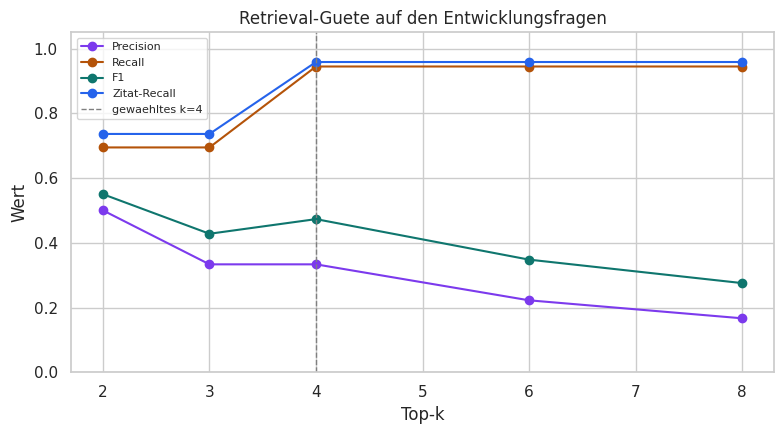

Kriterium: kleinstes k mit maximalem Zitat-Recall (0.958) -> k = 4
Zum Vergleich: hoechstes F1 bei k = 2
Die Auswahlregel bestaetigt TOP_K = 4.

Vorsicht: Grundlage sind nur 6 Entwicklungsfragen. Eine einzelne
Frage verschiebt die Mittelwerte hier um mehrere Prozentpunkte.


In [18]:
# Empirische Justierung von Top-k - ausschliesslich an den Entwicklungsfragen.
#
# Top-k = 4 war bisher ein gesetzter Wert. Die folgende Auswertung belegt ihn
# oder korrigiert ihn. Verwendet werden NUR Entwicklungsfragen; die Testfragen
# bleiben unberuehrt (Abschnitt 6.3).
#
# Der Zielkonflikt: Ein groesseres k erhoeht den Recall, senkt aber die
# Precision und damit den Anteil relevanten Texts im Kontextfenster.

dev_fragen = [f for f in FRAGEN if f["split"] == "dev"]
K_KANDIDATEN = [2, 3, 4, 6, 8]

sweep = []
for k in ([] if PRUEFMODUS else K_KANDIDATEN):
    werte = [retrieval_kennzahlen(hole_kontext(frage, k), frage) for frage in dev_fragen]
    mittel = pd.DataFrame(werte).mean()
    sweep.append({
        "k": k,
        "Precision": mittel["precision"],
        "Recall": mittel["recall"],
        "F1": mittel["f1"],          # Mittel der F1-Werte je Frage, wie in Abschnitt 8
        "Hit@k": mittel["hit"],
        "vollst. Beleg": mittel["vollstaendig"],
        "Zitat-Recall": mittel["zitat_recall"],
        "Kontext-Tokens": mittel["kontext_tokens"],
    })

if PRUEFMODUS:
    sweep_df = pd.read_csv(ERGEBNIS_DIR / "topk_justierung.csv", encoding="utf-8-sig")
    print("Pruefmodus: gespeicherte Justierung geladen - die Auswahlregel unten "
          "rechnet auf diesen Werten.")
else:
    sweep_df = pd.DataFrame(sweep)
display(sweep_df.round(3))

figur, achse = plt.subplots(figsize=(8, 4.5))
for spalte, farbe in [("Precision", "#7c3aed"), ("Recall", "#b45309"),
                      ("F1", "#0f766e"), ("Zitat-Recall", "#2563eb")]:
    achse.plot(sweep_df["k"], sweep_df[spalte], marker="o", label=spalte, color=farbe)
achse.axvline(TOP_K, color="grey", linestyle="--", linewidth=1,
              label=f"gewaehltes k={TOP_K}")
achse.set(xlabel="Top-k", ylabel="Wert", ylim=(0, 1.05),
          title="Retrieval-Guete auf den Entwicklungsfragen")
achse.legend(fontsize=8)
plt.tight_layout()
plt.savefig(ERGEBNIS_DIR / "topk_justierung.png", dpi=150, bbox_inches="tight")
plt.show()

# Auswahlregel (vor Sichtung der Testfragen festgelegt): das kleinste k, ab dem
# die Belegabdeckung nicht mehr steigt. Massgeblich ist der Zitat-Recall - fehlt
# die entscheidende Aussage im Kontext, kann Bedingung B sie nicht nutzen. Ein
# groesseres k fuegt danach nur noch fremde Regeln hinzu. F1 ist als Kriterium
# ungeeignet: Precision@k ist nach oben begrenzt, weil eine Frage meist nur ein
# bis zwei relevante Chunks hat, und belohnt deshalb ein zu kleines k.
kriterium = "Zitat-Recall" if sweep_df["Zitat-Recall"].notna().all() else "Recall"
maximum = sweep_df[kriterium].max()
gewaehltes_k = int(sweep_df.loc[sweep_df[kriterium] >= maximum - 1e-9, "k"].min())
print(f"Kriterium: kleinstes k mit maximalem {kriterium} ({maximum:.3f}) -> k = {gewaehltes_k}")
print(f"Zum Vergleich: hoechstes F1 bei k = {int(sweep_df.loc[sweep_df['F1'].idxmax(), 'k'])}")
if gewaehltes_k != TOP_K:
    print(f"HINWEIS: Die Auswahlregel ergibt k = {gewaehltes_k}, gesetzt ist TOP_K = {TOP_K}.")
    print("Vor dem Einfrieren anpassen und die Aenderung im Text vermerken.")
else:
    print(f"Die Auswahlregel bestaetigt TOP_K = {TOP_K}.")
print(f"\nVorsicht: Grundlage sind nur {len(dev_fragen)} Entwicklungsfragen. Eine einzelne")
print("Frage verschiebt die Mittelwerte hier um mehrere Prozentpunkte.")

sweep_df.to_csv(ERGEBNIS_DIR / "topk_justierung.csv", index=False, encoding="utf-8-sig")


## 9. Durchführung des A/B/C-Vergleichs <a id="9-durchlauf"></a>

Die drei Bedingungen unterscheiden sich ausschließlich im Kontextblock. Die folgende Zelle baut die Prompts und macht diesen Unterschied sichtbar, bevor Kosten entstehen.

In [19]:
# Gemeinsame Anweisung fuer alle drei Bedingungen (Abschnitt 5.2).
#
# Entscheidend: Die Instruktion enthaelt KEINE Formulierung wie "Antworte
# ausschliesslich anhand der Quellen". Eine solche Anweisung wuerde Bedingung A
# bei leerem Kontext zur Verweigerung zwingen und den RAG-Effekt kuenstlich
# vergroessern. Nur der Kontextblock unterscheidet die Bedingungen.

SYSTEM_ANWEISUNG = (
    "Du beantwortest Regelfragen zum Brettspiel CATAN auf Deutsch. "
    "Nenne zuerst die Entscheidung oder das Ergebnis, danach eine knappe "
    "Begründung. Beachte die in der Frage genannte Spielvariante. "
    "Wenn du dir nicht sicher bist, sage das ausdrücklich, statt zu raten. "
    "Antworte in höchstens acht Sätzen."
)

VARIANTEN_NAME = {
    "grundspiel": "CATAN – Das Spiel (Grundspiel, ohne Erweiterungen)",
    "staedte_ritter": "CATAN – Das Spiel mit der Erweiterung Städte & Ritter",
}


def kontext_fuer(frage: dict, bedingung: str):
    """Liefert die Kontext-Chunks einer Bedingung (None fuer A)."""
    if bedingung == "A_ohne_rag":
        return None
    if bedingung == "B_mit_rag":
        return hole_kontext(frage)
    if bedingung == "C_goldkontext":
        return gold_kontext(frage)
    raise ValueError(f"Unbekannte Bedingung: {bedingung}")


def formatiere_kontext(abschnitte: pd.DataFrame) -> str:
    """Identische Kontextdarstellung fuer B und C (Abschnitt 5.2).

    Der Ueberschriftenpfad steht bereits in der ersten Zeile jedes Chunks und
    wird deshalb im Kopf nicht wiederholt.
    """
    bloecke = []
    for _, zeile in abschnitte.iterrows():
        quelle = QUELLEN[zeile["variante"]]["titel"]
        kopf = f"[{zeile['chunk_id']}] {quelle}, Seite {zeile['seite']}"
        bloecke.append(f"{kopf}\n{zeile['text']}")
    return "\n\n---\n\n".join(bloecke)


def baue_prompt(frage: dict, kontext) -> list:
    teile = [f"Spielvariante: {VARIANTEN_NAME[frage['variante']]}"]
    if kontext is not None:
        teile.append(f"Auszüge aus den offiziellen Regelheften:\n\n{formatiere_kontext(kontext)}")
    teile.append(f"Frage: {frage['frage']}")
    return [
        {"role": "system", "content": SYSTEM_ANWEISUNG},
        {"role": "user", "content": "\n\n".join(teile)},
    ]


# Sichtpruefung: Unterscheiden sich die Bedingungen wirklich nur im Kontext?
for bedingung in (() if PRUEFMODUS else BEDINGUNGEN):
    nachrichten = baue_prompt(FRAGEN[0], kontext_fuer(FRAGEN[0], bedingung))
    inhalt = nachrichten[1]["content"]
    print(f"--- {bedingung} - {len(inhalt)} Zeichen ---")
    print(inhalt[:320].replace("\n", " ") + " ...\n")


--- A_ohne_rag - 257 Zeichen ---
Spielvariante: CATAN – Das Spiel (Grundspiel, ohne Erweiterungen)  Frage: Ab wie vielen zusammenhängenden Straßen erhält man im CATAN-Grundspiel die Sondersiegpunkttafel „Längste Handelsroute“, wie viele Siegpunkte ist sie wert, und zählen Abzweigungen mit? ...

--- B_mit_rag - 3983 Zeichen ---
Spielvariante: CATAN – Das Spiel (Grundspiel, ohne Erweiterungen)  Auszüge aus den offiziellen Regelheften:  [GS-09-01] CATAN – Das Spiel. Spielregel, Seite 9 Der Spielablauf im Einzelnen > 2. Handels- und Bauphase > Bauen > Straße (Fortsetzung) Eine Straße darfst du nur an eine Kreuzung anlegen, an die eine deiner eig ...

--- C_goldkontext - 1859 Zeichen ---
Spielvariante: CATAN – Das Spiel (Grundspiel, ohne Erweiterungen)  Auszüge aus den offiziellen Regelheften:  [GS-09-01] CATAN – Das Spiel. Spielregel, Seite 9 Der Spielablauf im Einzelnen > 2. Handels- und Bauphase > Bauen > Straße (Fortsetzung) Eine Straße darfst du nur an eine Kreuzung anlegen, an die ein

### 9.1 Einfrieren des Versuchsplans

Die Prüfsumme wird an dieser Stelle gebildet, nachdem Segmentierung, Top-k und Prompt feststehen: Sie erfasst neben Katalog und Konfiguration auch die Systemanweisung, den Aufbau des Prompts, die Zusammenstellung der Bedingung C und die Implementierung der Suche. Eine spätere Änderung an einem dieser Teile erzeugt eine neue Prüfsumme; bereits gespeicherte Antworten gelten dann nicht mehr als erledigt und werden neu erzeugt. Solange `ENDLAUF = False` gilt, ist der Plan ausdrücklich vorläufig.

In [20]:
# Einfrieren von Katalog und Konfiguration (Abschnitt 6.4).
# Die Pruefsumme dokumentiert, dass nach diesem Punkt nichts mehr veraendert
# wurde. Sie wird mit den Ergebnissen gespeichert.

import inspect

if PRUEFMODUS:
    with open(ERGEBNIS_DIR / "versuchsplan.json", encoding="utf-8") as datei:
        gespeichert = json.load(datei)
    konfiguration = gespeichert["konfiguration"]
    PRUEFSUMME = gespeichert["pruefsumme"]
    eigene_summe = hashlib.sha256(
        "\n".join(chunks["chunk_id"] + "\t" + chunks["text"]).encode("utf-8")).hexdigest()
    print("Pruefmodus: Versuchsplan des Abgabelaufs geladen.")
    print("Pruefsumme:", PRUEFSUMME[:32], "...")
    if eigene_summe == konfiguration.get("chunks_sha256"):
        print("Die aus den Regelheften neu aufgebaute Wissensbasis ist zeichengenau "
              "identisch mit der des Abgabelaufs.")
    else:
        print("ACHTUNG: Die neu aufgebaute Wissensbasis weicht vom Abgabelauf ab. "
              "Andere PDF-Fassung oder andere Programmversionen?")
        print(f"  gespeichert: {konfiguration.get('chunks_sha256', '-')[:32]} ...")
        print(f"  neu:         {eigene_summe[:32]} ...")
    print(f"\nModell des Abgabelaufs: {konfiguration.get('modell_antwort')}, "
          f"Top-k = {konfiguration.get('top_k')}, "
          f"{konfiguration.get('n_fragen')} Fragen, "
          f"{konfiguration.get('n_chunks')} Chunks.")



def quelltext_kurz(*funktionen) -> str:
    """Fingerabdruck der entscheidenden Implementierung."""
    return hashlib.sha256(
        "\n".join(inspect.getsource(f) for f in funktionen).encode("utf-8")).hexdigest()


konfiguration = {} if PRUEFMODUS else {
    "modell_antwort": MODELL_ANTWORT,
    "modell_embedding": MODELL_EMBEDDING,
    "temperatur": TEMPERATUR,
    "max_antwort_tokens": MAX_ANTWORT_TOKENS,
    "chunk_ziel_tokens": CHUNK_ZIEL_TOKENS,
    "chunk_max_tokens": CHUNK_MAX_TOKENS,
    "chunk_min_tokens": CHUNK_MIN_TOKENS,
    # Fingerabdruck der Wissensbasis: aendert sich die Extraktion oder
    # Segmentierung, aendert sich auch die Pruefsumme.
    "chunks_sha256": hashlib.sha256(
        "\n".join(chunks["chunk_id"] + "\t" + chunks["text"]).encode("utf-8")).hexdigest(),
    "ersetzte_regeln": [regel["beleg"] for regel in ERSETZTE_REGELN],
    "top_k": TOP_K,
    "seed": SEED,
    "bedingungen": list(BEDINGUNGEN),
    # Ohne diese vier Eintraege koennte eine Aenderung an Prompt, Kontextaufbau
    # oder Suche unbemerkt bleiben, und die Wiederaufnahme wuerde Antworten aus
    # verschiedenen Staenden mischen (Abschnitt 6.4).
    "system_anweisung": SYSTEM_ANWEISUNG,
    "promptaufbau_sha256": quelltext_kurz(baue_prompt, formatiere_kontext, kontext_fuer),
    "goldkontext_sha256": quelltext_kurz(gold_kontext),
    "retrieval_sha256": quelltext_kurz(suche_lokal, hole_kontext, zugelassene_abschnitte),
    "n_chunks": int(len(chunks)),
    "n_fragen": int(len(katalog)),
    "n_regelgruppen": int(katalog["regelgruppe"].nunique()),
    # Das Register der Regelgruppen gehoert zum Versuchsplan: Eine spaetere
    # Umgruppierung wuerde den Cluster-Bootstrap veraendern.
    "regelgruppen": {kennung: eintrag["verwendung"]
                     for kennung, eintrag in sorted(REGELGRUPPEN.items())},
}

if not PRUEFMODUS:
    katalog_json = katalog.to_json(orient="records", force_ascii=False)
    PRUEFSUMME = hashlib.sha256(
        (katalog_json + json.dumps(konfiguration, sort_keys=True)).encode("utf-8")
    ).hexdigest()

    with open(ERGEBNIS_DIR / "versuchsplan.json", "w", encoding="utf-8") as datei:
        json.dump({"konfiguration": konfiguration, "pruefsumme": PRUEFSUMME},
                  datei, ensure_ascii=False, indent=2)

    zustand = "eingefroren (Endlauf)" if ENDLAUF else "vorlaeufig (Entwicklungsphase)"
    print(f"Versuchsplan {zustand}: {ERGEBNIS_DIR / 'versuchsplan.json'}")
    print("Pruefsumme:", PRUEFSUMME[:32], "...")
if not PRUEFMODUS and ENDLAUF:
    print("\nAb hier werden Katalog und Konfiguration nicht mehr veraendert.")
    print("Aenderungen danach erfordern einen neuen Endlauf mit neuer Pruefsumme.")
elif not PRUEFMODUS:
    print("\nDie Datei wird bei jedem Lauf neu geschrieben. Verbindlich ist sie erst,")
    print("wenn ENDLAUF = True gesetzt und der Katalog fertig geprueft ist.")


Versuchsplan vorlaeufig (Entwicklungsphase): /content/nlp-catan-rag-kiraz/ergebnisse/versuchsplan.json
Pruefsumme: e84680b5b3b0b18e9251fbb240c5944b ...

Die Datei wird bei jedem Lauf neu geschrieben. Verbindlich ist sie erst,
wenn ENDLAUF = True gesetzt und der Katalog fertig geprueft ist.


In [21]:
# A/B/C-Durchlauf mit Wiederaufnahme.
#
# Jede Antwort wird sofort als JSONL-Zeile gespeichert. Bricht die Colab-Sitzung
# ab, setzt ein erneuter Aufruf genau dort fort, wo er aufgehoert hat - bereits
# beantwortete Kombinationen aus Frage, Bedingung und Pruefsumme werden erkannt.
# Fehlgeschlagene Aufrufe gelten nicht als erledigt und werden wiederholt.

def bereits_erledigt() -> set:
    if not LAUF_PROTOKOLL.exists():
        return set()
    erledigt = set()
    with open(LAUF_PROTOKOLL, encoding="utf-8") as datei:
        for zeile in datei:
            try:
                eintrag = json.loads(zeile)
            except json.JSONDecodeError:
                continue
            if eintrag.get("pruefsumme") == PRUEFSUMME and eintrag.get("erfolg"):
                erledigt.add((eintrag["question_id"], eintrag["bedingung"]))
    return erledigt


def rufe_modell(nachrichten: list):
    parameter = dict(model=MODELL_ANTWORT, messages=nachrichten,
                     temperature=TEMPERATUR, seed=SEED)
    try:
        return client.chat.completions.create(max_tokens=MAX_ANTWORT_TOKENS, **parameter)
    except Exception as fehler:
        # Neuere Modelle erwarten max_completion_tokens statt max_tokens
        if "max_completion_tokens" in str(fehler):
            return client.chat.completions.create(
                max_completion_tokens=MAX_ANTWORT_TOKENS, **parameter)
        raise


def frage_modell(frage: dict, bedingung: str) -> dict:
    beginn = time.perf_counter()
    kontext = kontext_fuer(frage, bedingung)
    eintrag = {
        "question_id": frage["question_id"],
        "bedingung": bedingung,
        "pruefsumme": PRUEFSUMME,
        "modell": MODELL_ANTWORT,
        "zeitpunkt": time.strftime("%Y-%m-%dT%H:%M:%S"),
        "kontext_chunks": [] if kontext is None else kontext["chunk_id"].tolist(),
    }
    try:
        antwort = rufe_modell(baue_prompt(frage, kontext))
        eintrag.update({
            "antwort": (antwort.choices[0].message.content or "").strip(),
            "modell_version": antwort.model,
            # "length" bedeutet: am Tokenlimit abgeschnitten. Eine solche
            # Antwort ist kein fachlicher Fehler und muss getrennt sichtbar sein.
            "abbruchgrund": getattr(antwort.choices[0], "finish_reason", None),
            "tokens_eingabe": antwort.usage.prompt_tokens,
            "tokens_ausgabe": antwort.usage.completion_tokens,
            "sekunden": time.perf_counter() - beginn,
            "erfolg": True,
        })
    except Exception as ausnahme:
        eintrag.update({
            "antwort": "", "tokens_eingabe": 0, "tokens_ausgabe": 0,
            "sekunden": time.perf_counter() - beginn,
            "erfolg": False, "fehler": f"{type(ausnahme).__name__}: {str(ausnahme)[:300]}",
        })
    return eintrag


def lade_protokoll() -> pd.DataFrame:
    if not LAUF_PROTOKOLL.exists():
        return pd.DataFrame()
    with open(LAUF_PROTOKOLL, encoding="utf-8") as datei:
        zeilen = [json.loads(z) for z in datei if z.strip()]
    frame = pd.DataFrame([z for z in zeilen
                          if z.get("pruefsumme") == PRUEFSUMME and z.get("erfolg")])
    if frame.empty:
        return frame
    return frame.drop_duplicates(subset=["question_id", "bedingung"], keep="last")


def fuehre_durchlauf_aus(fragen: list, bedingungen=BEDINGUNGEN) -> pd.DataFrame:
    erledigt = bereits_erledigt()
    offen = [(f, b) for f in fragen for b in bedingungen
             if (f["question_id"], b) not in erledigt]
    print(f"{len(erledigt)} Aufrufe bereits erledigt, {len(offen)} offen.")

    fehler_in_folge = 0
    for nummer, (frage, bedingung) in enumerate(offen, start=1):
        eintrag = frage_modell(frage, bedingung)
        with open(LAUF_PROTOKOLL, "a", encoding="utf-8") as datei:
            datei.write(json.dumps(eintrag, ensure_ascii=False) + "\n")
        zustand = "ok" if eintrag["erfolg"] else f"FEHLER - {eintrag['fehler']}"
        print(f"[{nummer}/{len(offen)}] {eintrag['question_id']} "
              f"{bedingung:15s} {zustand} ({eintrag['sekunden']:.1f}s)")
        fehler_in_folge = 0 if eintrag["erfolg"] else fehler_in_folge + 1
        if fehler_in_folge >= 3:
            raise RuntimeError(
                "Drei Aufrufe in Folge sind fehlgeschlagen - Lauf angehalten, um kein "
                f"Budget zu verschwenden. Letzter Fehler: {eintrag['fehler']}\n"
                "Pruefen: Modell-ID, API-Guthaben, Ratenlimit. Danach Zelle erneut "
                "ausfuehren; erledigte Aufrufe werden uebersprungen."
            )
        time.sleep(0.4)                       # schont das Ratenlimit
    return lade_protokoll()


LAUF_SPLITS = ("dev", "test") if ENDLAUF else ("dev",)
lauf_fragen = [f for f in FRAGEN if f["split"] in LAUF_SPLITS]

if PRUEFMODUS:
    antworten = lade_protokoll()
    print(f"Pruefmodus: {len(antworten)} gespeicherte Antworten des Abgabelaufs geladen, "
          f"es wird kein Modell aufgerufen.")
elif MODELL_ANTWORT.startswith("TODO"):
    print("Kein Antwortmodell eingetragen (MODELL_ANTWORT in der Konfiguration).")
    print("Der Durchlauf wird uebersprungen; alle folgenden Zellen laufen ohne Antworten.")
    antworten = lade_protokoll()
else:
    print(f"Phase: {'Endlauf' if ENDLAUF else 'Entwicklung'} - "
          f"{len(lauf_fragen)} Fragen x {len(BEDINGUNGEN)} Bedingungen")
    antworten = fuehre_durchlauf_aus(lauf_fragen)

print(f"\n{len(antworten)} erfolgreiche Antworten zur aktuellen Pruefsumme vorhanden.")
if len(antworten):
    kosten_tokens = antworten["tokens_eingabe"].sum() + antworten["tokens_ausgabe"].sum()
    print(f"Tokens gesamt: {kosten_tokens:,}")
    print(f"Laufzeit gesamt: {antworten['sekunden'].sum() / 60:.1f} Minuten")
    if "modell_version" in antworten:
        print(f"Tatsaechlich bediente Modellversion(en): "
              f"{sorted(antworten['modell_version'].dropna().unique())}")
    if "abbruchgrund" in antworten:
        abgeschnitten = antworten[antworten["abbruchgrund"] == "length"]
        if len(abgeschnitten):
            print(f"WARNUNG: {len(abgeschnitten)} Antwort(en) am Tokenlimit "
                  f"abgeschnitten: {sorted(abgeschnitten['question_id'].unique())}. "
                  f"MAX_ANTWORT_TOKENS erhoehen und diese Faelle neu erzeugen, sonst "
                  f"ist ein technischer Abbruch von einem Regelfehler nicht zu trennen.")
    display(antworten.groupby("bedingung")[["tokens_eingabe", "tokens_ausgabe", "sekunden"]]
            .mean().round(1))


Phase: Entwicklung - 6 Fragen x 3 Bedingungen
0 Aufrufe bereits erledigt, 18 offen.
[1/18] E01 A_ohne_rag      ok (3.6s)
[2/18] E01 B_mit_rag       ok (1.1s)
[3/18] E01 C_goldkontext   ok (1.8s)
[4/18] E02 A_ohne_rag      ok (1.8s)
[5/18] E02 B_mit_rag       ok (2.2s)
[6/18] E02 C_goldkontext   ok (2.6s)
[7/18] E03 A_ohne_rag      ok (2.5s)
[8/18] E03 B_mit_rag       ok (2.0s)
[9/18] E03 C_goldkontext   ok (1.8s)
[10/18] E04 A_ohne_rag      ok (1.5s)
[11/18] E04 B_mit_rag       ok (1.9s)
[12/18] E04 C_goldkontext   ok (1.0s)
[13/18] E05 A_ohne_rag      ok (1.4s)
[14/18] E05 B_mit_rag       ok (2.2s)
[15/18] E05 C_goldkontext   ok (2.2s)
[16/18] E06 A_ohne_rag      ok (7.6s)
[17/18] E06 B_mit_rag       ok (3.1s)
[18/18] E06 C_goldkontext   ok (2.4s)

18 erfolgreiche Antworten zur aktuellen Pruefsumme vorhanden.
Tokens gesamt: 15,114
Laufzeit gesamt: 0.7 Minuten
Tatsaechlich bediente Modellversion(en): ['gpt-4.1-mini-2025-04-14']


,tokens_eingabe,tokens_ausgabe,sekunden
bedingung,,,
A_ohne_rag,157.8,150.2,3.1
B_mit_rag,1283.0,138.3,2.1
C_goldkontext,678.0,111.7,2.0


## 10. Verblindete Bewertung der Antworten <a id="10-bewertung"></a>

Die Bewertung ist der Engpass dieser Arbeit und zugleich der Teil, der nicht automatisiert werden kann. Das Verfahren folgt Abschnitt 5.3: Die Antworten werden gemischt, die Bedingung wird in einer separaten Schlüsseldatei abgelegt, und bewertet wird gegen die vorab festgelegten zwingenden Aussagen und Fehlerkriterien.

Die Zuordnung zur Bedingung wird erst nach Abschluss der Bewertung wiederhergestellt.

Bewertet werden kann auf zwei Wegen: direkt im Notebook (Schalter `BEWERTUNG_IM_NOTEBOOK`, Eingabe Fall für Fall, Speichern nach jedem Fall) oder in der CSV-Datei `bewertungen.csv` mit einer Tabellenkalkulation. Ein bereits ausgefüllter Bogen wird bei erneutem Ausführen nie überschrieben; neue Antworten werden als neue Fälle angehängt.

In [22]:
# Verblindete Bewertung (Abschnitt 5.3).
#
# Die Bedingung wird verborgen, die Reihenfolge zufaellig gemischt und die
# Kontextanzeige ausgeblendet. Bewertet wird gegen die vorab festgelegten
# zwingenden Aussagen und Fehlerkriterien - nicht nach Gesamteindruck.
# Eine alleinige, ungepruefte Bewertung durch ein Sprachmodell ist ausgeschlossen.
#
# Sicherheit: Ein vorhandener Bewertungsbogen wird NIE ueberschrieben. Neue
# Antworten werden als neue Faelle angehaengt. Gehoert der Bogen zu einer
# anderen Pruefsumme (Katalog oder Konfiguration geaendert), wird er
# archiviert und ein neuer angelegt.

BEWERTUNGS_DATEI = ERGEBNIS_DIR / "bewertungen.csv"
SCHLUESSEL_DATEI = ERGEBNIS_DIR / "bewertung_schluessel.csv"
ZWEITBEWERTUNG_AUSWAHL = ERGEBNIS_DIR / "zweitbewertung_auswahl.csv"
BEWERTUNGS_SPALTEN = ["korrektheit", "entscheidung", "begruendung",
                      "enthaltung", "fehlerart", "notiz"]

# Auf True setzen, um die offenen Faelle direkt hier im Notebook zu bewerten
# (Eingabe per Tastatur, Speichern nach jedem Fall). Alternativ die CSV-Datei
# in Excel/LibreOffice/Google Sheets ausfuellen und als CSV zurueckspeichern.
BEWERTUNG_IM_NOTEBOOK = False

BEWERTUNGSSCHEMA = """
korrektheit   : 2 = alle zwingenden Aussagen vorhanden, kein Fehlerkriterium
                    erfuellt und keine Behauptung, die dem Regelheft
                    widerspricht - auch keine ungefragte (Abschnitt 5.3)
                1 = die verlangte Entscheidung oder Zahl ist richtig, aber eine
                    zwingende Aussage fehlt ODER die Antwort stellt zusaetzlich
                    eine dem Heft widersprechende Behauptung auf
                0 = die verlangte Entscheidung oder Zahl ist falsch, ODER ein
                    Fehlerkriterium ist erfuellt, ODER die Begruendung der
                    verlangten Aussage beruht auf einer erfundenen Regel
                Faustregel: Was die verlangte Aussage traegt, entscheidet
                zwischen 0 und 1; was danebensteht, zwischen 1 und 2.
entscheidung  : 1 = richtige Entscheidung, 0 = falsch, leer = Frage verlangt keine
begruendung   : 1 = fachlich ausreichend, 0 = unzureichend oder falsch
enthaltung    : 1 = Modell verweigert oder weicht aus
fehlerart     : frei, z.B. 'Grundspiel-Erweiterung verwechselt',
                'Ausnahme uebersehen', 'Rechenfehler', 'veraltete Edition'
"""


def lies_csv(pfad: Path) -> pd.DataFrame:
    """Liest CSV robust: Komma oder Semikolon (deutsches Excel), UTF-8 oder ANSI."""
    for kodierung in ("utf-8-sig", "cp1252"):
        try:
            return pd.read_csv(pfad, sep=None, engine="python", encoding=kodierung,
                               dtype=str, keep_default_na=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{pfad} ist weder UTF-8 noch ANSI kodiert.")


def als_text(wert) -> str:
    return " | ".join(wert) if isinstance(wert, (list, tuple)) else str(wert)


CHUNK_MARKE = re.compile(r"\[?\b(?:GS|SR)-\d{2}-\d{2}\b\]?")


def verblinde(antwort: str) -> str:
    """Entfernt Chunk-Kennungen aus der Anzeige der Antwort.

    Modelle uebernehmen die Kennungen aus dem Kontextkopf ("[SR-04-02]") in
    ihre Antwort. Im Bewertungsbogen wuerde das verraten, dass ueberhaupt ein
    Kontext vorlag, und die Verblindung gegenueber Bedingung A aufheben. Die
    Originalantwort bleibt im Laufprotokoll unveraendert; ersetzt wird nur die
    Anzeige, und zwar in allen Bedingungen gleich.
    """
    return re.sub(r"\s{2,}", " ", CHUNK_MARKE.sub("[Quelle]", str(antwort))).strip()


def erzeuge_oder_ergaenze_bogen(antworten: pd.DataFrame) -> pd.DataFrame:
    bogen, schluessel = pd.DataFrame(), pd.DataFrame()
    if BEWERTUNGS_DATEI.exists() and SCHLUESSEL_DATEI.exists():
        bogen, schluessel = lies_csv(BEWERTUNGS_DATEI), lies_csv(SCHLUESSEL_DATEI)
        if set(schluessel.get("pruefsumme", [])) - {PRUEFSUMME}:
            stempel = time.strftime("%Y%m%d-%H%M%S")
            for datei in (BEWERTUNGS_DATEI, SCHLUESSEL_DATEI):
                datei.rename(datei.with_name(f"{datei.stem}_archiv_{stempel}.csv"))
            print(f"Bogen gehoerte zu einer frueheren Pruefsumme - archiviert ({stempel}).")
            bogen, schluessel = pd.DataFrame(), pd.DataFrame()

    bekannt = set(zip(schluessel.get("question_id", []), schluessel.get("bedingung", [])))
    neu = antworten[[(q, b) not in bekannt for q, b in
                     zip(antworten["question_id"], antworten["bedingung"])]]
    if neu.empty:
        return bogen

    # Erst mischen, DANN nummerieren - sonst verriete die laufende Nummer die
    # urspruengliche Sortierung nach Bedingung.
    start = len(schluessel)
    neu = neu.sample(frac=1.0, random_state=SEED + start).reset_index(drop=True)
    neu = neu.assign(fall_id=[f"F{start + i:03d}" for i in range(len(neu))])

    neuer_schluessel = neu[["fall_id", "question_id", "bedingung"]].assign(pruefsumme=PRUEFSUMME)
    neu = neu.assign(antwort=neu["antwort"].map(verblinde))
    sichtbar = neu[["fall_id", "question_id", "antwort"]].merge(
        katalog[["question_id", "frage", "referenzantwort",
                 "zwingende_aussagen", "fehlerkriterien"]], on="question_id", how="left")
    neuer_bogen = sichtbar[["fall_id", "frage", "antwort", "referenzantwort",
                            "zwingende_aussagen", "fehlerkriterien"]].copy()
    for spalte in ["zwingende_aussagen", "fehlerkriterien"]:
        neuer_bogen[spalte] = neuer_bogen[spalte].map(als_text)
    for spalte in BEWERTUNGS_SPALTEN:
        neuer_bogen[spalte] = ""

    bogen = pd.concat([bogen, neuer_bogen], ignore_index=True)
    schluessel = pd.concat([schluessel, neuer_schluessel], ignore_index=True)
    bogen.to_csv(BEWERTUNGS_DATEI, index=False, encoding="utf-8-sig")
    schluessel.to_csv(SCHLUESSEL_DATEI, index=False, encoding="utf-8-sig")
    print(f"{len(neuer_bogen)} neue Faelle an den Bewertungsbogen angehaengt.")
    ziehe_zweitbewertung(schluessel)
    return bogen


def ziehe_zweitbewertung(schluessel: pd.DataFrame) -> None:
    """Zieht die Teilmenge fuer die Zweitbewertung, bevor bewertet wird.

    Zehn Fragen mit allen drei Antworten. Die Ziehung haengt nur am Seed und
    an den Fragekennungen, nicht an Antworten oder Bewertungen, und sie
    geschieht beim Anlegen des Bogens - nicht, nachdem die Ergebnisse bekannt
    sind. Gespeichert werden nur Fall-Kennungen, damit die zweite Person die
    Bedingung nicht erkennt.
    """
    # Nur fuer den Endlauf: Die Zweitbewertung betrifft die Testfaelle. Eine in
    # der Entwicklungsphase gezogene Auswahl wuerde sonst bestehen bleiben und
    # die Ziehung fuer den Endlauf blockieren.
    if not (ENDLAUF or PRUEFMODUS):
        return
    if ZWEITBEWERTUNG_AUSWAHL.exists() or schluessel.empty:
        return
    pool = katalog[katalog["split"] == ("test" if ENDLAUF else "dev")]["question_id"]
    pool = sorted(set(pool) & set(schluessel["question_id"]))
    if not pool:
        return
    stichprobe = sorted(pd.Series(pool).sample(min(10, len(pool)), random_state=SEED))
    faelle = schluessel[schluessel["question_id"].isin(stichprobe)][["fall_id"]]
    faelle.to_csv(ZWEITBEWERTUNG_AUSWAHL, index=False, encoding="utf-8-sig")
    print(f"Auswahl fuer die Zweitbewertung gezogen: {len(stichprobe)} Fragen, "
          f"{len(faelle)} Faelle -> {ZWEITBEWERTUNG_AUSWAHL.name}")
    print("Diese Fall-Kennungen gehen an die zweite Person; der Bogen enthaelt "
          "weder Bedingung noch Kontext.")


def zeige_fall(bogen: pd.DataFrame, position: int) -> None:
    """Zeigt einen Fall zur Bewertung - ohne Bedingung und ohne Kontext."""
    fall = bogen.iloc[position]
    print("=" * 78)
    print(f"FALL {fall['fall_id']}  ({position + 1} von {len(bogen)})")
    print("=" * 78)
    print(f"\nFRAGE:\n{fall['frage']}\n")
    print(f"ANTWORT DES SYSTEMS:\n{fall['antwort']}\n")
    print("-" * 78)
    print(f"REFERENZANTWORT:\n{fall['referenzantwort']}\n")
    print("ZWINGEND ERFORDERLICH:")
    for aussage in str(fall["zwingende_aussagen"]).split(" | "):
        print(f"  [ ] {aussage}")
    print("\nFEHLERKRITERIEN:")
    for kriterium in str(fall["fehlerkriterien"]).split(" | "):
        print(f"  [ ] {kriterium}")
    print("=" * 78)


def bewerte_im_notebook() -> None:
    """Fuehrt durch alle offenen Faelle und speichert nach jedem Fall."""
    bogen = lies_csv(BEWERTUNGS_DATEI)
    offen = [i for i in range(len(bogen)) if not bogen.at[i, "korrektheit"].strip()]
    print(f"{len(offen)} offene Faelle. Eingabe 'q' unterbricht; Fortsetzung jederzeit.\n")
    for i in offen:
        zeige_fall(bogen, i)
        wert = input("Korrektheit (2/1/0, q = Pause): ").strip().lower()
        if wert == "q":
            break
        if wert not in {"0", "1", "2"}:
            print("Ungueltige Eingabe - Fall bleibt offen.\n")
            continue
        bogen.at[i, "korrektheit"] = wert
        bogen.at[i, "entscheidung"] = input("Entscheidung richtig? (1/0/leer): ").strip()
        bogen.at[i, "begruendung"] = input("Begruendung ausreichend? (1/0): ").strip()
        bogen.at[i, "enthaltung"] = input("Enthaltung? (1/leer): ").strip()
        bogen.at[i, "fehlerart"] = input("Fehlerart (leer, wenn korrekt): ").strip()
        bogen.to_csv(BEWERTUNGS_DATEI, index=False, encoding="utf-8-sig")
        print("gespeichert.\n")
    rest = sum(1 for w in lies_csv(BEWERTUNGS_DATEI)["korrektheit"] if not w.strip())
    print(f"Noch offen: {rest}")


if len(antworten):
    bogen = erzeuge_oder_ergaenze_bogen(antworten)
    offen = int((bogen["korrektheit"].str.strip() == "").sum())
    print(BEWERTUNGSSCHEMA)
    print(f"Bewertungsbogen: {BEWERTUNGS_DATEI} ({len(bogen)} Faelle, {offen} offen)")
    print("Schluesseldatei (Bedingungszuordnung) separat gespeichert - waehrend der")
    print("Bewertung nicht oeffnen.\n")
    if BEWERTUNG_IM_NOTEBOOK:
        bewerte_im_notebook()
    elif offen:
        zeige_fall(bogen, int(np.argmax(bogen["korrektheit"].str.strip() == "")))
else:
    print("Noch keine Antworten vorhanden - Bewertung entfaellt vorerst.")


Bogen gehoerte zu einer frueheren Pruefsumme - archiviert (20260923-162200).
18 neue Faelle an den Bewertungsbogen angehaengt.

korrektheit   : 2 = alle zwingenden Aussagen vorhanden, kein Fehlerkriterium
                    erfuellt und keine Behauptung, die dem Regelheft
                    widerspricht - auch keine ungefragte (Abschnitt 5.3)
                1 = die verlangte Entscheidung oder Zahl ist richtig, aber eine
                    zwingende Aussage fehlt ODER die Antwort stellt zusaetzlich
                    eine dem Heft widersprechende Behauptung auf
                0 = die verlangte Entscheidung oder Zahl ist falsch, ODER ein
                    Fehlerkriterium ist erfuellt, ODER die Begruendung der
                    verlangten Aussage beruht auf einer erfundenen Regel
                Faustregel: Was die verlangte Aussage traegt, entscheidet
                zwischen 0 und 1; was danebensteht, zwischen 1 und 2.
entscheidung  : 1 = richtige Entscheidung, 0 = falsch, lee

In [23]:
# Bewertungen einlesen und mit der Schluesseldatei zusammenfuehren.
# Erst hier wird die Bedingung wieder sichtbar.

def lade_bewertungen() -> pd.DataFrame:
    """Liest den Bewertungsbogen und verlangt Vollstaendigkeit nur dort, wo sie zaehlt.

    Im Endlauf enthaelt der Bogen auch die Entwicklungsfaelle. Die gehen in
    keine Kennzahl ein; unbewertet zu lassen ist zulaessig und spart Zeit.
    Fuer die ausgewertete Gruppe - im Endlauf die Testfragen - muss dagegen
    jeder Fall bewertet sein, sonst waere der Anteil korrekter Antworten von
    der Reihenfolge der Bearbeitung abhaengig.
    """
    bewertet = lies_csv(BEWERTUNGS_DATEI)
    schluessel = lies_csv(SCHLUESSEL_DATEI)
    werte = bewertet["korrektheit"].str.strip()
    ungueltig = sorted(set(werte) - {"0", "1", "2", ""})
    if ungueltig:
        raise AssertionError(f"Ungueltige Korrektheitswerte: {ungueltig}")

    zusammen = bewertet.assign(korrektheit=werte).merge(
        schluessel[["fall_id", "question_id", "bedingung"]], on="fall_id", how="left")
    zusammen = zusammen.merge(
        katalog[["question_id", "split", "fragetyp", "variante", "regelgruppe"]],
        on="question_id", how="left")

    massgeblich = "test" if (ENDLAUF or PRUEFMODUS) else "dev"
    pflicht = zusammen["split"] == massgeblich
    offen = int((pflicht & (zusammen["korrektheit"] == "")).sum())
    if offen:
        raise AssertionError(
            f"{offen} von {int(pflicht.sum())} Faellen der Gruppe '{massgeblich}' "
            f"sind noch nicht bewertet. Die Auswertung setzt diese Gruppe "
            f"vollstaendig bewertet voraus; Faelle der anderen Gruppe duerfen "
            f"leer bleiben."
        )
    uebersprungen = int((~pflicht & (zusammen["korrektheit"] == "")).sum())
    if uebersprungen:
        print(f"{uebersprungen} unbewertete Faelle ausserhalb der Gruppe "
              f"'{massgeblich}' werden nicht ausgewertet.")
    zusammen = zusammen[zusammen["korrektheit"] != ""].copy()
    zusammen["korrektheit"] = zusammen["korrektheit"].astype(int)
    zusammen["vollstaendig_korrekt"] = (zusammen["korrektheit"] == 2).astype(int)
    return zusammen


try:
    bewertungen = lade_bewertungen()
    print(f"{len(bewertungen)} Bewertungen eingelesen.")
    display(bewertungen.groupby("bedingung")["korrektheit"]
            .value_counts().unstack(fill_value=0))
except (FileNotFoundError, AssertionError, KeyError) as hinweis:
    print(f"Noch keine vollstaendigen Bewertungen: {hinweis}")
    bewertungen = pd.DataFrame()

# Ausgewertet werden die Testfragen. Solange nur Entwicklungsfragen bewertet
# sind, laeuft die Auswertung als ausdruecklich VORLAEUFIGE Probe.
if len(bewertungen) and (bewertungen["split"] == "test").any():
    auswertung = bewertungen[bewertungen["split"] == "test"].copy()
    AUSWERTUNGSBASIS = "Testfragen"
elif len(bewertungen):
    auswertung = bewertungen.copy()
    AUSWERTUNGSBASIS = "VORLAEUFIG - nur Entwicklungsfragen"
else:
    auswertung, AUSWERTUNGSBASIS = pd.DataFrame(), "keine"
print(f"\nAuswertungsbasis: {AUSWERTUNGSBASIS}")

# Uebereinstimmung mit einer zweiten bewertenden Person (Abschnitt 5.3).
ZWEITBEWERTUNG = ERGEBNIS_DIR / "bewertungen_zweitperson.csv"

if ZWEITBEWERTUNG.exists() and len(auswertung):
    zweit = lies_csv(ZWEITBEWERTUNG)
    zweit = zweit[zweit["korrektheit"].str.strip().isin(["0", "1", "2"])]
    paare = bewertungen.merge(
        zweit[["fall_id", "korrektheit"]].assign(korrektheit=lambda d: d["korrektheit"].astype(int)),
        on="fall_id", suffixes=("", "_zweit"))
    beobachtet = (paare["korrektheit"] == paare["korrektheit_zweit"]).mean()
    haeufig_a = paare["korrektheit"].value_counts(normalize=True)
    haeufig_b = paare["korrektheit_zweit"].value_counts(normalize=True)
    zufall = sum(haeufig_a.get(k, 0) * haeufig_b.get(k, 0) for k in [0, 1, 2])
    kappa = (beobachtet - zufall) / (1 - zufall) if zufall < 1 else float("nan")

    # Massgeblich ist die binaere Hauptkennzahl "vollstaendig korrekt oder nicht".
    binaer_a = (paare["korrektheit"] == 2).astype(int)
    binaer_b = (paare["korrektheit_zweit"] == 2).astype(int)
    beob_bin = (binaer_a == binaer_b).mean()
    zufall_bin = sum(binaer_a.eq(k).mean() * binaer_b.eq(k).mean() for k in (0, 1))
    kappa_bin = (beob_bin - zufall_bin) / (1 - zufall_bin) if zufall_bin < 1 else float("nan")

    print(f"\nZweitbewertung: {len(paare)} Faelle")
    print(f"Binaer (vollstaendig korrekt ja/nein) - die Hauptkennzahl:")
    print(f"  Uebereinstimmung: {beob_bin:.1%}   Cohens Kappa: {kappa_bin:.3f}")
    print(f"Drei Stufen (falsch / teilweise / vollstaendig), nachrangig:")
    print(f"  Uebereinstimmung: {beobachtet:.1%}   Cohens Kappa: {kappa:.3f}")
else:
    print("\nKeine Zweitbewertung vorhanden.")
    print("EINSCHRAENKUNG fuer die Reflexion: Alle Antworten wurden von einer")
    print("einzigen Person bewertet. Die Zuverlaessigkeit der Bewertung konnte")
    print("nicht unabhaengig geprueft werden.")


Noch keine vollstaendigen Bewertungen: 18 von 18 Faellen der Gruppe 'dev' sind noch nicht bewertet. Die Auswertung setzt diese Gruppe vollstaendig bewertet voraus; Faelle der anderen Gruppe duerfen leer bleiben.

Auswertungsbasis: keine

Keine Zweitbewertung vorhanden.
EINSCHRAENKUNG fuer die Reflexion: Alle Antworten wurden von einer
einzigen Person bewertet. Die Zuverlaessigkeit der Bewertung konnte
nicht unabhaengig geprueft werden.


## 11. Ergebnisse, Unsicherheit und Fehleranalyse <a id="11-ergebnisse"></a>

Die Auswertung berichtet die Korrektheit primär je Fragetyp, weil die Verteilung der Fragetypen bewusst ungleich ist (Abschnitt 6.2). Anschließend wird die Unsicherheit über einen gepaarten Cluster-Bootstrap auf Regelgruppenebene bestimmt und die Fehler werden nach Retrieval- und Generierungsanteil aufgeschlüsselt.

In [24]:
# Primaerauswertung: Korrektheitsanteil je Bedingung und Fragetyp.
#
# Wichtig (Abschnitt 6.2): Die Verteilung der Fragetypen ist bewusst ungleich.
# Der gepoolte Wert ist deshalb KEINE "typische Leistung"; massgeblich ist die
# Aufschluesselung nach Fragetyp.

vollstaendig = len(auswertung) and set(BEDINGUNGEN) <= set(auswertung["bedingung"])
if vollstaendig:
    display(Markdown(f"**Auswertungsbasis: {AUSWERTUNGSBASIS}**"))
    gesamt = (auswertung.groupby("bedingung")["vollstaendig_korrekt"]
              .agg(["mean", "sum", "count"]))
    gesamt.columns = ["Anteil korrekt", "korrekt", "Fragen"]
    gesamt["Anteil korrekt"] = (gesamt["Anteil korrekt"] * 100).round(1)
    display(Markdown("#### Gesamt (gepoolt - mit Vorsicht zu lesen)"))
    display(gesamt)

    nach_typ = (auswertung.pivot_table(index="fragetyp", columns="bedingung",
                                       values="vollstaendig_korrekt", aggfunc="mean")
                .mul(100).round(1))
    display(Markdown("#### Nach Fragetyp - das massgebliche Ergebnis"))
    display(nach_typ)

    nach_variante = (auswertung.pivot_table(index="variante", columns="bedingung",
                                            values="vollstaendig_korrekt", aggfunc="mean")
                     .mul(100).round(1))
    display(Markdown("#### Nach Spielvariante"))
    display(nach_variante)

    # Gepaarte Gegenueberstellung A gegen B
    breit = auswertung.pivot_table(index="question_id", columns="bedingung",
                                   values="vollstaendig_korrekt")
    nur_b = int(((breit["B_mit_rag"] == 1) & (breit["A_ohne_rag"] == 0)).sum())
    nur_a = int(((breit["A_ohne_rag"] == 1) & (breit["B_mit_rag"] == 0)).sum())
    beide = int(((breit["A_ohne_rag"] == 1) & (breit["B_mit_rag"] == 1)).sum())
    keine = int(((breit["A_ohne_rag"] == 0) & (breit["B_mit_rag"] == 0)).sum())

    display(Markdown("#### Gepaarte Vierfeldertafel A gegen B"))
    display(pd.DataFrame(
        [[beide, nur_b], [nur_a, keine]],
        index=["B korrekt", "B falsch"], columns=["A korrekt", "A falsch"],
    ))
    print(f"\nDiskordante Paare: {nur_b} nur B korrekt, {nur_a} nur A korrekt.")
    print("Nur diese Paare tragen zur statistischen Aussage bei (Abschnitt 5.6).")

    gesamt.to_csv(ERGEBNIS_DIR / "korrektheit_gesamt.csv", encoding="utf-8-sig")
    nach_typ.to_csv(ERGEBNIS_DIR / "korrektheit_nach_fragetyp.csv", encoding="utf-8-sig")
else:
    print("Keine vollstaendigen Bewertungen fuer alle drei Bedingungen - Auswertung uebersprungen.")


Keine vollstaendigen Bewertungen fuer alle drei Bedingungen - Auswertung uebersprungen.


In [25]:
# Gepaarter Cluster-Bootstrap auf Regelgruppenebene (Abschnitt 5.5).
#
# Fragen derselben Regelgruppe sind inhaltlich abhaengig. Gezogen werden daher
# ganze Gruppen mit allen enthaltenen Fragen - fuer beide Bedingungen dieselben.
# Schaetzziel ist die mittlere Korrektheit JE FRAGE.

def cluster_bootstrap(daten: pd.DataFrame, bedingung_a: str, bedingung_b: str,
                      ziehungen: int = BOOTSTRAP_ZIEHUNGEN, seed: int = SEED) -> dict:
    breit = daten.pivot_table(index="question_id", columns="bedingung",
                              values="vollstaendig_korrekt")
    gruppe_je_frage = katalog.set_index("question_id")["regelgruppe"]
    breit["regelgruppe"] = breit.index.map(gruppe_je_frage)

    gruppen = sorted(breit["regelgruppe"].unique())
    mitglieder = {g: breit[breit["regelgruppe"] == g] for g in gruppen}
    zufall = np.random.default_rng(seed)

    differenzen = []
    for _ in range(ziehungen):
        gezogen = zufall.integers(0, len(gruppen), size=len(gruppen))
        stichprobe = pd.concat([mitglieder[gruppen[i]] for i in gezogen])
        differenzen.append(stichprobe[bedingung_b].mean() - stichprobe[bedingung_a].mean())

    differenzen = np.asarray(differenzen) * 100
    return {
        "vergleich": f"{bedingung_b} minus {bedingung_a}",
        "anteil_a": breit[bedingung_a].mean() * 100,
        "anteil_b": breit[bedingung_b].mean() * 100,
        "punktschaetzung": (breit[bedingung_b].mean() - breit[bedingung_a].mean()) * 100,
        "ki_unten": float(np.quantile(differenzen, 0.025)),
        "ki_oben": float(np.quantile(differenzen, 0.975)),
        "n_gruppen": len(gruppen),
        "n_fragen": len(breit),
    }


if vollstaendig:
    vergleiche = [
        ("A_ohne_rag", "B_mit_rag"),          # primaerer Vergleich
        ("B_mit_rag", "C_goldkontext"),       # diagnostischer Vergleich
    ]
    bootstrap_ergebnisse = pd.DataFrame(
        [cluster_bootstrap(auswertung, a, b) for a, b in vergleiche])
    # Die Pruefsumme wandert in die Datei: So laesst sich spaeter erkennen, ob
    # die Zahlen zum aktuellen Versuchsstand gehoeren oder aus einem frueheren.
    bootstrap_ergebnisse["pruefsumme"] = PRUEFSUMME
    display(Markdown(f"**Auswertungsbasis: {AUSWERTUNGSBASIS}**"))
    display(bootstrap_ergebnisse.round(2))

    bootstrap_ergebnisse.to_csv(ERGEBNIS_DIR / "bootstrap.csv",
                                index=False, encoding="utf-8-sig")

    primaer = bootstrap_ergebnisse.iloc[0]
    print(f"\nPrimaerer Vergleich B gegen A: "
          f"{primaer['punktschaetzung']:+.1f} Prozentpunkte "
          f"[95%-Intervall {primaer['ki_unten']:+.1f}; {primaer['ki_oben']:+.1f}]")
    print(f"Grundlage: {primaer['n_fragen']} Fragen in {primaer['n_gruppen']} Regelgruppen.")
    print("\nDas Intervall beschreibt die Unsicherheit durch die Auswahl der")
    print("Regelgruppen. Es beschreibt NICHT die Streuung wiederholter")
    print("Generierungen - dafuer waere mehr als ein Durchlauf je Frage noetig.")
else:
    print("Keine vollstaendigen Bewertungen - Bootstrap uebersprungen.")


Keine vollstaendigen Bewertungen - Bootstrap uebersprungen.


In [26]:
if vollstaendig:
    figur, achsen = plt.subplots(1, 2, figsize=(13, 5))

    # Links: Korrektheit je Bedingung und Fragetyp
    daten = (auswertung.groupby(["fragetyp", "bedingung"])["vollstaendig_korrekt"]
             .mean().mul(100).reset_index())
    sns.barplot(data=daten, x="fragetyp", y="vollstaendig_korrekt",
                hue="bedingung", hue_order=list(BEDINGUNGEN), ax=achsen[0],
                palette=["#94a3b8", "#2563eb", "#059669"])
    achsen[0].set(title=f"Anteil vollstaendig korrekter Antworten ({AUSWERTUNGSBASIS})",
                  xlabel="", ylabel="Anteil in %", ylim=(0, 100))
    achsen[0].legend(title="Bedingung", fontsize=8)
    for behaelter in achsen[0].containers:
        achsen[0].bar_label(behaelter, fmt="%.0f", padding=2, fontsize=8)

    # Rechts: Retrieval-Metriken je Fragetyp (gleiche Fragenbasis)
    basis = retrieval_ergebnisse[retrieval_ergebnisse["question_id"]
                                 .isin(auswertung["question_id"])]
    retrieval_lang = basis.melt(id_vars="fragetyp",
                                value_vars=[f"precision@{TOP_K}", f"recall@{TOP_K}", "f1"],
                                var_name="Metrik", value_name="Wert")
    sns.barplot(data=retrieval_lang, x="fragetyp", y="Wert", hue="Metrik",
                ax=achsen[1], palette=["#7c3aed", "#b45309", "#0f766e"])
    achsen[1].set(title=f"Retrieval-Guete bei k={TOP_K}",
                  xlabel="", ylabel="Wert", ylim=(0, 1))
    achsen[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(ERGEBNIS_DIR / "ergebnisse.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Abbildung gespeichert: {ERGEBNIS_DIR / 'ergebnisse.png'}")
else:
    print("Keine vollstaendigen Bewertungen - Diagramme uebersprungen.")


Keine vollstaendigen Bewertungen - Diagramme uebersprungen.


In [27]:
# Fehleranalyse: Trennung von Retrieval- und Generierungsfehlern.
#
# Die Zuordnung ist ein Hinweis, keine bewiesene Ursache (Abschnitt 5.1).

if vollstaendig:
    breit = auswertung.pivot_table(index="question_id", columns="bedingung",
                                   values="vollstaendig_korrekt")
    breit = breit.merge(
        retrieval_ergebnisse.set_index("question_id")[["hit@k", "gold_vollstaendig",
                                                       "zitat_recall"]],
        left_index=True, right_index=True, how="left")

    # Vollstaendig heisst hier: Alle Gold-Chunks der Frage waren in Bedingung B
    # enthalten - nicht nur irgendein Chunk der richtigen Seite. Die Bezeichnungen
    # beschreiben den Befund und behaupten keine Ursache (Abschnitt 5.1).
    def diagnose(zeile) -> str:
        if zeile["B_mit_rag"] == 1:
            return "B korrekt"
        if zeile["C_goldkontext"] == 1 and zeile["gold_vollstaendig"] < 1:
            return "B falsch, C richtig; erforderliche Belege in B unvollstaendig"
        if zeile["C_goldkontext"] == 1:
            return "B falsch, C richtig; erforderliche Belege in B vorhanden"
        return "Auch mit Gold-Kontext keine vollstaendig korrekte Antwort"

    breit["diagnose"] = breit.apply(diagnose, axis=1)
    display(Markdown(f"#### Fehlerdiagnose ({AUSWERTUNGSBASIS})"))
    display(breit["diagnose"].value_counts().to_frame("Fragen"))

    # Fehlerarten aus der manuellen Bewertung
    arten = auswertung[auswertung["korrektheit"] < 2]["fehlerart"].fillna("").str.strip()
    arten = arten[arten != ""]
    if len(arten):
        display(Markdown("#### Manuell vergebene Fehlerarten"))
        display(arten.value_counts().to_frame("Haeufigkeit"))

    # Vollstaendige Falldarstellung der diagnostisch interessanten Faelle
    interessant = breit[breit["diagnose"].str.startswith("B falsch")].index
    for kennung in list(interessant)[:5]:
        frage = katalog[katalog["question_id"] == kennung].iloc[0]
        print("=" * 78)
        print(f"{kennung} - {frage['fragetyp']} - {frage['variante']}")
        print(f"Frage: {frage['frage'][:200]}")
        for bedingung in BEDINGUNGEN:
            passend = antworten[(antworten["question_id"] == kennung) &
                                (antworten["bedingung"] == bedingung)]
            if not passend.empty:
                print(f"\n[{bedingung}] {passend.iloc[0]['antwort'][:280]}")
        print(f"\nReferenz: {frage['referenzantwort'][:280]}")
        print()

    breit.to_csv(ERGEBNIS_DIR / "fehlerdiagnose.csv", encoding="utf-8-sig")
    print(f"Gespeichert: {ERGEBNIS_DIR / 'fehlerdiagnose.csv'}")
else:
    print("Keine vollstaendigen Bewertungen - Fehleranalyse uebersprungen.")


Keine vollstaendigen Bewertungen - Fehleranalyse uebersprungen.


## 12. Kritische Reflexion und Fazit <a id="12-fazit"></a>

_Dieser Abschnitt wird nach dem Endlauf vollständig selbst formuliert. Die folgenden Leitfragen strukturieren ihn; sie sind keine Antworten._

### 12.1 Einordnung der Ergebnisse

- Wie groß ist der gemessene Unterschied zwischen A und B, und wie breit ist sein Unsicherheitsintervall?
- Unterscheidet sich der Effekt zwischen Fakten-, Ausnahme- und Anwendungsfragen so, wie in H2 vermutet?
- Wie viele Fragen sind in B falsch und in C richtig — und was sagt das über die Aufteilung zwischen Retrieval- und Generierungsfehlern?
- Wie verhält sich das Ergebnis zu der in Abschnitt 5.4 formulierten Erwartung, dass Vorwissen den Effekt bei Faktenfragen dämpft?

### 12.2 Vergleich zum Stand der Technik

- Die Arbeit entwickelt kein neues Verfahren. Wo liegt der Beitrag, und wo endet er?
- Welche Aussagen aus der Literatur werden durch die eigenen Ergebnisse gestützt, welche nicht?
- Warum wäre ein Vergleich der eigenen Korrektheitswerte mit publizierten RAG-Ergebnissen nicht belastbar?

### 12.3 Aufgetretene Schwierigkeiten

- Welche Probleme traten bei der Textextraktion auf, und wie wurden sie gelöst?
- Wie verlässlich war die Zuordnung von Anwendbarkeit und ersetzenden Regeln?
- Welche Fragen mussten verworfen werden, und warum?
- Welche technischen Hürden gab es bei Indexierung, API-Nutzung oder Wiederaufnahme?

### 12.4 Grenzen

- Ein Antwortmodell, ein Durchlauf je Frage und Bedingung: Die Varianz wiederholter Generierungen wurde nicht geschätzt.
- Der Katalog ist klein; die Erwartungsklausel aus Abschnitt 5.6 begrenzt die statistische Aussagekraft.
- Die Bewertung erfolgte durch eine Person beziehungsweise mit einer Teilmenge durch eine zweite Person; die Übereinstimmung ist zu berichten.
- Der Korpus umfasst zwei Regelhefte eines Spiels. Eine Übertragung auf andere Domänen ist nicht belegt.
- Bedingung C ist eine Diagnose, keine Obergrenze.
- Die Belegtreue der Antworten (stützt sich die Antwort tatsächlich auf den Kontext?) wurde nicht gesondert gemessen.

### 12.5 Was über das Problem gelernt wurde

- Unter welchen Bedingungen lohnt sich RAG bei einem Korpus, den das Modell vermutlich bereits kennt?
- Welche Rolle spielt die Segmentierung für Regeltexte mit Ausnahmen?
- Was bedeutet der Befund für den praktischen Einsatz solcher Systeme in Domänen mit versionierten Regelwerken?


## 13. Literatur und Quellen <a id="13-literatur"></a>

Zitiert wird jeweils die begutachtete Fassung (Konferenzband, Zeitschrift, Lehrbuch). Die Nummern entsprechen der Reihenfolge der ersten Nennung im Text.

### Wissenschaftliche Literatur

[1] Lewis, P.; Perez, E.; Piktus, A.; Petroni, F.; Karpukhin, V.; Goyal, N.; Küttler, H.; Lewis, M.; Yih, W.; Rocktäschel, T.; Riedel, S.; Kiela, D. (2020): *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks.* In: Advances in Neural Information Processing Systems 33 (NeurIPS 2020), S. 9459–9474. https://proceedings.neurips.cc/paper_files/paper/2020/file/6b493230205f780e1bc26945df7481e5-Paper.pdf

[2] Karpukhin, V.; Oguz, B.; Min, S.; Lewis, P.; Wu, L.; Edunov, S.; Chen, D.; Yih, W. (2020): *Dense Passage Retrieval for Open-Domain Question Answering.* In: Proceedings of the 2020 Conference on Empirical Methods in Natural Language Processing (EMNLP), S. 6769–6781. https://doi.org/10.18653/v1/2020.emnlp-main.550

[3] Wu, S.; Xiong, Y.; Cui, Y.; Wu, H.; Chen, C.; Yuan, Y.; Huang, L.; Liu, X.; Kuo, T.-W.; Guan, N.; Xue, C. J. (2026): *Retrieval-augmented generation for natural language processing: a survey.* Artificial Intelligence Review 59(9), Artikel 192. https://doi.org/10.1007/s10462-026-11605-7

[4] Yu, H.; Gan, A.; Zhang, K.; Tong, S.; Liu, Q.; Liu, Z. (2025): *Evaluation of Retrieval-Augmented Generation: A Survey.* In: Zhu, W. et al. (Hrsg.): Big Data. Communications in Computer and Information Science, Bd. 2301. Singapur: Springer, S. 102–120. https://doi.org/10.1007/978-981-96-1024-2_8

[5] Es, S.; James, J.; Espinosa Anke, L.; Schockaert, S. (2024): *RAGAs: Automated Evaluation of Retrieval Augmented Generation.* In: Proceedings of the 18th Conference of the European Chapter of the Association for Computational Linguistics: System Demonstrations, S. 150–158. https://doi.org/10.18653/v1/2024.eacl-demo.16

[6] Shi, F.; Chen, X.; Misra, K.; Scales, N.; Dohan, D.; Chi, E. H.; Schärli, N.; Zhou, D. (2023): *Large Language Models Can Be Easily Distracted by Irrelevant Context.* In: Proceedings of the 40th International Conference on Machine Learning (ICML), PMLR 202, S. 31210–31227. https://proceedings.mlr.press/v202/shi23a.html

[7] Cohen, J. (1960): *A Coefficient of Agreement for Nominal Scales.* Educational and Psychological Measurement 20(1), S. 37–46. https://doi.org/10.1177/001316446002000104

[8] Longpre, S.; Perisetla, K.; Chen, A.; Ramesh, N.; DuBois, C.; Singh, S. (2021): *Entity-Based Knowledge Conflicts in Question Answering.* In: Proceedings of the 2021 Conference on Empirical Methods in Natural Language Processing (EMNLP), S. 7052–7063. https://doi.org/10.18653/v1/2021.emnlp-main.565

[9] Efron, B.; Tibshirani, R. J. (1993): *An Introduction to the Bootstrap.* New York: Chapman & Hall.

[10] Field, C. A.; Welsh, A. H. (2007): *Bootstrapping Clustered Data.* Journal of the Royal Statistical Society: Series B (Statistical Methodology) 69(3), S. 369–390. https://doi.org/10.1111/j.1467-9868.2007.00593.x

[11] Dror, R.; Baumer, G.; Shlomov, S.; Reichart, R. (2018): *The Hitchhiker's Guide to Testing Statistical Significance in Natural Language Processing.* In: Proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers), S. 1383–1392. https://doi.org/10.18653/v1/P18-1128

[12] McNemar, Q. (1947): *Note on the Sampling Error of the Difference Between Correlated Proportions or Percentages.* Psychometrika 12(2), S. 153–157. https://doi.org/10.1007/BF02295996

[13] Manning, C. D.; Raghavan, P.; Schütze, H. (2008): *Introduction to Information Retrieval.* Cambridge: Cambridge University Press, Kap. 8 (Evaluation in Information Retrieval).

[14] Liu, N. F.; Lin, K.; Hewitt, J.; Paranjape, A.; Bevilacqua, M.; Petroni, F.; Liang, P. (2024): *Lost in the Middle: How Language Models Use Long Contexts.* Transactions of the Association for Computational Linguistics 12, S. 157–173. https://doi.org/10.1162/tacl_a_00638

### Technische Dokumentation und Webquellen

[W1] OpenAI (2024): *New embedding models and API updates.* Veröffentlicht am 25.01.2024. https://openai.com/index/new-embedding-models-and-api-updates/ (Abruf: _eintragen_)

[W2] Hugging Face: *Trending Papers* (Nachfolgeangebot von Papers with Code, das am 24.07.2025 eingestellt wurde). https://huggingface.co/papers/trending (Abruf: _eintragen_)

[W3] pgvector: *Open-source vector similarity search for Postgres.* https://github.com/pgvector/pgvector (Abruf: _eintragen_)

### Primärquellen des Korpus

[Q1] KOSMOS Verlag: *CATAN – Das Spiel. Spielregel.* Artikelnummer 684655, © 1995, 2025 KOSMOS. https://www.catan.de/sites/default/files/2025-03/4002051684655_CAT_NE_Basis34_Manual_DE_web.pdf (Abruf: _eintragen_). SHA-256-Prüfsumme siehe Quellenmanifest.

[Q2] KOSMOS Verlag: *CATAN – Städte & Ritter. Spielregel.* Artikelnummer 684754, © 1998, 2025 KOSMOS. https://www.catan.de/sites/default/files/2025-03/400205684754_CAT_NE_SuR_Manual_DE_web.pdf (Abruf: _eintragen_). SHA-256-Prüfsumme siehe Quellenmanifest.

Beide Regelhefte sind urheberrechtlich geschützt. Im Repository liegen weder die PDF-Dateien noch die vollständig extrahierten Texte, sondern ausschließlich das Quellenmanifest und der Code zu ihrer Wiederherstellung. In der Auswertung werden kurze Belegzitate mit Seitenangabe im Rahmen des Zitatrechts verwendet.

### Verwendete Software

Python, PyMuPDF, OpenAI Python SDK, supabase-py, pandas, NumPy, Matplotlib, Seaborn. Die tatsächlich verwendeten Versionen werden am Ende des Notebooks ausgegeben und im Laufprotokoll gespeichert.

### Hinweis zum Einsatz von KI-Werkzeugen

Sprachmodelle wurden als Werkzeug bei Codeentwurf und sprachlicher Überarbeitung eingesetzt. Die fachliche Prüfung sämtlicher Referenzantworten und Belegstellen sowie die Bewertung der Modellantworten erfolgten manuell durch den Autor. _Die konkrete Ausgestaltung dieses Hinweises ist an die Vorgaben der Hochschule anzupassen._


In [29]:
# Automatische Abschlusspruefung fuer den gespeicherten Abgabelauf.

import platform

pruefungen = []


def pruefe(bezeichnung: str, bedingung, hinweis: str = "") -> None:
    pruefungen.append({"Pruefung": bezeichnung,
                       "Ergebnis": "ok" if bool(bedingung) else "OFFEN",
                       "Hinweis": "" if bool(bedingung) else hinweis})


n_test = int((katalog["split"] == "test").sum())
pruefe("Korpus eingelesen", len(seiten) > 0)
pruefe("Chunks erzeugt", len(chunks) > 0)
pruefe("Quellenmanifest vorhanden", (ERGEBNIS_DIR / "quellenmanifest.csv").exists())
pruefe("PDF-Fassungen identisch mit der dokumentierten",
       all(sha256_datei(PDF_PFADE[v]) == QUELLEN[v]["sha256"] for v in QUELLEN),
       "abweichende PDF-Fassung - Seitenangaben pruefen")
pruefe("Download-URL und Abrufdatum eingetragen",
       not any(q["url"].startswith("TODO") or q["abrufdatum"].startswith("TODO")
               for q in QUELLEN.values()),
       "Abrufdatum in QUELLEN ergaenzen (Datum des eigenen Downloads)")
pruefe("Modell-ID eingetragen", not MODELL_ANTWORT.startswith("TODO"),
       "MODELL_ANTWORT setzen")
pruefe("Mindestens 25 Testfragen", n_test >= 25, f"aktuell {n_test} Testfragen")
# Der Versuchsplan gilt nur, wenn die gespeicherte Pruefsumme die des
# aktuellen Laufs ist - sonst stammt die Datei aus einem anderen Stand.
plan_datei = ERGEBNIS_DIR / "versuchsplan.json"
plan_aktuell = False
if plan_datei.exists():
    with open(plan_datei, encoding="utf-8") as datei:
        plan_aktuell = json.load(datei).get("pruefsumme") == PRUEFSUMME
if PRUEFMODUS:
    print("Pruefmodus: geprueft wird der gespeicherte Abgabelauf, nicht ein neuer Lauf.\n")
pruefe("Versuchsplan eingefroren und zum Lauf passend",
       (ENDLAUF or PRUEFMODUS) and plan_aktuell,
       "versuchsplan.json stammt aus einem anderen Stand oder ENDLAUF ist False")
pruefe("Retrieval-Metriken berechnet", len(retrieval_ergebnisse) > 0)

# Jede Testfrage braucht genau eine erfolgreiche Antwort je Bedingung.
soll = {(kennung, bedingung)
        for kennung in katalog.loc[katalog["split"] == "test", "question_id"]
        for bedingung in BEDINGUNGEN}
ist = ([] if not len(antworten) else
       list(zip(antworten["question_id"], antworten["bedingung"])))
fehlend = soll - set(ist)
doppelt = len(ist) - len(set(ist))
pruefe("Endlauf vollstaendig (jede Testfrage x A, B, C)",
       (ENDLAUF or PRUEFMODUS) and soll and not fehlend,
       f"{len(fehlend)} Kombination(en) fehlen, z. B. {sorted(fehlend)[:3]}")
pruefe("Keine doppelten Antworten", doppelt == 0, f"{doppelt} Dubletten im Protokoll")
pruefe("Keine am Tokenlimit abgeschnittene Antwort",
       not len(antworten) or "abbruchgrund" not in antworten
       or not (antworten["abbruchgrund"] == "length").any(),
       "MAX_ANTWORT_TOKENS erhoehen und betroffene Faelle neu erzeugen")

# Und je Testfall eine Bewertung.
bewertet = set() if not len(auswertung) else set(
    zip(auswertung["question_id"], auswertung["bedingung"]))
pruefe("Bewertungen fuer alle Testfaelle", soll and not (soll - bewertet),
       f"{len(soll - bewertet)} Faelle ohne Bewertung")
pruefe("Auswertung auf Testfragen", AUSWERTUNGSBASIS == "Testfragen",
       f"aktuell: {AUSWERTUNGSBASIS}")
bootstrap_datei = ERGEBNIS_DIR / "bootstrap.csv"
bootstrap_aktuell = (bootstrap_datei.exists() and
                     PRUEFSUMME in set(lies_csv(bootstrap_datei).get("pruefsumme", [])))
pruefe("Bootstrap zum aktuellen Stand berechnet", bootstrap_aktuell,
       "bootstrap.csv fehlt oder stammt aus einem frueheren Versuchsstand")
pruefe("Repository-Link eingetragen", not REPOSITORY_URL.startswith("TODO"),
       "REPOSITORY_URL in der Konfiguration und im Titelblatt eintragen")

pruef_frame = pd.DataFrame(pruefungen)
display(pruef_frame)

offen = pruef_frame[pruef_frame["Ergebnis"] == "OFFEN"]
print(f"\n{len(pruef_frame) - len(offen)} von {len(pruef_frame)} Pruefungen bestanden.")
if len(offen):
    print("\nVor der Abgabe zu erledigen:")
    for _, zeile in offen.iterrows():
        print(f"  - {zeile['Pruefung']}: {zeile['Hinweis']}")


# ------------------------------------------------- Ergebnispaket fuer GitHub
# Eine einzige Datei, die in das Repository gehoert: Sie enthaelt alles, was
# der Pruefmodus spaeter laedt. Die Regelhefte sind nicht enthalten - sie sind
# urheberrechtlich geschuetzt (Abschnitt 4.1) und werden bei Bedarf neu geladen.
if not PRUEFMODUS:
    paket = PROJEKT_DIR / "ergebnisse_paket.zip"
    with zipfile.ZipFile(paket, "w", zipfile.ZIP_DEFLATED) as archiv:
        for datei in sorted(ERGEBNIS_DIR.iterdir()):
            if datei.is_file() and datei.suffix.lower() != ".pdf":
                archiv.write(datei, f"ergebnisse/{datei.name}")
    groesse = paket.stat().st_size / 1024
    print(f"\nErgebnispaket: {paket} ({groesse:,.0f} KB, "
          f"{len(list(ERGEBNIS_DIR.iterdir()))} Dateien)")
    print("Herunterladen und den Inhalt im Repository unter ergebnisse/ ablegen.")
    if IN_COLAB:
        try:
            from google.colab import files
            files.download(str(paket))
        except Exception as fehler:
            print(f"Automatischer Download nicht moeglich ({type(fehler).__name__}) - "
                  f"Datei links im Dateibrowser herunterladen.")


def paketversion(name: str) -> str:
    try:
        from importlib.metadata import version
        return version(name)
    except Exception:
        return "-"


versionen = pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "PyMuPDF": paketversion("pymupdf"),
    "openai": paketversion("openai"),
    "supabase": paketversion("supabase"),
    "tiktoken": paketversion("tiktoken"),
    "Antwortmodell": MODELL_ANTWORT,
    "Embedding-Modell": MODELL_EMBEDDING,
    "Top-k": TOP_K,
    "Seed": SEED,
    "Pruefsumme Versuchsplan": PRUEFSUMME[:16] + "...",
}, name="Wert")
display(versionen.to_frame())

pruef_frame.to_csv(ERGEBNIS_DIR / "abschlusspruefung.csv", index=False, encoding="utf-8-sig")
versionen.to_frame().to_csv(ERGEBNIS_DIR / "versionen.csv", encoding="utf-8-sig")
print(f"\nGespeichert: {ERGEBNIS_DIR / 'abschlusspruefung.csv'}")


,Pruefung,Ergebnis,Hinweis
0,Korpus eingelesen,ok,
1,Chunks erzeugt,ok,
2,Quellenmanifest vorhanden,ok,
3,PDF-Fassungen identisch mit der dokumentierten,ok,
4,Download-URL und Abrufdatum eingetragen,OFFEN,Abrufdatum in QUELLEN ergaenzen (Datum des eigenen Downloads)
5,Modell-ID eingetragen,ok,
6,Mindestens 25 Testfragen,ok,
7,Versuchsplan eingefroren und zum Lauf passend,OFFEN,versuchsplan.json stammt aus einem anderen Stand oder ENDLAUF ist False
8,Retrieval-Metriken berechnet,ok,
9,"Endlauf vollstaendig (jede Testfrage x A, B, C)",OFFEN,"90 Kombination(en) fehlen, z. B. [('T01', 'A_ohne_rag'), ('T01', 'B_mit_rag'), ('T01', 'C_goldkontext')]"



10 von 16 Pruefungen bestanden.

Vor der Abgabe zu erledigen:
  - Download-URL und Abrufdatum eingetragen: Abrufdatum in QUELLEN ergaenzen (Datum des eigenen Downloads)
  - Versuchsplan eingefroren und zum Lauf passend: versuchsplan.json stammt aus einem anderen Stand oder ENDLAUF ist False
  - Endlauf vollstaendig (jede Testfrage x A, B, C): 90 Kombination(en) fehlen, z. B. [('T01', 'A_ohne_rag'), ('T01', 'B_mit_rag'), ('T01', 'C_goldkontext')]
  - Bewertungen fuer alle Testfaelle: 90 Faelle ohne Bewertung
  - Auswertung auf Testfragen: aktuell: keine
  - Bootstrap zum aktuellen Stand berechnet: bootstrap.csv fehlt oder stammt aus einem frueheren Versuchsstand

Ergebnispaket: /content/nlp-catan-rag-kiraz/ergebnisse_paket.zip (90 KB, 18 Dateien)
Herunterladen und den Inhalt im Repository unter ergebnisse/ ablegen.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Wert
Python,3.13.15
NumPy,2.1.3
pandas,2.2.3
PyMuPDF,1.28.2
openai,2.54.0
supabase,2.31.0
tiktoken,0.14.0
Antwortmodell,gpt-4.1-mini-2025-04-14
Embedding-Modell,text-embedding-3-small
Top-k,4



Gespeichert: /content/nlp-catan-rag-kiraz/ergebnisse/abschlusspruefung.csv
